In [1]:
from __future__ import print_function
import sys, os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import ROOT
from ROOT import gROOT, gStyle, gDirectory, gPad

import filepath 
import portROOT2pd_neutrongenealogy
from pdgid import pdgid_dict
import plot_utils
import constants

geometry = "stm_mod1"
tags = ["Ele", "Mu", "1809"]
pklname = geometry+"_neutron_genealogy.pkl"

In [2]:
df_neutron = pd.DataFrame()
df_genealogy = pd.DataFrame()
for tag in tags:
    fileList_ = filepath.getrootlist_neutrongenealogy(geometry, tag)
    dfn_, dfg_ = portROOT2pd_neutrongenealogy.PortToDF(geometry, tag, fileList_, True, None)
    df_neutron = pd.concat([df_neutron,dfn_], ignore_index=True)
    df_genealogy = pd.concat([df_genealogy,dfg_], ignore_index=True)
with open(pklname, 'wb') as f:
    pickle.dump(df_neutron, f)
    pickle.dump(df_genealogy, f)

Opening /exp/mu2e/data/users/yongyiwu/stm_mod1/datasets/MDC2020/rootfiles/stm_mod1.MDC2020s10r0000_sim_BeamToVDEle.1207_000.NeutronBackTrace.root
19  neutrons are found
140  back trace entries are found
1  neutrons are collected
1  back trace entries are collected
Opening /exp/mu2e/data/users/yongyiwu/stm_mod1/datasets/MDC2020/rootfiles/stm_mod1.MDC2020s10r0000_sim_BeamToVDEle.1207_001.NeutronBackTrace.root
6  neutrons are found
41  back trace entries are found
Opening /exp/mu2e/data/users/yongyiwu/stm_mod1/datasets/MDC2020/rootfiles/stm_mod1.MDC2020s10r0000_sim_BeamToVDEle.1207_002.NeutronBackTrace.root
9  neutrons are found
61  back trace entries are found
Opening /exp/mu2e/data/users/yongyiwu/stm_mod1/datasets/MDC2020/rootfiles/stm_mod1.MDC2020s10r0000_sim_BeamToVDEle.1207_003.NeutronBackTrace.root
13  neutrons are found
100  back trace entries are found
Opening /exp/mu2e/data/users/yongyiwu/stm_mod1/datasets/MDC2020/rootfiles/stm_mod1.MDC2020s11r0000_sim_BeamToVDMu.1208_000.Neutron

In [3]:
with open(pklname, 'rb') as f:
    df_neutron = pickle.load(f)
    df_genealogy = pickle.load(f)
display(df_neutron)
display(df_genealogy)
print("VDs:", np.sort(df_neutron['virtualdetectorId'].unique()))

dfn_Ele = df_neutron.query("tag=='Ele'").reset_index()
dfg_Ele = df_genealogy.query("tag=='Ele'").reset_index()
dfn_Mu = df_neutron.query("tag=='Mu'").reset_index()
dfg_Mu = df_genealogy.query("tag=='Mu'").reset_index()

,tag,fileno,index,time,virtualdetectorId,creationCode,pdgId,x,y,z,startx,starty,startz,starttime,E,weight
0,Ele,0,0,2.199701e+02,101,97,2112,-3960.371507,-35.897917,40185.40,-3957.121313,-44.166490,40239.358827,213.544983,378.872052,41.157161
1,Ele,0,1,2.655651e+02,101,109,2112,-3880.205793,-48.898819,40185.40,-3802.992694,-64.984635,40206.814870,251.134048,199.004769,41.157161
2,Ele,0,2,2.615749e+02,101,109,2112,-3837.696847,4.662572,40185.40,-3640.828731,230.709024,40201.817790,204.932922,240.731138,41.157161
3,Ele,0,3,1.699429e+02,101,97,2112,-3971.819923,68.335324,40185.40,-4019.105263,27.632976,40230.669068,149.595886,121.812688,41.157161
4,Ele,0,4,8.682722e+02,101,109,2112,-3887.917322,17.016842,40185.38,-3805.770823,-321.493080,39961.185506,167.936081,5.135539,41.157161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2682,Mu,3,665,2.596807e+04,101,115,2112,-3926.594007,90.854164,40185.38,-3882.936188,16.206078,6159.846487,1167.440918,11.404653,1.005488
2683,Mu,3,666,1.668540e+07,101,115,2112,-3883.804200,-41.867326,40185.38,-3889.562517,-29.855100,5870.985214,2873.044678,0.000080,1.005488
2684,Mu,3,667,2.585126e+03,101,97,2112,-3979.825074,31.673633,40185.38,-4500.925598,917.283140,16624.532796,330.033813,511.763914,1.005488
2685,Mu,3,668,8.668023e+03,101,97,2112,-3870.957188,-89.087300,40185.38,-3298.195016,-2264.209469,15275.631869,4583.733398,19.044138,1.005488


,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,Ele,0,0,206.513809,213.544983,97,2112,-3997.506424,-84.390245,40299.667258,7.450282e+02
1,Ele,0,0,202.152054,206.513809,109,2112,-4035.155787,-107.959082,40296.772273,9.712017e+02
2,Ele,0,0,200.901443,201.152054,16,22,-4033.093075,-118.098438,40222.358567,1.912571e+04
3,Ele,0,0,79.949005,201.133987,56,11,-3908.213733,5.656476,4179.000000,3.741135e+04
4,Ele,0,0,27.734503,80.015724,13,11,3906.296853,0.607604,-6143.833720,3.854493e+04
...,...,...,...,...,...,...,...,...,...,...,...
14635,Mu,3,669,678.915222,694.136230,115,2112,-3946.100765,-318.618507,16581.957005,3.716159e+04
14636,Mu,3,669,129.082748,215.269440,56,13,-3856.029827,-53.277182,4179.000000,1.781370e+04
14637,Mu,3,669,59.648655,129.211685,14,13,3292.329289,41.982571,-1062.048270,1.833011e+04
14638,Mu,3,669,25.055382,59.648655,101,-211,3902.631582,-1.586460,-6159.988085,3.249894e+04


VDs: [101]


------------------------------------------------------------------------------


level_0                         0
tag                           Ele
fileno                          0
index                           0
time                   219.970147
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3960.371507
y                      -35.897917
z                         40185.4
startx               -3957.121313
starty                  -44.16649
startz               40239.358827
starttime              213.544983
E                      378.872052
weight                  41.157161
Name: 0, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,0,Ele,0,0,206.513809,213.544983,97,2112,-3997.506424,-84.390245,40299.667258,7.450282e+02
1,1,Ele,0,0,202.152054,206.513809,109,2112,-4035.155787,-107.959082,40296.772273,9.712017e+02
2,2,Ele,0,0,200.901443,201.152054,16,22,-4033.093075,-118.098438,40222.358567,1.912571e+04
3,3,Ele,0,0,79.949005,201.133987,56,11,-3908.213733,5.656476,4179.000000,3.741135e+04
4,4,Ele,0,0,27.734503,80.015724,13,11,3906.296853,0.607604,-6143.833720,3.854493e+04
5,5,Ele,0,0,27.722569,27.734503,16,22,3905.980098,0.338223,-6147.387665,5.413459e+04
6,6,Ele,0,0,27.709169,27.726238,13,11,3906.099171,0.139689,-6151.392656,1.521679e+05
7,7,Ele,0,0,27.697674,27.709169,14,22,3906.371172,0.122438,-6154.828090,2.206378e+05
8,8,Ele,0,0,27.697674,27.697674,101,111,3906.371166,0.122435,-6154.828121,1.684509e+05
9,9,Ele,0,0,27.362085,27.697674,56,2212,3930.366709,-0.382210,-6057.706460,8.000000e+06


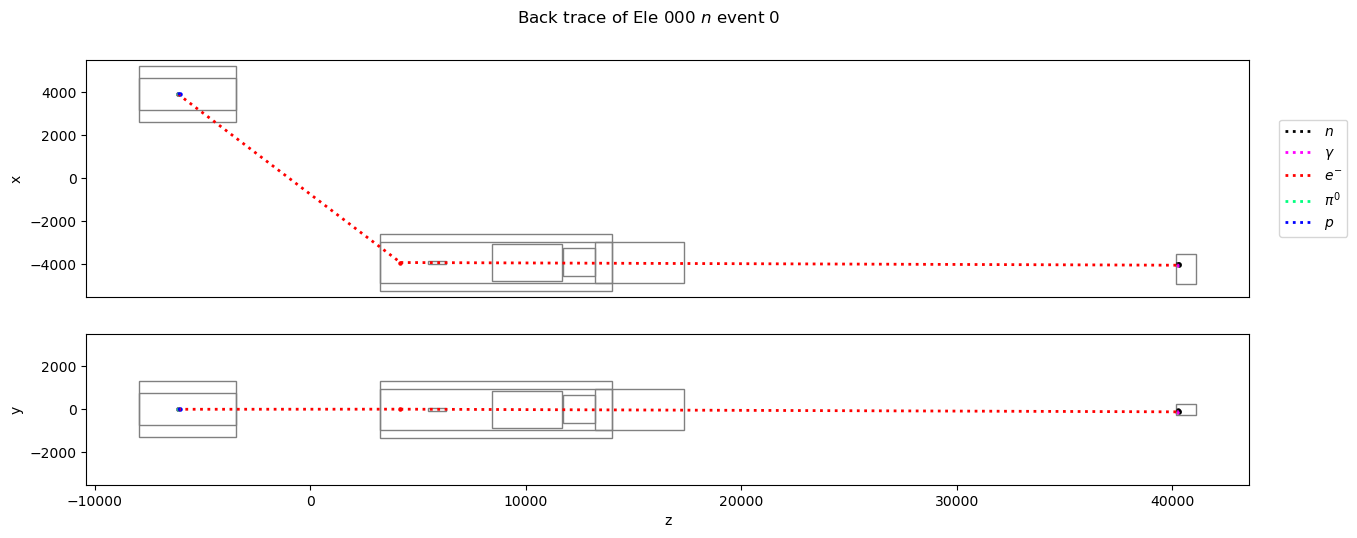

------------------------------------------------------------------------------


level_0                         5
tag                           Ele
fileno                          0
index                           5
time                   975.858081
virtualdetectorId             101
creationCode                  109
pdgId                        2112
x                    -3933.435122
y                       88.539649
z                         40185.4
startx               -3805.770823
starty                 -321.49308
startz               39961.185506
starttime              167.936081
E                        5.070383
weight                  41.157161
Name: 5, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,35,Ele,0,5,91.312065,166.936081,16,22,-3979.090722,74.948895,17293.804708,2.494214e+04
1,36,Ele,0,5,46.135223,140.963882,56,11,-3872.767200,-9.630755,4179.000000,3.657522e+04
2,37,Ele,0,5,-9.719785,46.201942,13,11,3929.658658,1.610823,-6059.503708,5.597386e+04
3,38,Ele,0,5,-9.720688,-9.719785,14,22,3929.651421,1.429869,-6059.704892,7.311284e+04
4,39,Ele,0,5,-9.720688,-9.720688,101,111,3929.651410,1.429865,-6059.704896,5.635398e+04
5,40,Ele,0,5,-9.727772,-9.720688,56,2212,3930.160972,1.431343,-6057.655164,8.000000e+06


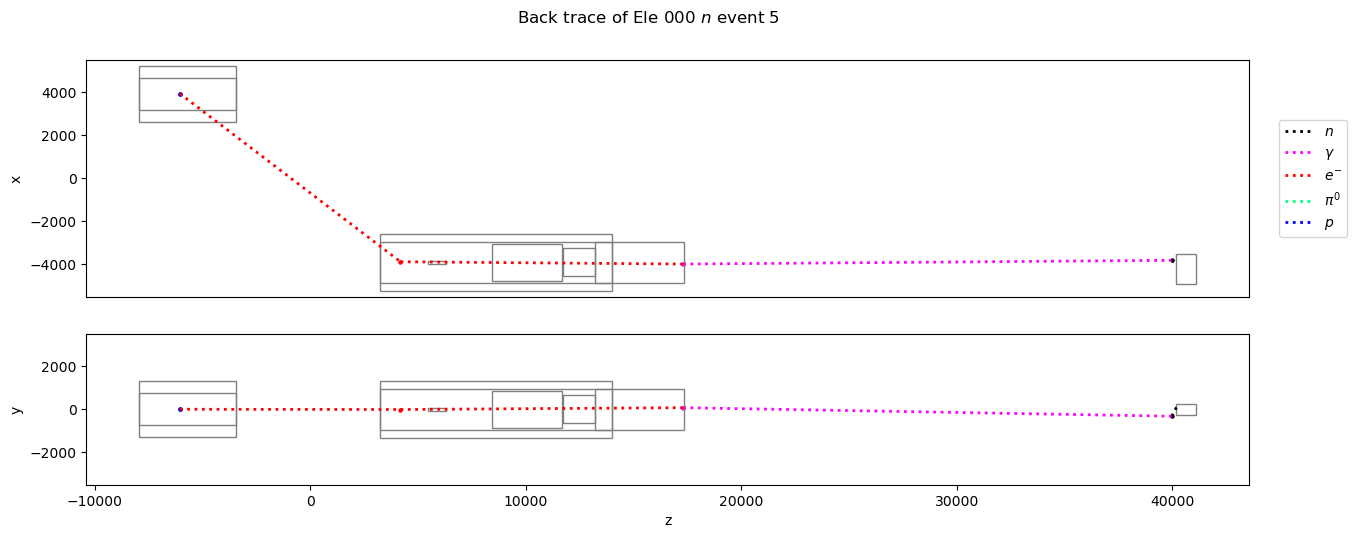

------------------------------------------------------------------------------


level_0                        10
tag                           Ele
fileno                          0
index                          10
time                    511.54206
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3940.303764
y                       -5.253014
z                         40185.4
startx               -3973.402936
starty                  20.353179
startz               40230.124688
starttime              401.799347
E                       22.324815
weight                  41.157161
Name: 10, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,71,Ele,0,10,367.153778,401.799347,97,2112,-3988.929000,-4.618115,40209.296015,1.485239e+02
1,72,Ele,0,10,226.497070,367.153778,109,2112,-4808.314086,3211.754783,39570.788199,3.466136e+03
2,73,Ele,0,10,153.825928,225.497070,16,22,-3968.376088,127.898958,18323.369964,1.968612e+04
3,74,Ele,0,10,103.161766,159.390900,56,11,-3941.013509,-25.149544,4179.000000,3.369763e+04
4,75,Ele,0,10,40.718571,103.228485,13,11,3901.412052,0.506618,-6173.839882,6.123049e+04
5,76,Ele,0,10,40.713261,40.718571,14,22,3901.498480,0.226521,-6175.404502,1.181110e+05
6,77,Ele,0,10,40.713261,40.713261,101,111,3901.498506,0.226526,-6175.404541,7.761448e+04
7,78,Ele,0,10,40.306736,40.713261,56,2212,3931.012507,-0.093015,-6057.867475,8.000000e+06


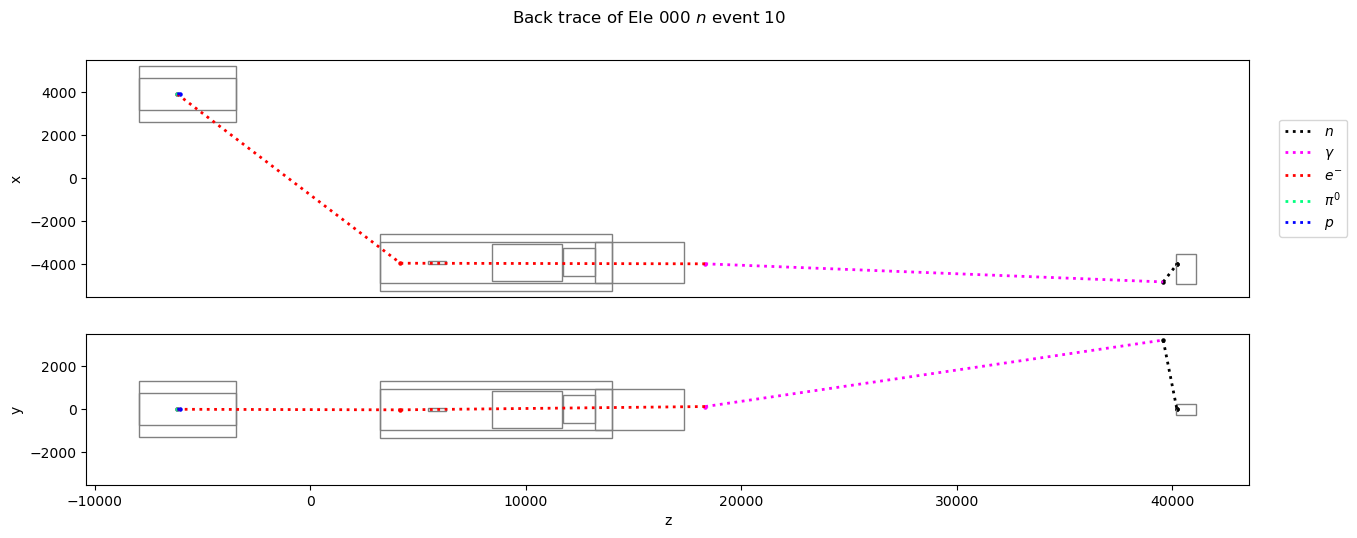

------------------------------------------------------------------------------


level_0                        15
tag                           Ele
fileno                          0
index                          15
time                   191.180941
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                     -3851.29907
y                       58.138266
z                         40185.4
startx                -3846.44348
starty                  62.483278
startz               40212.757598
starttime              188.645767
E                      643.878554
weight                  41.157161
Name: 15, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,111,Ele,0,15,187.935211,188.645767,97,2112,-3851.799598,53.243470,40208.202388,1.398841e+03
1,112,Ele,0,15,187.287125,187.935211,109,2112,-3860.769385,51.839922,40214.565365,1.533373e+03
2,113,Ele,0,15,109.855827,186.287125,16,22,-3836.590478,18.733612,17301.075782,2.324590e+04
3,114,Ele,0,15,65.530251,197.379059,56,11,-3899.479725,-24.307665,4179.000000,4.626680e+04
4,115,Ele,0,15,12.312900,65.596970,13,11,3909.027191,0.742329,-6144.458025,1.321964e+05
5,116,Ele,0,15,12.297665,12.312900,14,22,3908.610050,-0.817389,-6148.730511,1.362481e+05
6,117,Ele,0,15,12.297665,12.297665,101,111,3908.610026,-0.817393,-6148.730549,1.065337e+05
7,118,Ele,0,15,11.983743,12.297665,56,2212,3931.194642,-0.803373,-6057.912886,8.000000e+06


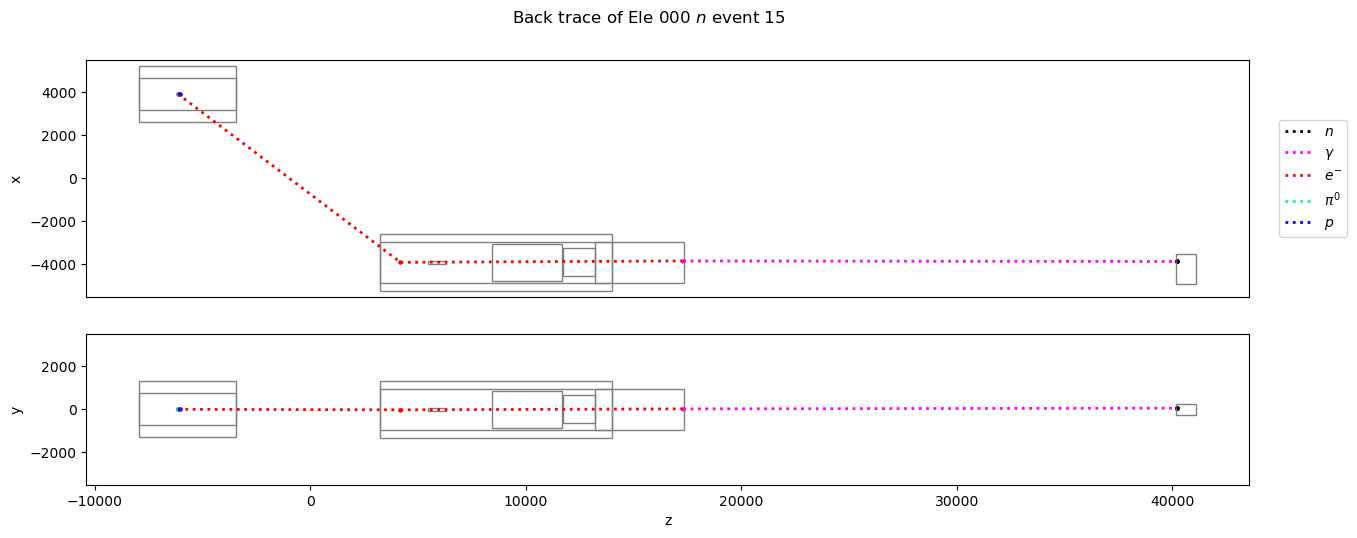

------------------------------------------------------------------------------


level_0                        20
tag                           Ele
fileno                          1
index                           1
time                   435.482128
virtualdetectorId             101
creationCode                  109
pdgId                        2112
x                    -3948.434381
y                      -39.583272
z                         40185.4
startx                -3889.62993
starty                  72.715555
startz               40231.840943
starttime              198.585724
E                       98.950099
weight                  41.157161
Name: 20, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,149,Ele,1,1,120.628624,197.585724,16,22,-4190.121057,-25.086039,17162.848484,1.799794e+04
1,150,Ele,1,1,76.150108,120.641060,56,11,-3923.866088,-6.755459,4179.000000,2.166026e+04
2,151,Ele,1,1,18.748560,76.216835,13,11,3884.580462,2.053431,-6239.766530,8.772832e+04
3,152,Ele,1,1,18.745863,18.748560,14,22,3885.287823,2.046681,-6240.159023,9.477715e+04
4,153,Ele,1,1,18.745863,18.745863,101,3212,3885.287823,2.046681,-6240.159023,1.503634e+05
5,154,Ele,1,1,18.115318,18.745863,56,2212,3930.941303,0.457593,-6057.849722,8.000000e+06


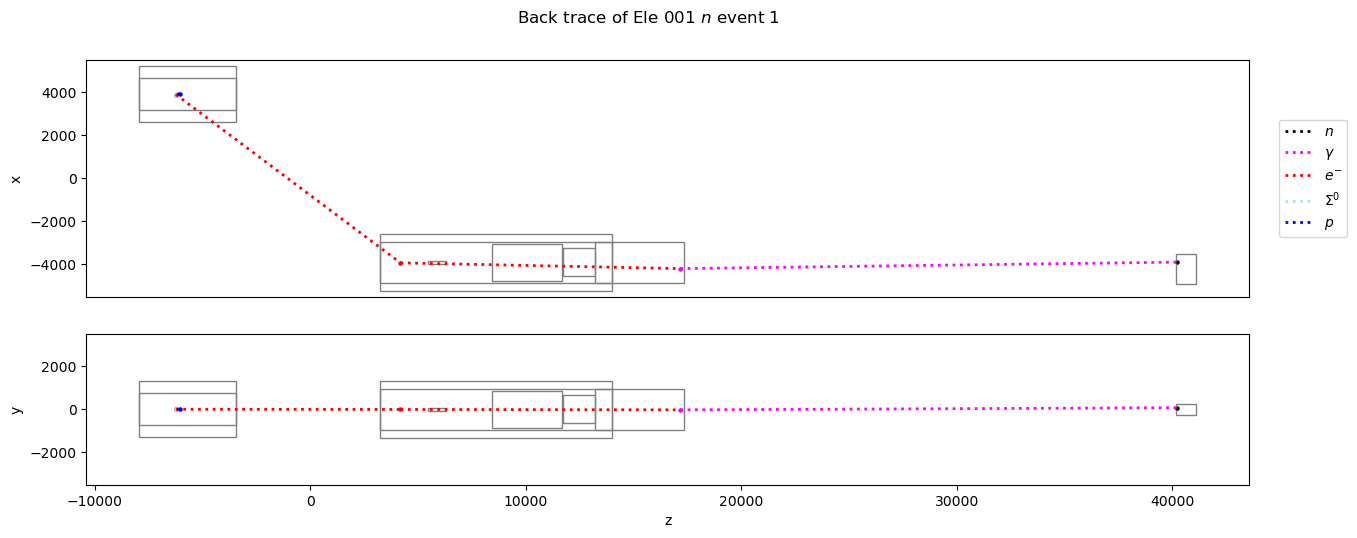

------------------------------------------------------------------------------


level_0                        25
tag                           Ele
fileno                          2
index                           0
time                   229.992096
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3942.437423
y                       -7.501755
z                         40185.4
startx               -3944.582508
starty                 -50.722997
startz               40207.082018
starttime              224.245773
E                      371.078102
weight                  41.157161
Name: 25, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,181,Ele,2,0,221.588257,224.245773,109,2112,-3922.825231,-43.917015,40207.088431,4.276883e+02
1,182,Ele,2,0,144.566376,220.588257,16,22,-3909.564693,-25.996331,17416.312828,1.248206e+04
2,183,Ele,2,0,99.540215,144.765076,56,11,-3884.664879,-13.540562,4179.000000,2.085922e+04
3,184,Ele,2,0,43.107826,99.606949,13,11,3917.477313,7.863512,-6053.808869,4.307781e+04
4,185,Ele,2,0,43.048004,43.107826,14,22,3928.535161,1.348645,-6066.335850,2.552938e+05
5,186,Ele,2,0,43.048000,43.048004,101,111,3928.535294,1.348528,-6066.335960,2.941230e+05
6,187,Ele,2,0,43.018433,43.048000,56,2212,3930.668389,1.342488,-6057.781677,8.000000e+06


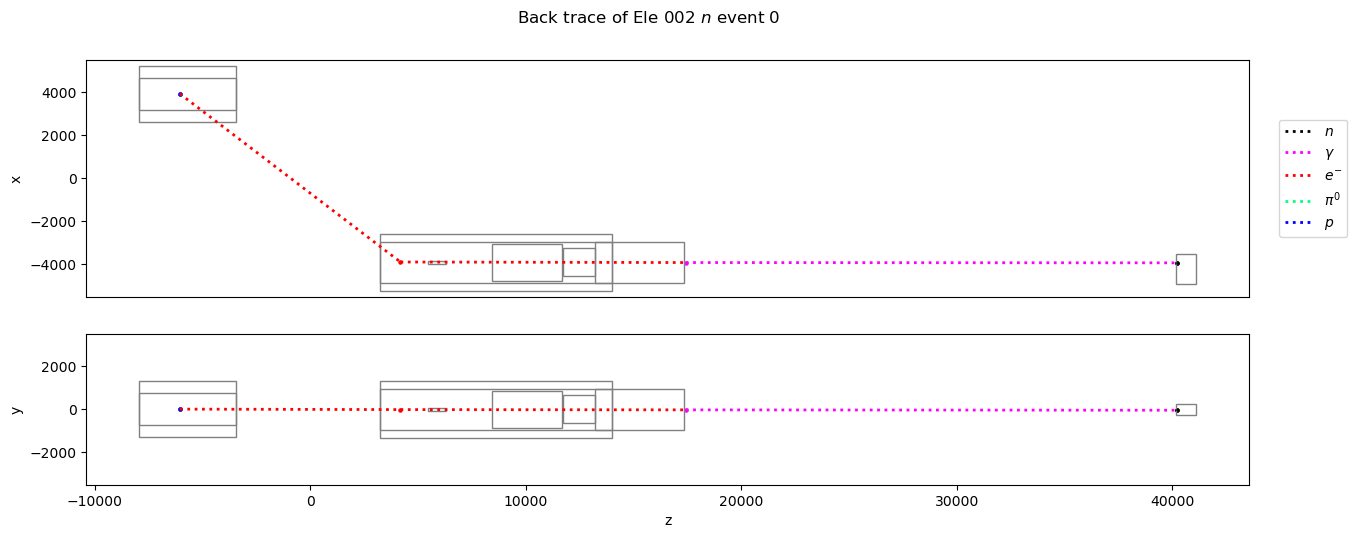

------------------------------------------------------------------------------


level_0                        30
tag                           Ele
fileno                          2
index                           5
time                   201.761125
virtualdetectorId             101
creationCode                  109
pdgId                        2112
x                    -3999.221877
y                      -24.809934
z                         40185.4
startx               -3999.229336
starty                  -27.77581
startz               40210.878796
starttime              199.066086
E                      473.867161
weight                  41.157161
Name: 30, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,214,Ele,2,5,198.052383,198.066086,16,22,-3999.408948,-29.228698,40207.040575,1.174212e+04
1,215,Ele,2,5,74.704636,198.055023,56,11,-3925.606117,-39.315537,4179.000000,3.246150e+04
2,216,Ele,2,5,10.716558,74.771362,12,11,3925.747716,1.011628,-6068.669128,6.871116e+04
3,217,Ele,2,5,10.709399,11.935908,14,22,3926.997891,0.272619,-6070.249687,6.951392e+04
4,218,Ele,2,5,10.709398,10.709399,101,111,3926.997877,0.272630,-6070.249768,1.221125e+05
5,219,Ele,2,5,10.665842,10.709398,56,2212,3930.141137,0.233696,-6057.650218,8.000000e+06


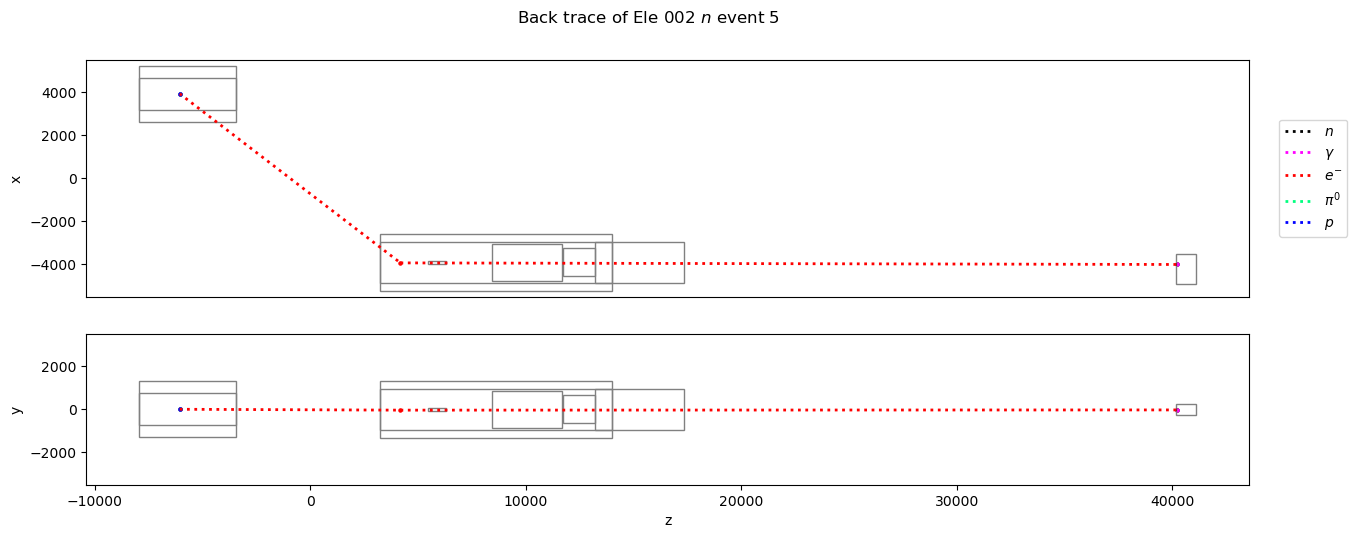

------------------------------------------------------------------------------


level_0                        35
tag                           Ele
fileno                          3
index                           1
time                   205.342554
virtualdetectorId             101
creationCode                  109
pdgId                        2112
x                    -3885.942075
y                      -29.852513
z                         40185.4
startx               -3941.832448
starty                  -68.56429
startz               40208.013178
starttime              200.329285
E                     1069.506223
weight                  41.157161
Name: 35, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,249,Ele,3,1,125.529327,199.329285,16,22,-3842.465151,-39.223107,18083.587048,1.450138e+04
1,250,Ele,3,1,77.959450,127.265045,56,11,-3917.748941,-6.080202,4179.000000,2.416083e+04
2,251,Ele,3,1,22.057957,78.026176,13,11,3909.964899,0.316198,-6137.288853,3.193059e+04
3,252,Ele,3,1,22.050962,22.057957,14,22,3910.557096,-0.241730,-6139.221216,4.119087e+04
4,253,Ele,3,1,22.050962,22.050962,101,111,3910.557113,-0.241760,-6139.221217,2.037609e+05
5,254,Ele,3,1,21.769575,22.050962,56,2212,3931.001174,-0.357427,-6057.864650,8.000000e+06


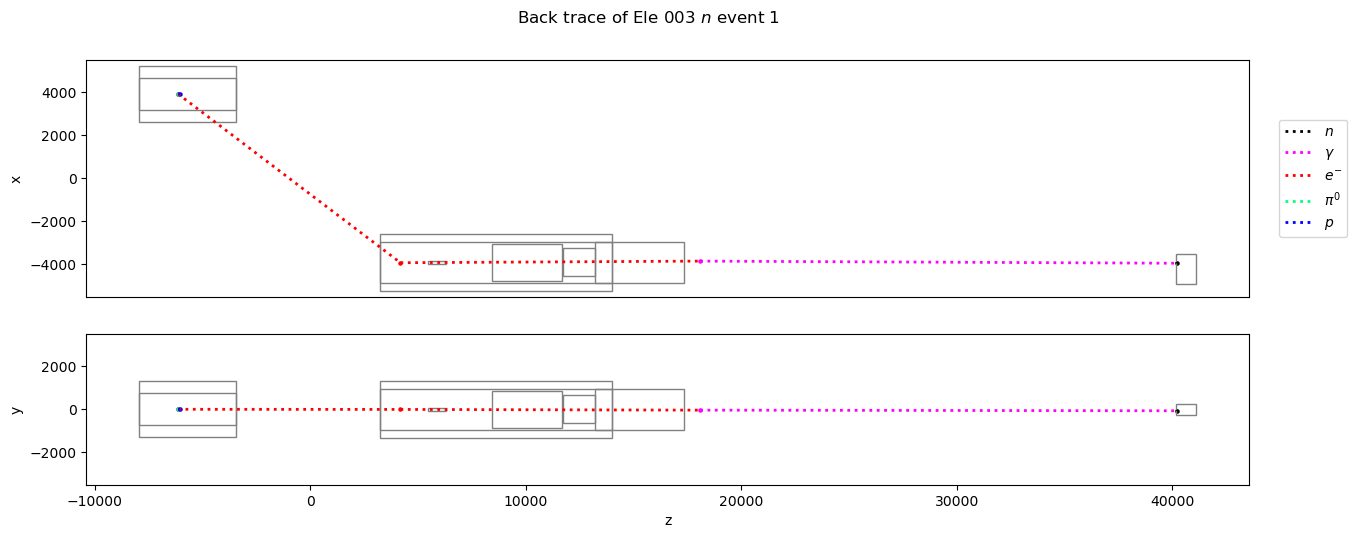

------------------------------------------------------------------------------


level_0                        40
tag                           Ele
fileno                          3
index                           6
time                   186.389281
virtualdetectorId             101
creationCode                  109
pdgId                        2112
x                    -3973.256227
y                       66.763375
z                         40185.4
startx               -4034.724012
starty                  65.104387
startz               40211.429641
starttime              179.104782
E                      439.497954
weight                  41.157161
Name: 40, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,289,Ele,3,6,101.672562,178.104782,16,22,-3959.160049,-14.139889,17297.890733,1.825914e+04
1,290,Ele,3,6,57.400738,137.735352,56,11,-3871.548524,-12.213936,4179.000000,4.097923e+04
2,291,Ele,3,6,3.179317,57.467457,13,11,3928.906399,-1.398847,-6058.948868,1.607941e+05
3,292,Ele,3,6,3.177001,3.179317,14,22,3928.249912,-1.173635,-6058.932595,2.010980e+05
4,293,Ele,3,6,3.177001,3.177001,101,111,3928.249907,-1.173633,-6058.932595,9.580187e+04
5,294,Ele,3,6,3.171293,3.177001,56,2212,3928.661062,-1.173966,-6057.281194,8.000000e+06


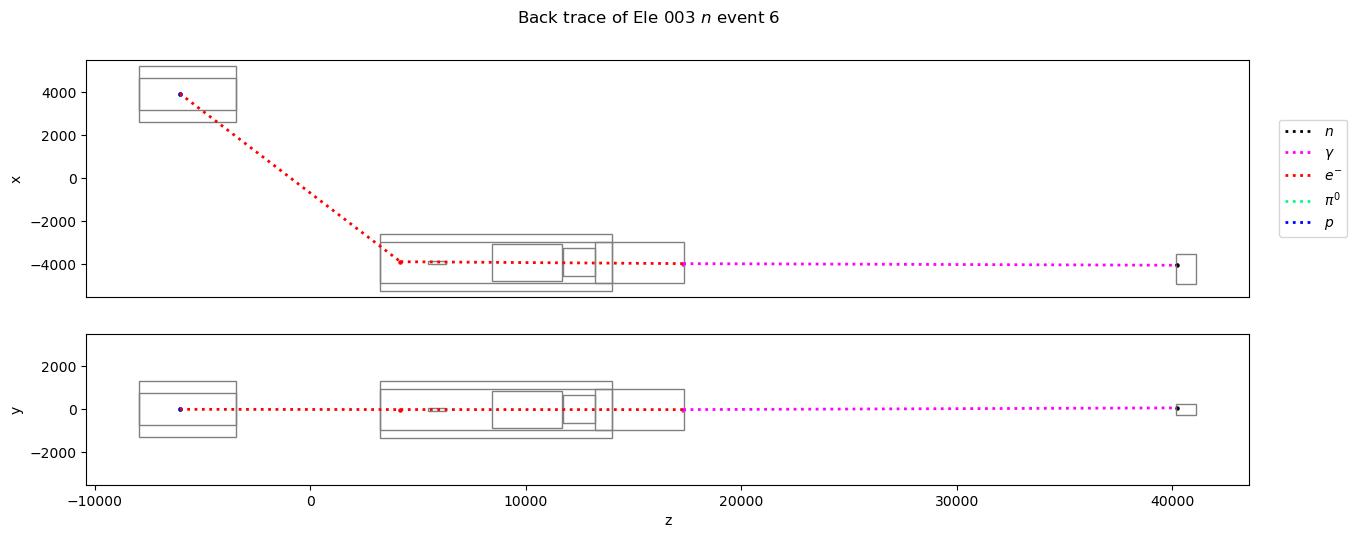

------------------------------------------------------------------------------


level_0                        45
tag                           Ele
fileno                          3
index                          11
time                   231.882764
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3987.860537
y                      -25.439755
z                         40185.4
startx               -3978.697983
starty                 -30.883767
startz               40216.956851
starttime              228.810867
E                       615.12788
weight                  41.157161
Name: 45, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,329,Ele,3,11,228.105362,228.810867,109,2112,-3987.248679,-30.228747,40217.915442,1.042517e+03
1,330,Ele,3,11,227.078125,227.105362,16,22,-3987.803249,-30.448230,40209.772667,1.328792e+04
2,331,Ele,3,11,106.658684,227.086441,56,11,-3898.630680,-33.358483,4179.000000,6.111170e+04
3,332,Ele,3,11,53.997978,106.725395,13,11,3912.185581,0.753436,-6131.328625,1.546340e+05
4,333,Ele,3,11,53.996639,53.997978,14,22,3912.264864,0.695513,-6131.717960,1.700403e+05
5,334,Ele,3,11,53.996639,53.996639,101,111,3912.264888,0.695546,-6131.718081,2.137166e+05
6,335,Ele,3,11,53.741055,53.996639,56,2212,3930.433492,0.891799,-6057.723111,8.000000e+06


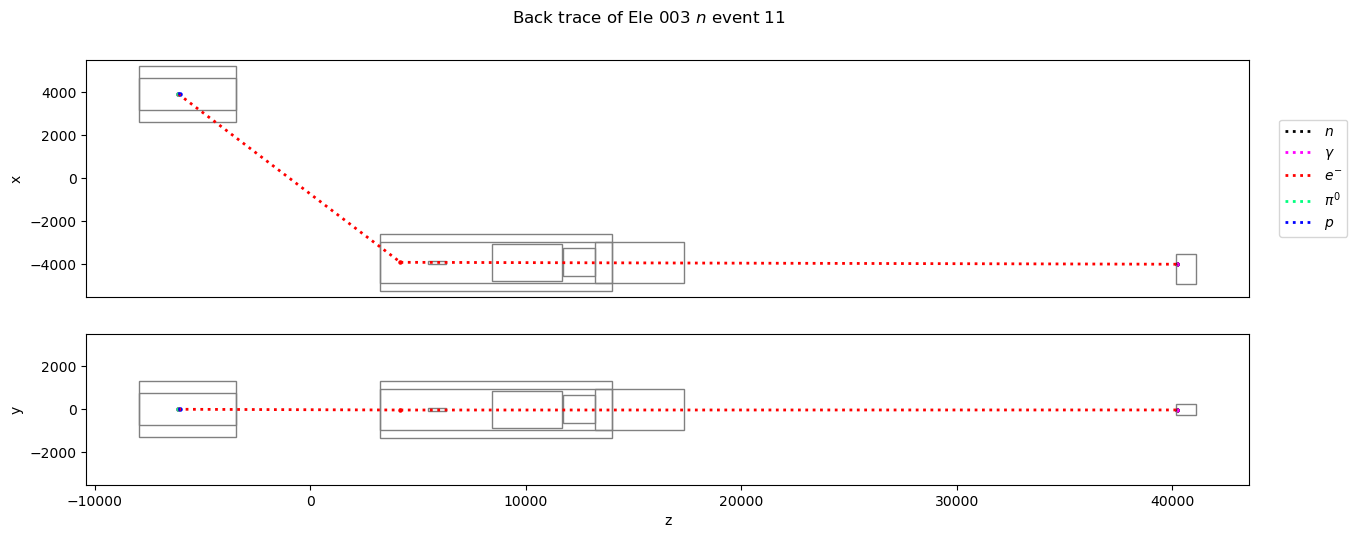

In [4]:
for ii in range(0, len(dfn_Ele), 5):
    print('------------------------------------------------------------------------------')
    dfn_ = dfn_Ele.iloc[ii]
    tag, fileno, index = dfn_['tag'], dfn_['fileno'], dfn_['index']
    dfg_ = df_genealogy.query("tag==@tag and fileno==@fileno and index==@index").reset_index()
    display(dfn_)
    display(dfg_)
    fig, ax_top, ax_side = plot_utils.draw_neutron_event_backtrace(df_neutron, df_genealogy, tag, fileno, index)
    plt.show()

source count
$\gamma$ :  47


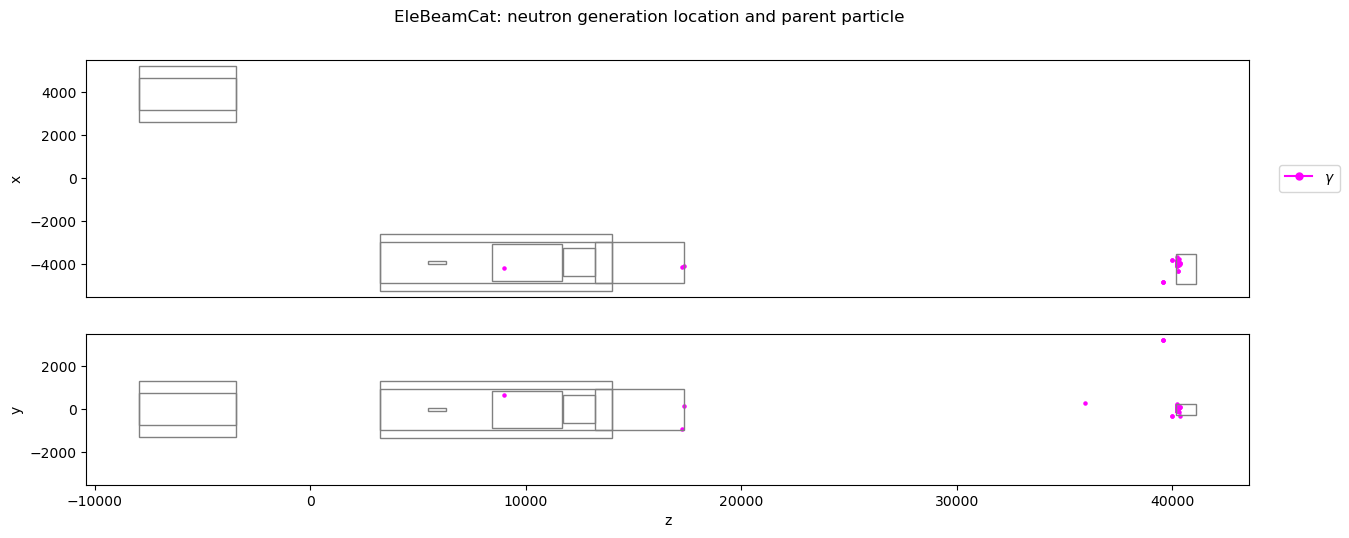

In [5]:
dfs_Ele, fig, ax_top, ax_side = plot_utils.draw_neutron_source_all(dfn_Ele, dfg_Ele, "EleBeamCat: neutron generation location and parent particle")

------------------------------------------------------------------------------


level_0                        47
tag                            Mu
fileno                          0
index                           0
time                  1870.280945
virtualdetectorId             101
creationCode                  115
pdgId                        2112
x                    -3849.721466
y                       75.269247
z                        40185.38
startx               -3989.331569
starty                 -85.512466
startz               17416.390759
starttime             1091.422363
E                     4715.633748
weight                   1.005488
Name: 0, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,342,Mu,0,0,119.849754,202.172806,56,13,-3905.455715,-23.860798,4179.000000,2.162125e+04
1,343,Mu,0,0,49.588024,119.969406,14,13,3841.661781,16.184827,-2296.798051,2.204238e+04
2,344,Mu,0,0,16.883116,49.588024,101,-211,3922.891934,-1.427538,-6082.553955,2.546531e+04
3,345,Mu,0,0,16.796181,16.883116,56,2212,3929.038263,-1.430937,-6057.375241,8.000000e+06


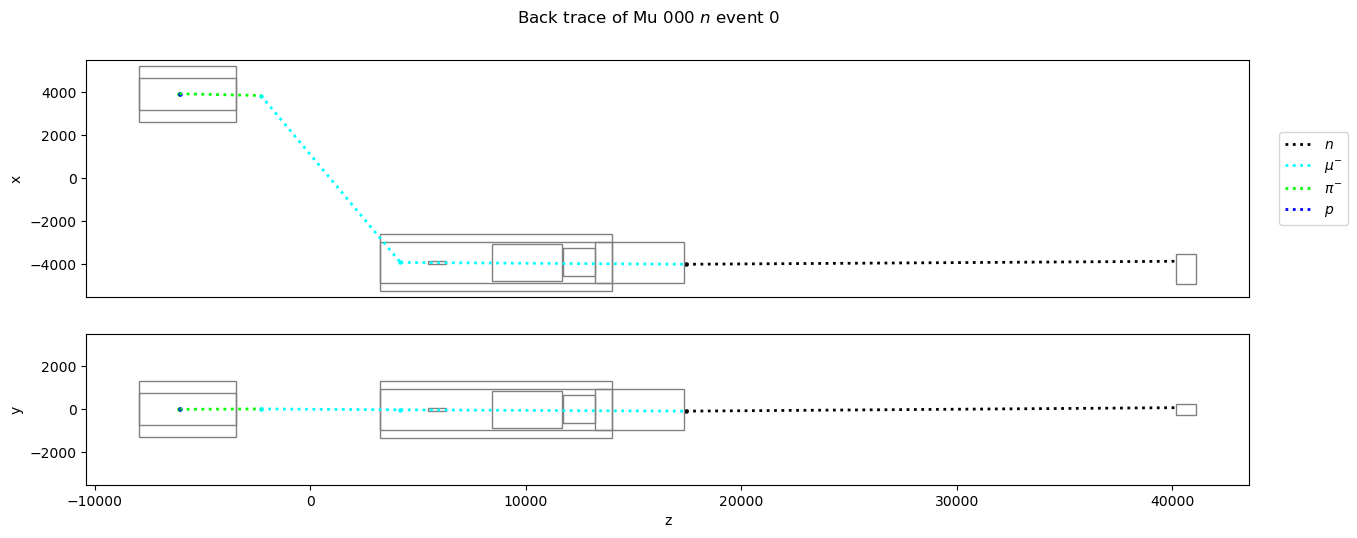

------------------------------------------------------------------------------


level_0                           87
tag                               Mu
fileno                             0
index                             40
time                 10630134.433684
virtualdetectorId                101
creationCode                      97
pdgId                           2112
x                       -3927.645887
y                          61.991002
z                            40185.4
startx                  -1945.453996
starty                   -2402.96908
startz                  16784.605574
starttime                 604.286133
E                           0.000013
weight                      1.005488
Name: 40, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,554,Mu,0,40,552.341919,604.286133,115,2112,-3942.556622,-345.286968,15399.518504,2.082085e+04
1,555,Mu,0,40,109.459801,191.312851,56,13,-3975.840580,-66.088828,4179.000000,1.794840e+04
2,556,Mu,0,40,-9.414787,109.588348,14,13,3923.759517,-5.980133,-5566.682363,1.877622e+04
3,557,Mu,0,40,-14.989573,-9.414787,101,-211,3921.181749,-0.621800,-6088.107992,3.766644e+04
4,558,Mu,0,40,-15.033758,-14.989573,101,2212,3925.862187,0.854385,-6077.713895,9.557621e+05
5,559,Mu,0,40,-15.102530,-15.033758,56,2212,3930.904363,0.824695,-6057.840512,8.000000e+06


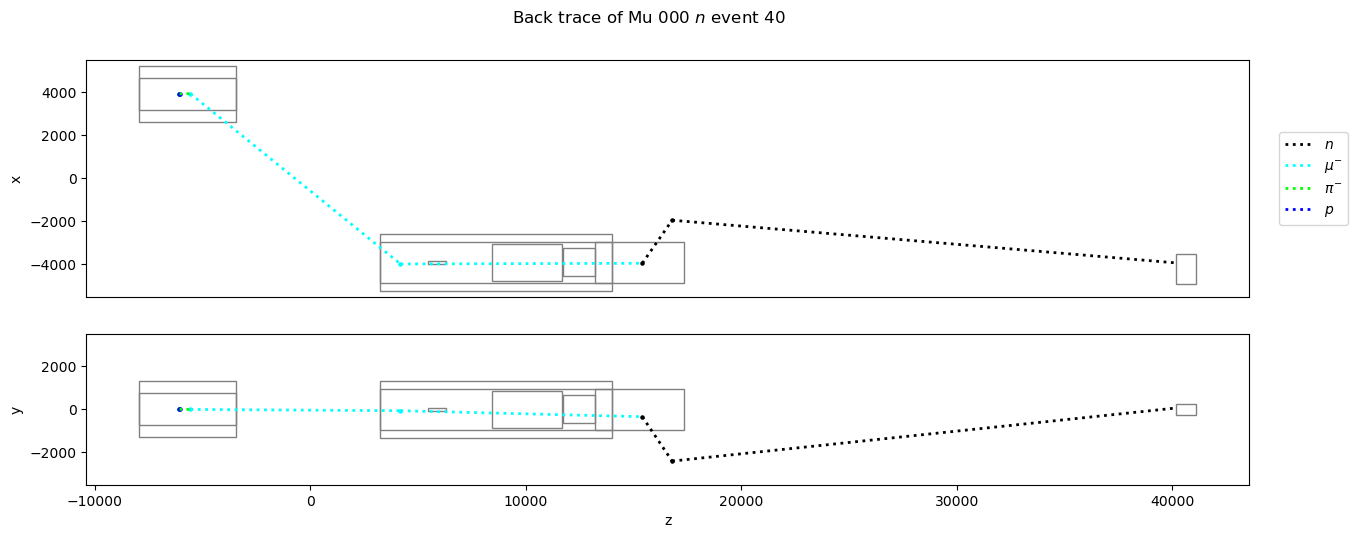

------------------------------------------------------------------------------


level_0                       127
tag                            Mu
fileno                          0
index                          80
time                  1330.264689
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3878.957052
y                         53.6088
z                         40185.4
startx               -3864.957609
starty                  72.136105
startz               40214.611173
starttime              1322.62793
E                      124.835148
weight                   1.005488
Name: 80, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,772,Mu,0,80,1316.462402,1322.627930,97,2112,-3856.072751,36.453296,40231.862314,2.269321e+02
1,773,Mu,0,80,1315.661377,1316.462402,97,2112,-3845.929133,28.613773,40230.686191,1.352972e+03
2,774,Mu,0,80,1315.376221,1315.661377,97,2112,-3842.223241,37.232753,40223.318886,9.962382e+03
3,775,Mu,0,80,1146.282837,1315.376221,97,2112,-86.678022,2992.149176,33433.442995,1.288701e+04
4,776,Mu,0,80,833.171326,1146.282837,115,2112,-3961.905598,-48.903990,17291.342132,1.582523e+04
5,777,Mu,0,80,241.344681,394.330231,56,13,-3898.396134,-110.222506,4179.000000,8.967138e+03
6,778,Mu,0,80,32.128735,241.516754,14,13,3858.433277,-52.786187,-5326.600646,1.107413e+04
7,779,Mu,0,80,17.334368,32.128735,97,-211,3928.285032,2.095780,-6070.231467,3.751477e+04
8,780,Mu,0,80,17.296127,17.334368,101,2112,3930.810209,-0.451801,-6060.852837,1.007547e+06
9,781,Mu,0,80,17.286247,17.296127,56,2212,3931.521554,-0.452366,-6057.994395,8.000000e+06


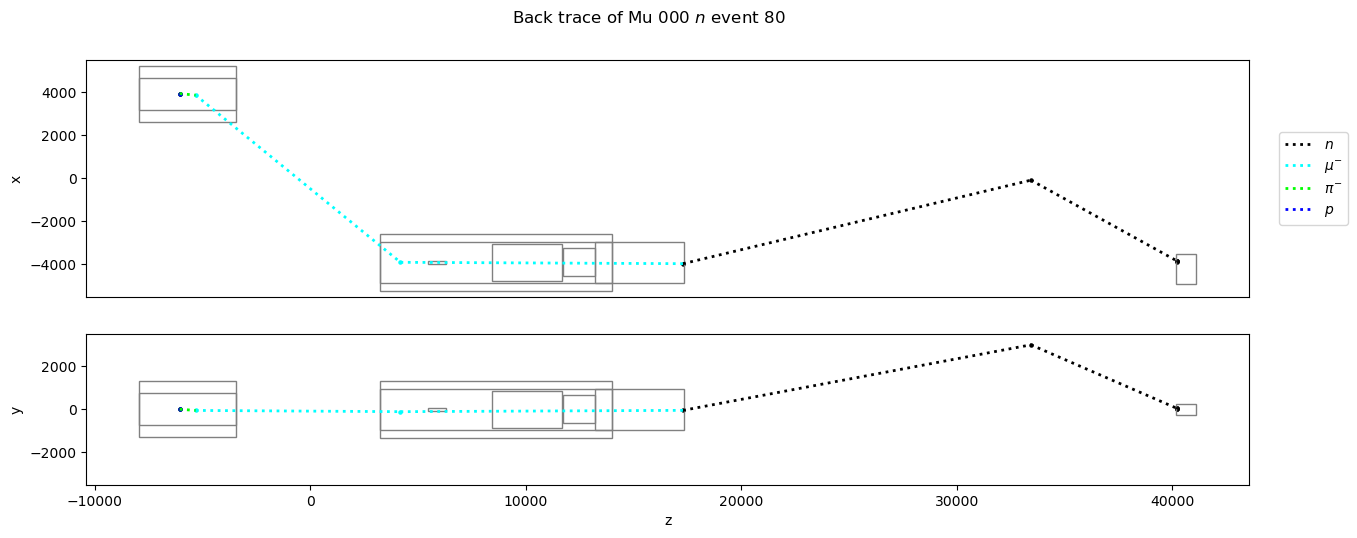

------------------------------------------------------------------------------


level_0                         167
tag                              Mu
fileno                            0
index                           120
time                 9867709.212487
virtualdetectorId               101
creationCode                     97
pdgId                          2112
x                      -3879.986516
y                         25.223961
z                          40185.38
startx                 -3929.271901
starty                   702.739989
startz                  7077.553481
starttime               1215.339844
E                           0.00002
weight                     1.005488
Name: 120, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,984,Mu,0,120,1158.660278,1215.339844,115,2112,-3944.182108,-36.642000,5626.514807,4.572987e+03
1,985,Mu,0,120,186.420181,211.088974,56,13,-3973.129037,-44.805904,4179.000000,2.802297e+03
2,986,Mu,0,120,4.565623,186.715576,14,13,3753.512396,-35.205640,-2187.429786,3.844115e+03
3,987,Mu,0,120,-47.496872,4.565623,101,-211,3906.023671,1.061953,-6158.363702,2.898114e+04
4,988,Mu,0,120,-47.844254,-47.496872,56,2212,3930.788276,1.477507,-6057.811568,8.000000e+06


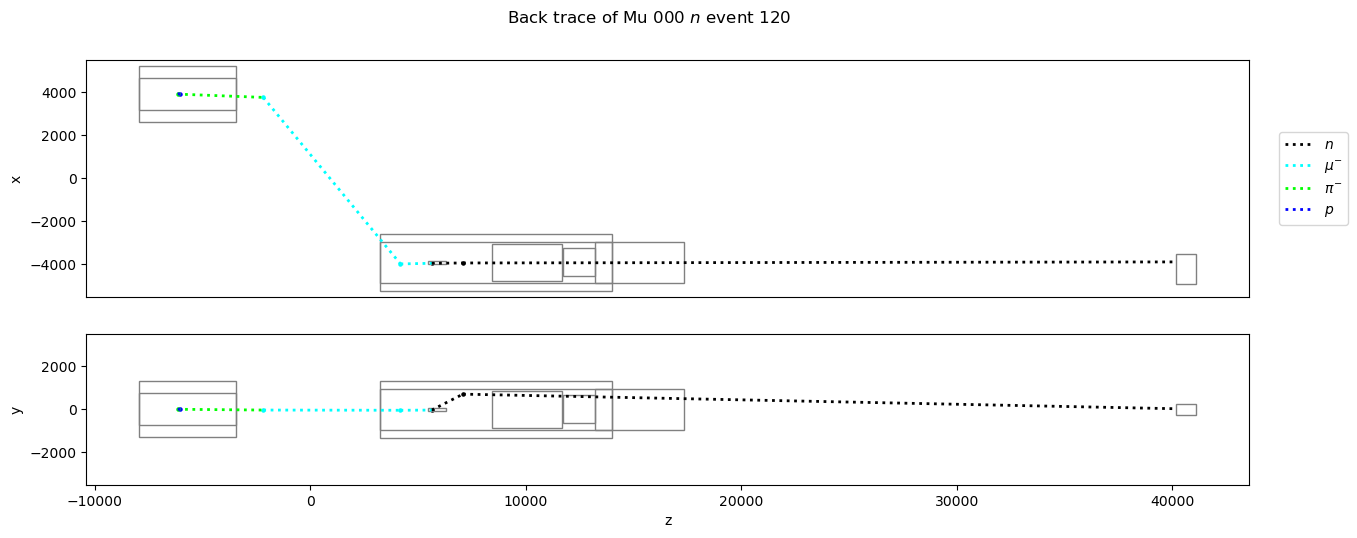

------------------------------------------------------------------------------


level_0                       207
tag                            Mu
fileno                          0
index                         160
time                 62395.688148
virtualdetectorId             101
creationCode                  115
pdgId                        2112
x                    -3947.545478
y                       47.976196
z                        40185.38
startx               -3912.848489
starty                  21.334942
startz                5604.337046
starttime             1310.634888
E                        1.524918
weight                   1.005488
Name: 160, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,1201,Mu,0,160,200.597931,222.596817,56,13,-3893.451661,18.806046,4179.000000,3.440180e+03
1,1202,Mu,0,160,-14.482480,200.865707,14,13,3900.924741,-16.386312,-5047.097960,5.743519e+03
2,1203,Mu,0,160,-25.860056,-14.482480,101,-211,3915.872058,-1.920771,-6113.924770,4.637360e+04
3,1204,Mu,0,160,-26.040203,-25.860056,101,2212,3928.187499,0.879508,-6061.733377,7.886762e+06
4,1205,Mu,0,160,-26.055079,-26.040203,56,2212,3929.262909,0.882807,-6057.431251,8.000000e+06


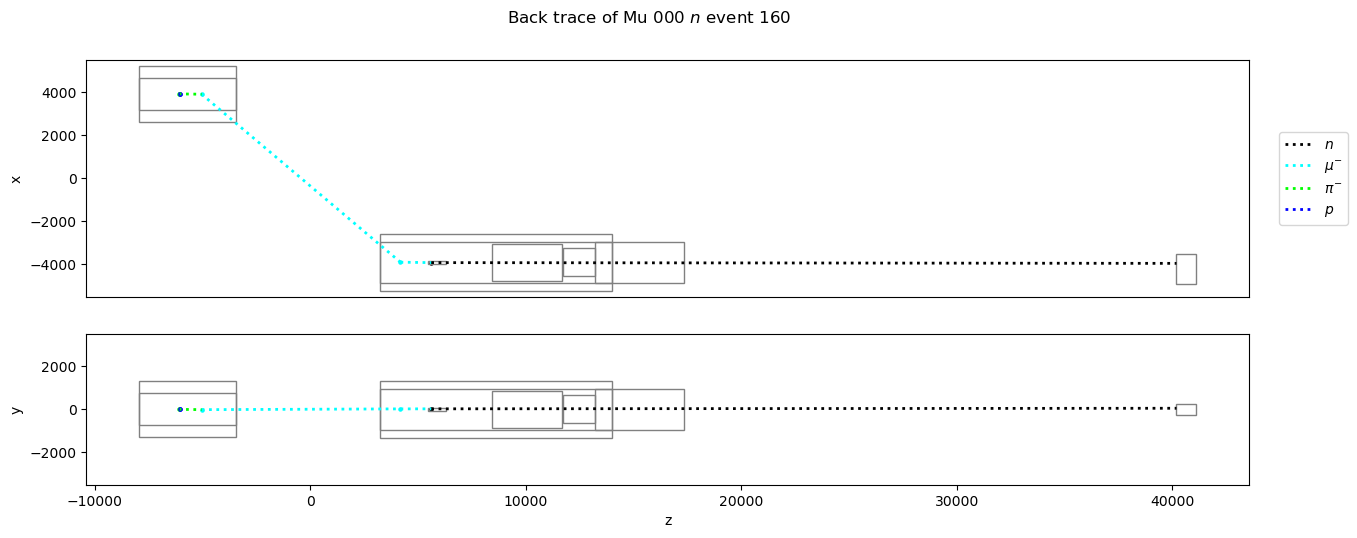

------------------------------------------------------------------------------


level_0                       247
tag                            Mu
fileno                          0
index                         200
time                 94078.566724
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3831.324878
y                        21.87285
z                        40185.38
startx               -3542.051012
starty                -610.695194
startz                 8779.76428
starttime             1253.956787
E                        0.552603
weight                   1.005488
Name: 200, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,1434,Mu,0,200,928.807190,1253.956787,97,2112,-3424.199380,-766.246964,7238.660661,2.013418e+03
1,1435,Mu,0,200,859.983887,928.807190,115,2112,-3934.320407,-29.498327,6093.244112,4.006897e+03
2,1436,Mu,0,200,213.853180,239.707687,56,13,-3968.352538,18.097252,4179.000000,9.089833e+03
3,1437,Mu,0,200,-2.283774,214.024200,14,13,3916.339133,-15.836159,-5910.716518,1.097350e+04
4,1438,Mu,0,200,-20.431227,-2.283774,14,-211,3870.692154,-46.917624,-6155.215229,1.935345e+04
5,1439,Mu,0,200,-20.958532,-20.431227,101,3122,3913.277414,-0.098278,-6121.216916,1.368184e+05
6,1440,Mu,0,200,-21.179121,-20.958532,56,2212,3929.506562,-0.168243,-6057.492001,8.000000e+06


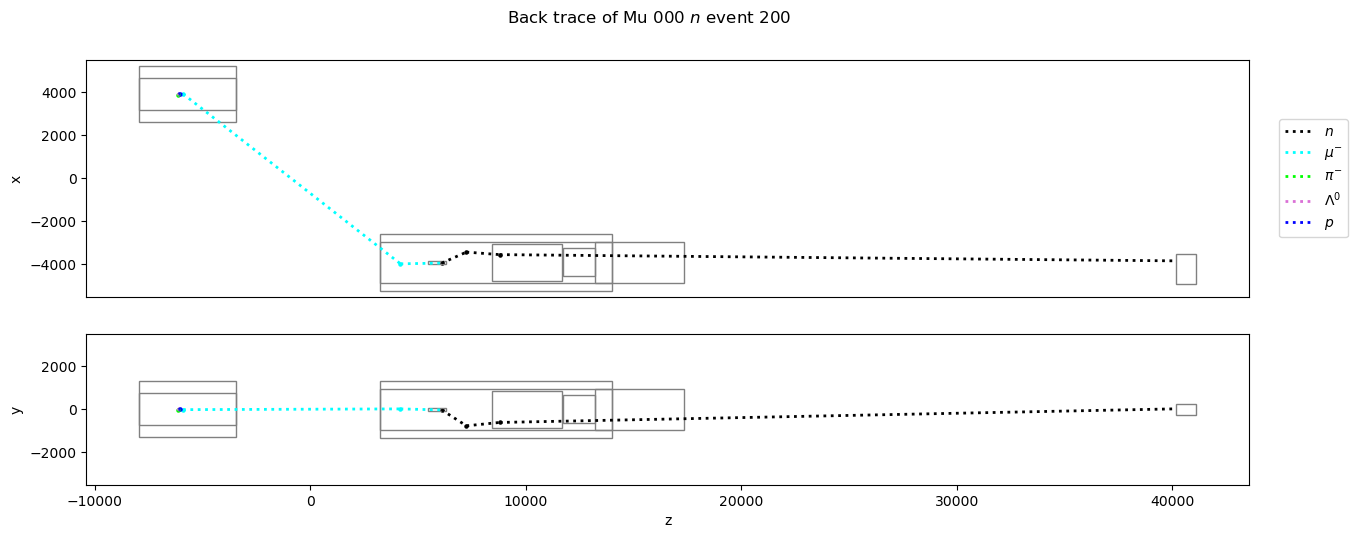

------------------------------------------------------------------------------


level_0                       287
tag                            Mu
fileno                          0
index                         240
time                   9647.98189
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3942.195122
y                      -66.500664
z                        40185.38
startx               -3616.878712
starty               -1286.419733
startz               17326.717036
starttime             4895.368652
E                      114.717947
weight                   1.005488
Name: 240, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,1655,Mu,0,240,4520.703613,4895.368652,115,2112,-4246.536544,-73.255918,16138.847826,2.170101e+03
1,1656,Mu,0,240,110.217682,181.921524,56,13,-3933.985623,-64.271906,4179.000000,2.229199e+04
2,1657,Mu,0,240,49.578426,110.335968,14,13,2932.562358,45.748104,-801.395627,2.271281e+04
3,1658,Mu,0,240,7.766810,49.578426,101,-211,3886.527809,2.262905,-6229.992494,2.606567e+04
4,1659,Mu,0,240,7.170381,7.766810,56,2212,3930.378104,0.737020,-6057.709301,8.000000e+06


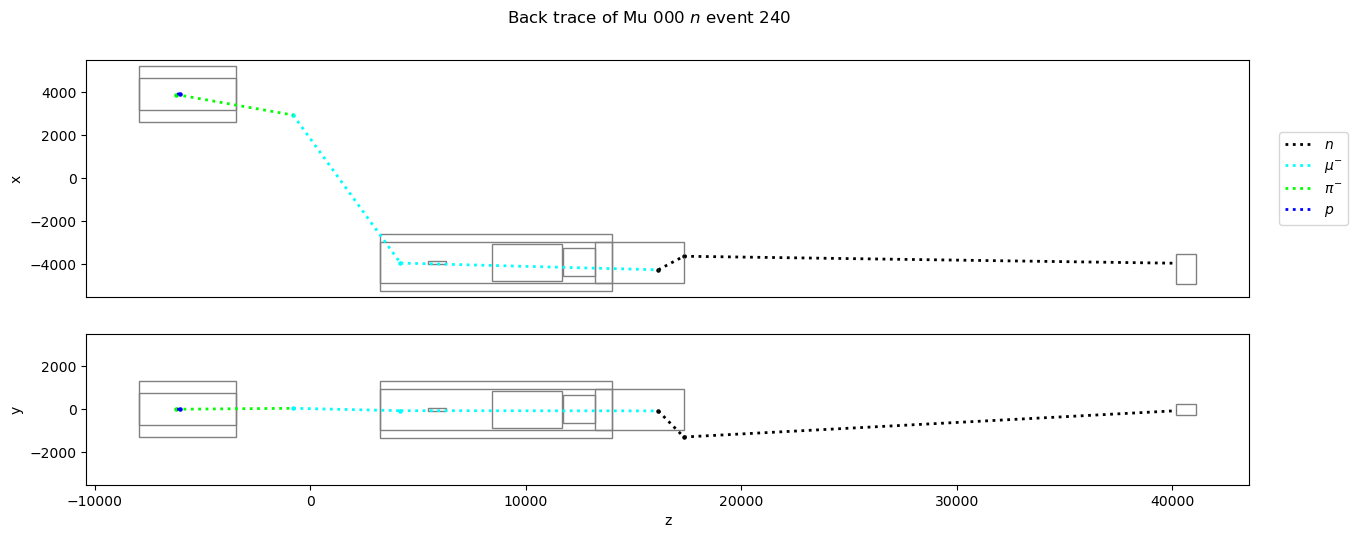

------------------------------------------------------------------------------


level_0                        327
tag                             Mu
fileno                           0
index                          280
time                 747753.492023
virtualdetectorId              101
creationCode                   115
pdgId                         2112
x                     -4001.579962
y                        -9.383316
z                         40185.38
startx                -3847.636316
starty                  -35.924912
startz                   5626.5401
starttime               1579.92395
E                         0.011271
weight                    1.005488
Name: 280, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,1865,Mu,0,280,223.096069,243.286942,56,13,-3836.206248,8.231190,4179.000000,4.273502e+03
1,1866,Mu,0,280,0.435128,223.337692,14,13,3962.956459,3.471277,-5925.451560,6.440265e+03
2,1867,Mu,0,280,-7.703712,0.435128,101,-211,3930.714395,0.360729,-6058.967572,1.964846e+04
3,1868,Mu,0,280,-7.707534,-7.703712,56,2212,3930.989675,0.360559,-6057.861782,8.000000e+06


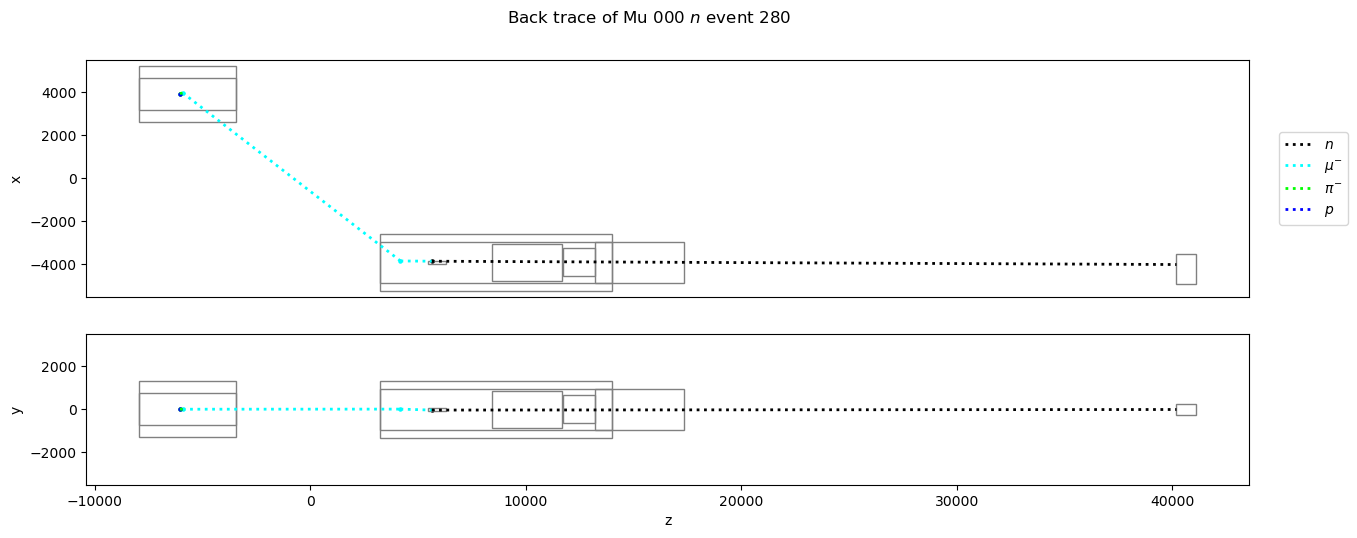

------------------------------------------------------------------------------


level_0                       367
tag                            Mu
fileno                          0
index                         320
time                   5498.60125
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3956.505629
y                      -61.986062
z                        40185.38
startx               -3929.939105
starty                   559.4147
startz               17189.400201
starttime              718.793762
E                      121.414373
weight                   1.005488
Name: 320, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,2082,Mu,0,320,503.618622,718.793762,97,2112,-3570.674995,302.372318,16751.295222,1.403685e+03
1,2083,Mu,0,320,495.900787,503.618622,115,2112,-4047.533290,285.391841,16993.897575,2.655798e+04
2,2084,Mu,0,320,73.146408,237.448257,56,13,-3932.677460,27.536119,4179.000000,1.167537e+04
3,2085,Mu,0,320,-44.949600,73.299820,14,13,3897.735081,36.513101,-5743.978475,1.261575e+04
4,2086,Mu,0,320,-51.188599,-44.949600,100,-211,3906.105097,-4.795766,-6168.710103,1.118087e+04
5,2087,Mu,0,320,-51.260048,-51.188599,101,-211,3907.233413,-0.481377,-6147.889448,1.160366e+06
6,2088,Mu,0,320,-51.572365,-51.260048,56,2212,3930.414764,-0.873185,-6057.718441,8.000000e+06


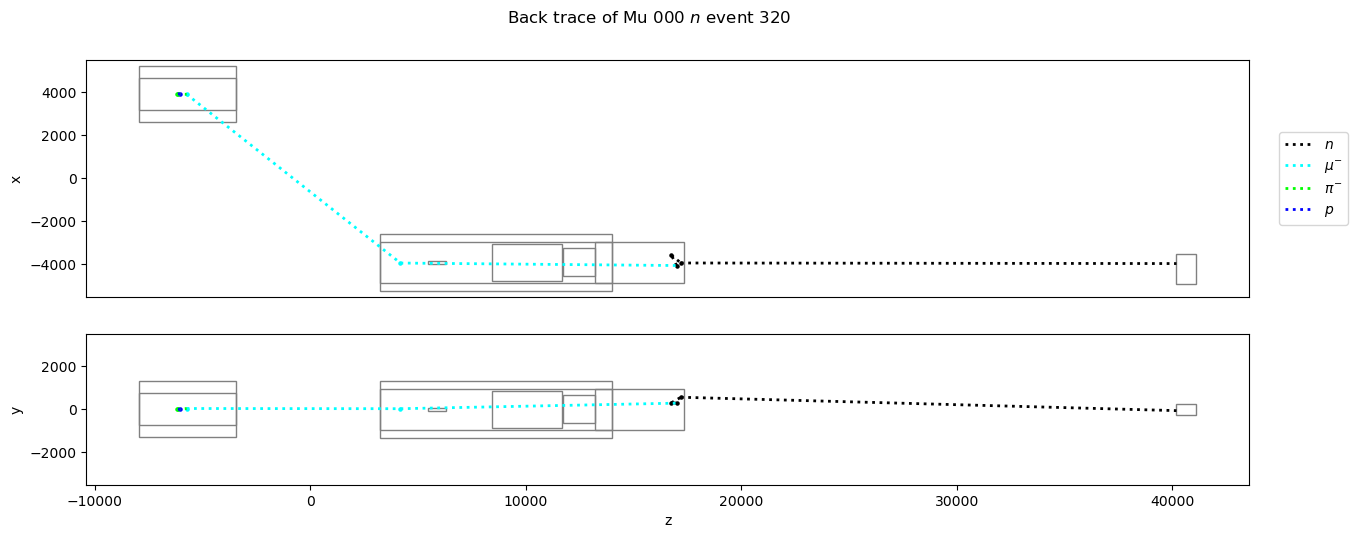

------------------------------------------------------------------------------


level_0                       407
tag                            Mu
fileno                          0
index                         360
time                  4090.949534
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                     -3896.33794
y                      -44.254727
z                        40185.38
startx               -4156.300695
starty                -140.118288
startz               17330.641989
starttime             2485.599609
E                     1109.265128
weight                   1.005488
Name: 360, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,2307,Mu,0,360,2478.267334,2485.599609,115,2112,-4215.234831,-14.605650,17167.343446,5.656820e+03
1,2308,Mu,0,360,160.817245,258.309631,56,13,-3916.417876,-9.369697,4179.000000,1.533601e+04
2,2309,Mu,0,360,91.715866,160.954163,14,13,2500.052497,100.849637,-449.559042,1.589142e+04
3,2310,Mu,0,360,29.508701,91.715866,101,-211,3909.270756,0.430860,-6145.214745,3.246531e+04
4,2311,Mu,0,360,29.206758,29.508701,56,2212,3930.922227,0.169833,-6057.844966,8.000000e+06


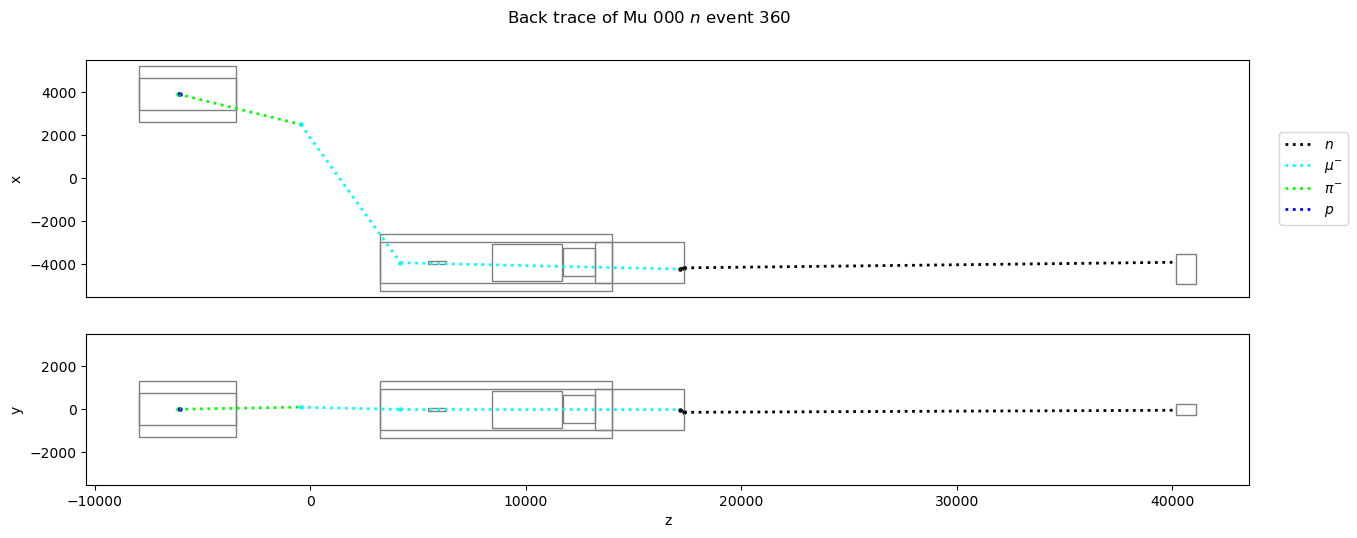

------------------------------------------------------------------------------


level_0                         447
tag                              Mu
fileno                            0
index                           400
time                 9112396.318122
virtualdetectorId               101
creationCode                     97
pdgId                          2112
x                      -3985.982227
y                        -34.229826
z                          40185.38
startx                 -4041.506114
starty                  1059.975793
startz                  6696.815496
starttime                768.196655
E                          0.000103
weight                     1.005488
Name: 400, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,2524,Mu,0,400,656.318970,768.196655,97,2112,-2846.811639,-71.023678,6599.835264,1.136223e+03
1,2525,Mu,0,400,625.464661,656.318970,115,2112,-3929.586075,30.472278,6204.293066,7.440298e+03
2,2526,Mu,0,400,146.572037,168.713394,56,13,-3891.161958,-25.960919,4179.000000,1.035795e+04
3,2527,Mu,0,400,-7.994825,146.733551,14,13,3915.177287,-75.308584,-6122.363681,2.704955e+04
4,2528,Mu,0,400,-9.212280,-7.994825,101,-211,3893.753960,1.763747,-6210.272551,3.529411e+04
5,2529,Mu,0,400,-9.738641,-9.212280,56,2212,3930.559351,0.230354,-6057.754491,8.000000e+06


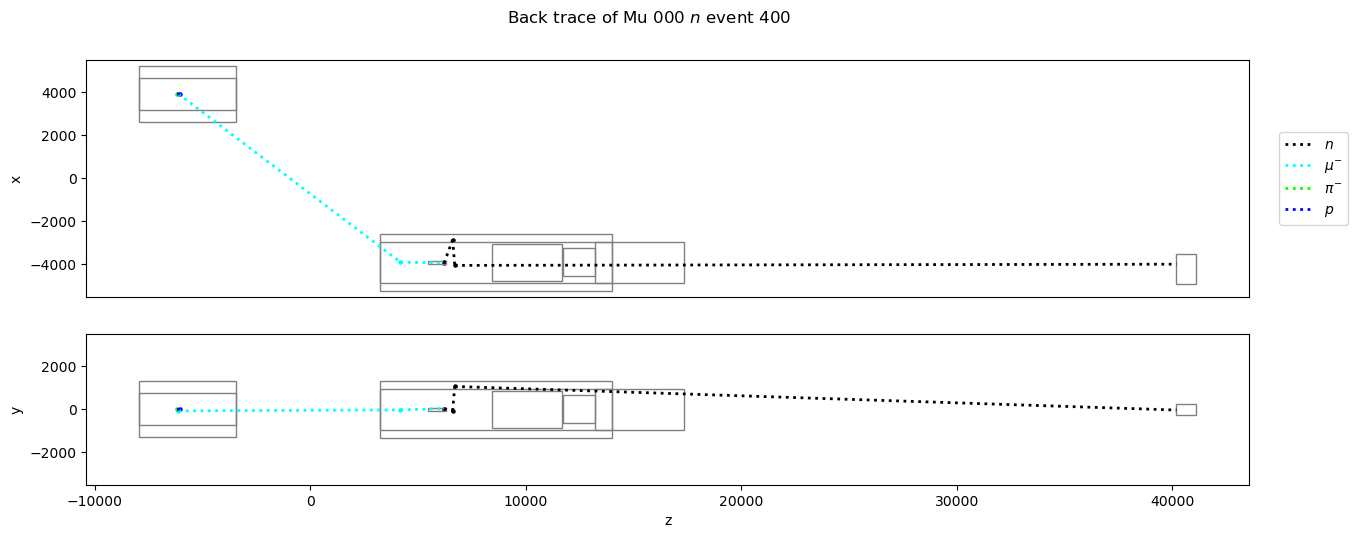

------------------------------------------------------------------------------


level_0                          487
tag                               Mu
fileno                             0
index                            440
time                 15224532.116482
virtualdetectorId                101
creationCode                     115
pdgId                           2112
x                       -3852.801174
y                         -51.686641
z                           40185.38
startx                  -3565.380065
starty                    -74.974199
startz                  16315.384155
starttime                2269.439209
E                            0.00009
weight                      1.005488
Name: 440, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,2735,Mu,0,440,147.099243,234.912216,56,13,-3849.089965,-94.921213,4179.000000,1.731674e+04
1,2736,Mu,0,440,33.780262,147.229630,14,13,3914.031731,-57.459850,-4829.522765,1.812467e+04
2,2737,Mu,0,440,3.775501,33.780262,14,-211,3883.378911,11.293182,-6223.694840,1.902826e+04
3,2738,Mu,0,440,3.373150,3.775501,14,3122,3896.099234,-0.781850,-6185.959663,7.297123e+04
4,2739,Mu,0,440,3.373150,3.373150,101,3212,3896.099234,-0.781850,-6185.959663,8.813987e+04
5,2740,Mu,0,440,2.927864,3.373150,56,2212,3929.230600,-1.320042,-6057.423196,8.000000e+06


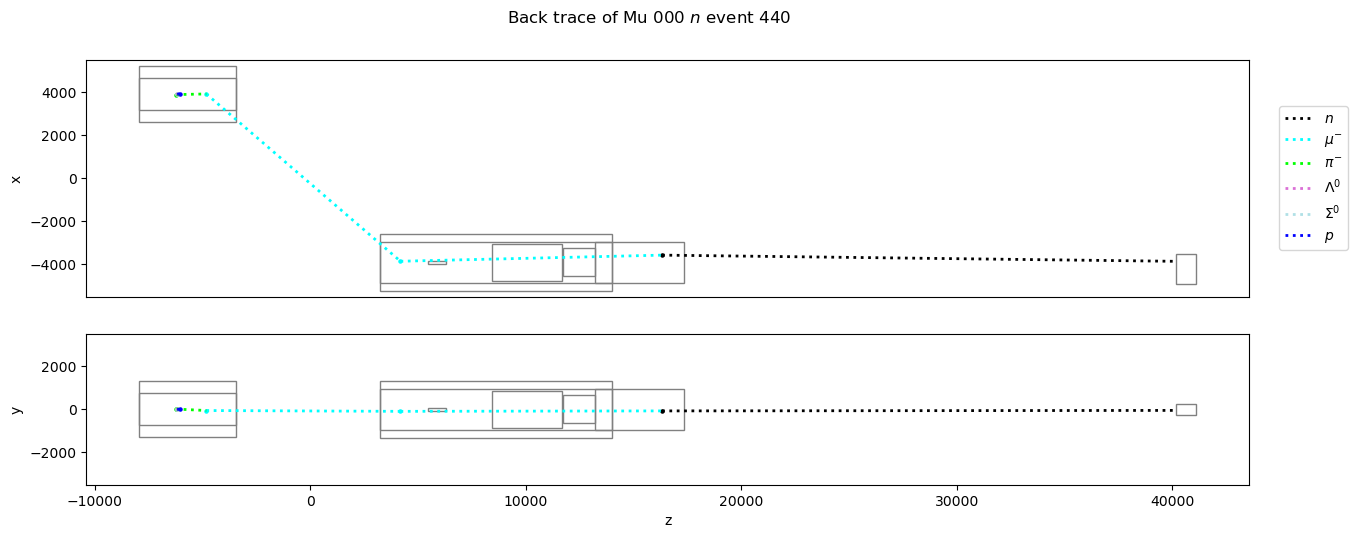

------------------------------------------------------------------------------


level_0                      527
tag                           Mu
fileno                         0
index                        480
time                 7684.726068
virtualdetectorId            101
creationCode                 115
pdgId                       2112
x                   -3959.398861
y                      36.153037
z                       40185.38
startx              -3880.781715
starty                -59.803207
startz               5982.085812
starttime             659.361816
E                     120.532751
weight                  1.005488
Name: 480, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,2957,Mu,0,480,208.240784,228.045395,56,13,-3897.533143,-46.327612,4179.000000,7.013693e+03
1,2958,Mu,0,480,61.582462,208.432861,14,13,3914.069285,-48.073198,-5143.909506,8.155668e+03
2,2959,Mu,0,480,29.723581,61.582462,97,-211,3907.668035,3.012933,-6146.161358,4.527142e+04
3,2960,Mu,0,480,29.702467,29.723581,99,2112,3909.673482,2.382281,-6140.573553,1.887175e+06
4,2961,Mu,0,480,29.693426,29.702467,101,211,3910.651776,2.215372,-6138.054624,2.825283e+06
5,2962,Mu,0,480,29.415882,29.693426,56,2212,3930.717942,1.276722,-6057.794032,8.000000e+06


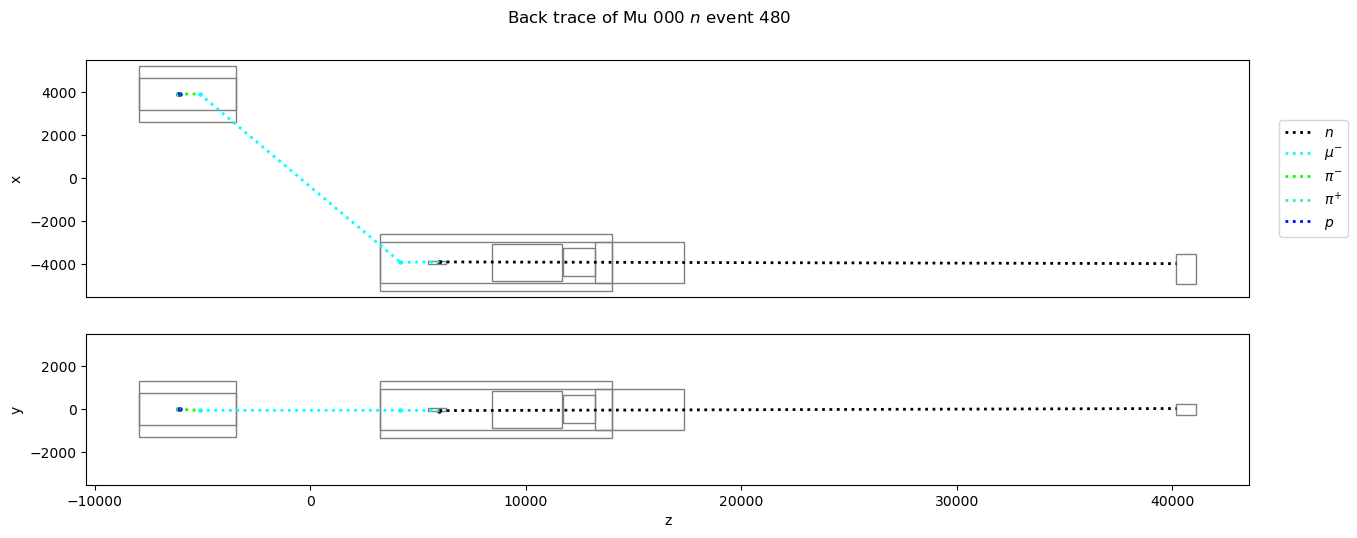

------------------------------------------------------------------------------


level_0                          567
tag                               Mu
fileno                             0
index                            520
time                 11651474.439541
virtualdetectorId                101
creationCode                     115
pdgId                           2112
x                       -3849.097903
y                          56.577654
z                           40185.38
startx                  -4066.992006
starty                    304.323751
startz                  15935.104627
starttime                  322.44696
E                           0.000053
weight                      1.005488
Name: 520, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,3182,Mu,0,520,129.522095,251.918076,56,13,-3957.056824,49.906506,4179.000000,1.022688e+04
1,3183,Mu,0,520,31.416609,129.684509,14,13,3858.445321,46.045588,-2787.409907,1.117706e+04
2,3184,Mu,0,520,0.064461,31.416609,101,-211,3889.350147,0.244189,-6236.212379,3.130791e+04
3,3185,Mu,0,520,-0.549911,0.064461,56,2212,3932.604066,0.253520,-6058.264296,8.000000e+06


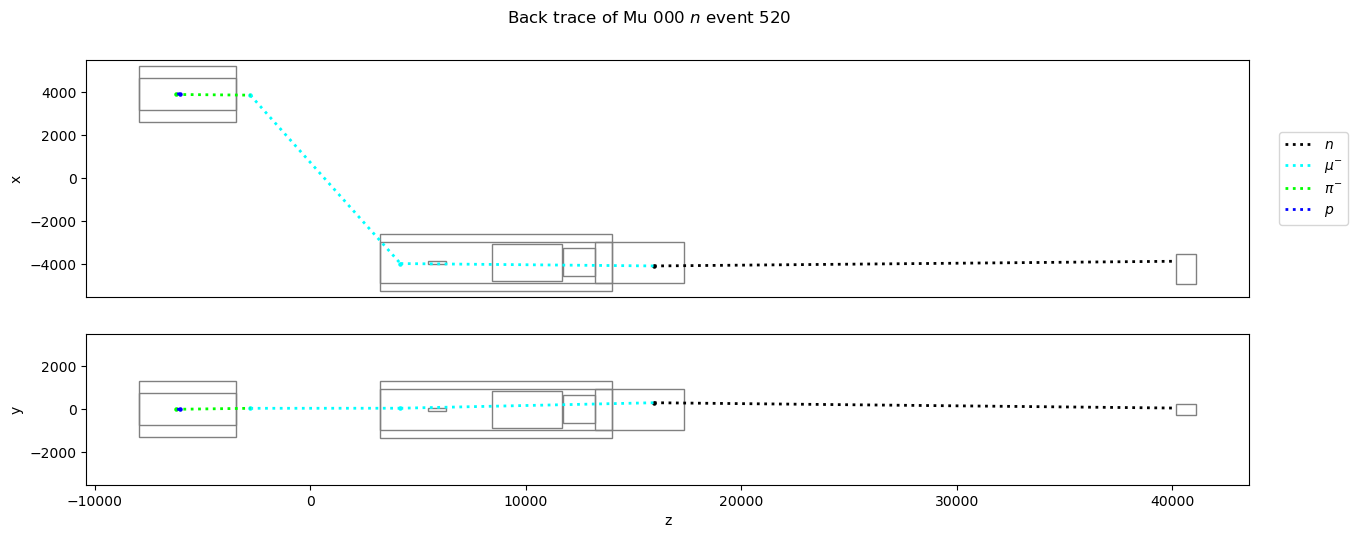

------------------------------------------------------------------------------


level_0                          607
tag                               Mu
fileno                             0
index                            560
time                 20621763.796175
virtualdetectorId                101
creationCode                      97
pdgId                           2112
x                       -3884.697701
y                          -7.370237
z                           40185.38
startx                  -4997.263123
starty                   -1566.76985
startz                  15087.700052
starttime                  5297.8125
E                            0.00002
weight                      1.005488
Name: 560, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,3400,Mu,0,560,5203.401855,5297.812500,115,2112,-4242.212303,-76.932430,15111.085473,3.827275e+03
1,3401,Mu,0,560,43.191525,127.490623,56,13,-3969.657263,-26.578166,4179.000000,1.534916e+04
2,3402,Mu,0,560,-51.330769,43.328388,14,13,3856.271920,-27.516240,-3973.368721,1.598136e+04
3,3403,Mu,0,560,-70.679649,-51.330769,101,-211,3893.636426,0.717148,-6199.030263,3.026863e+04
4,3404,Mu,0,560,-71.169510,-70.679649,56,2212,3930.463130,-0.280155,-6057.730500,8.000000e+06


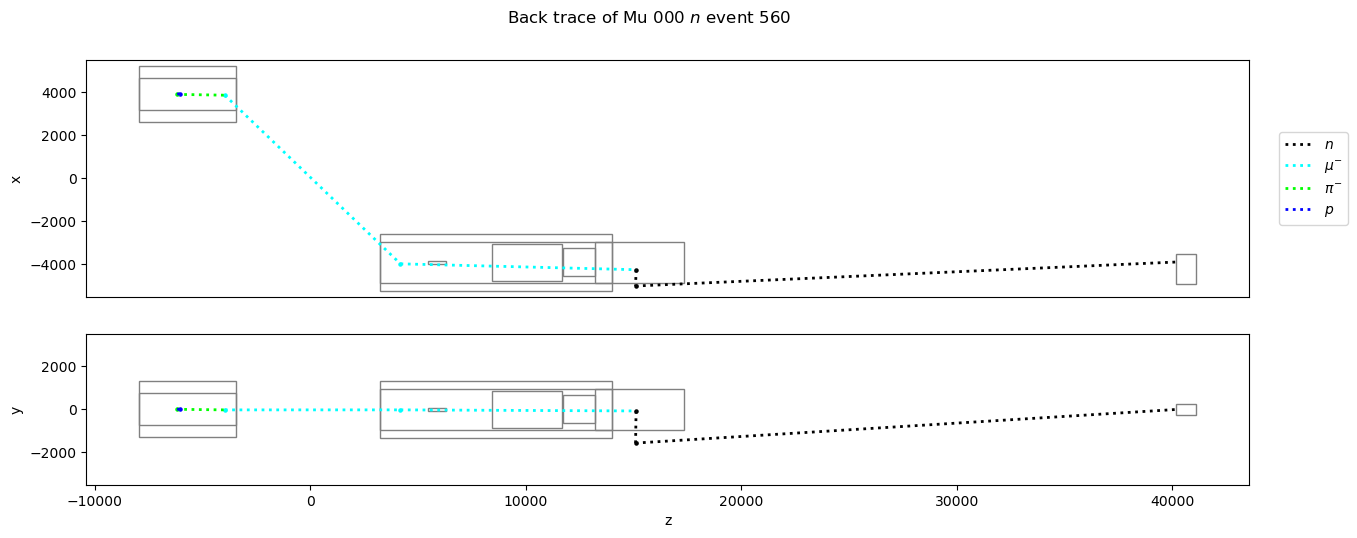

------------------------------------------------------------------------------


level_0                       647
tag                            Mu
fileno                          0
index                         600
time                  5833.716551
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3828.055196
y                       37.759492
z                         40185.4
startx               -4804.154469
starty                -686.360207
startz               15520.060911
starttime              2117.48584
E                      284.462258
weight                   1.005488
Name: 600, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,3614,Mu,0,600,2110.314453,2117.485840,97,2112,-4716.388359,-647.657199,15532.299399,1.336021e+03
1,3615,Mu,0,600,2097.450439,2110.314453,115,2112,-4211.399806,-161.989477,15767.225036,1.773877e+04
2,3616,Mu,0,600,119.944145,200.947571,56,13,-3919.913010,-55.729804,4179.000000,1.909907e+04
3,3617,Mu,0,600,50.611649,120.069611,14,13,3439.910454,54.875569,-1370.747637,1.955993e+04
4,3618,Mu,0,600,17.518116,50.611649,101,-211,3913.807675,-2.314527,-6121.276648,3.247865e+04
5,3619,Mu,0,600,17.297773,17.518116,56,2212,3929.551485,-2.272330,-6057.503202,8.000000e+06


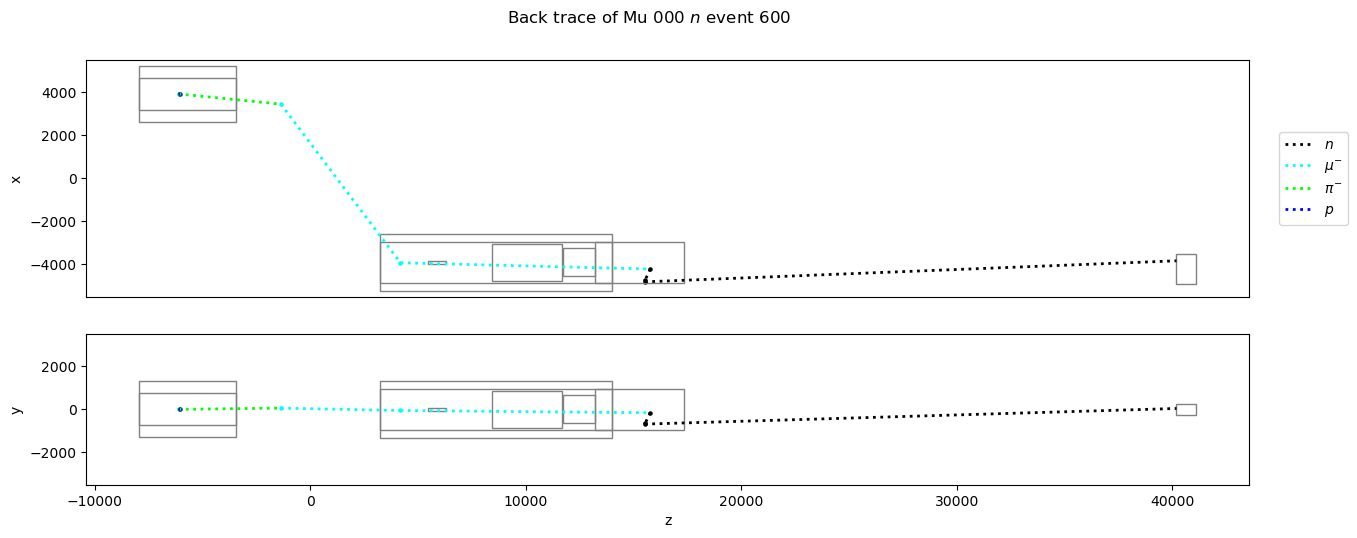

------------------------------------------------------------------------------


level_0                          687
tag                               Mu
fileno                             0
index                            640
time                 10757268.413186
virtualdetectorId                101
creationCode                      97
pdgId                           2112
x                       -3984.149889
y                         -46.020357
z                           40185.38
startx                  -4903.413295
starty                   -189.548602
startz                   5883.392274
starttime                  865.17041
E                           0.000062
weight                      1.005488
Name: 640, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,3837,Mu,0,640,829.169983,865.170410,115,2112,-3868.104189,17.860091,5804.310785,4.554579e+03
1,3838,Mu,0,640,185.489639,204.150528,56,13,-3885.447325,2.261944,4179.000000,6.916824e+03
2,3839,Mu,0,640,19.308996,185.682953,14,13,3927.640937,40.009304,-5515.815279,8.807125e+03
3,3840,Mu,0,640,14.177173,19.308996,101,-211,3912.229793,1.456332,-6127.841385,5.295698e+04
4,3841,Mu,0,640,14.167389,14.177173,101,2212,3913.134315,1.614664,-6125.524336,8.415644e+05
5,3842,Mu,0,640,13.932674,14.167389,56,2212,3930.262452,1.765154,-6057.680465,8.000000e+06


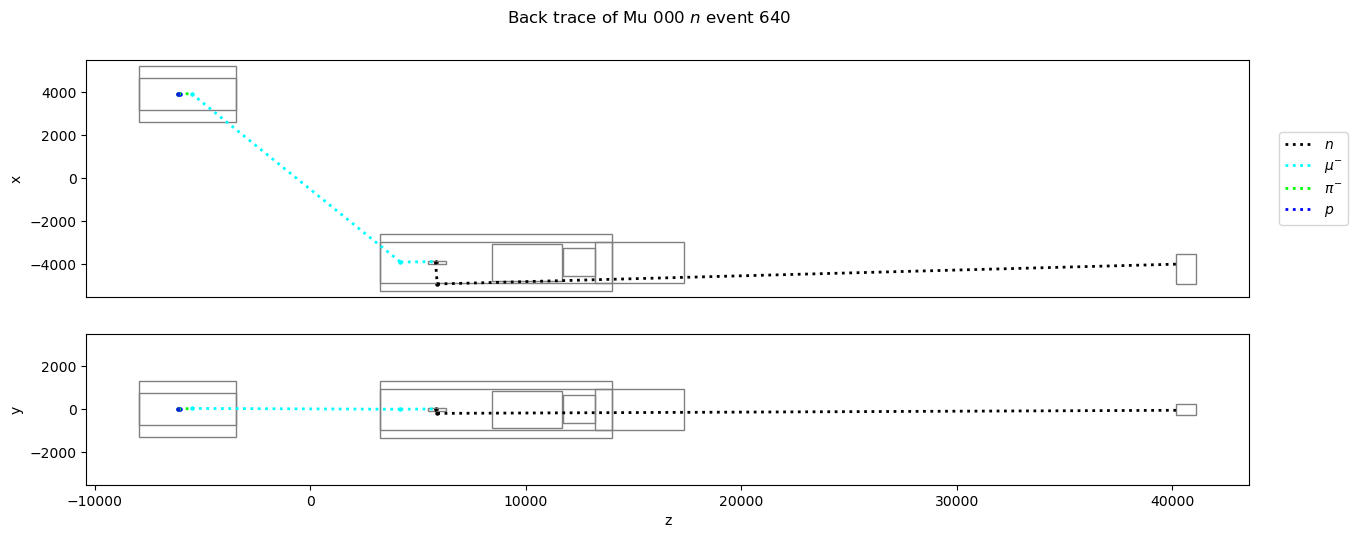

------------------------------------------------------------------------------


level_0                       727
tag                            Mu
fileno                          1
index                          23
time                  1475.207608
virtualdetectorId             101
creationCode                  115
pdgId                        2112
x                    -3832.400436
y                      -16.091673
z                        40185.38
startx               -3909.189488
starty                  -41.85779
startz                5804.364829
starttime               806.90741
E                    14147.378634
weight                   1.005488
Name: 680, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,4069,Mu,1,23,100.611092,119.861412,56,13,-3916.775603,-36.610295,4179.000000,5.255749e+03
1,4070,Mu,1,23,-63.625084,100.830414,14,13,3895.138707,-12.323695,-5601.834140,6.820723e+03
2,4071,Mu,1,23,-68.480522,-63.625084,101,-211,3898.856093,-0.300800,-6185.830198,4.331424e+04
3,4072,Mu,1,23,-68.923126,-68.480522,56,2212,3930.662204,-0.331514,-6057.780135,8.000000e+06


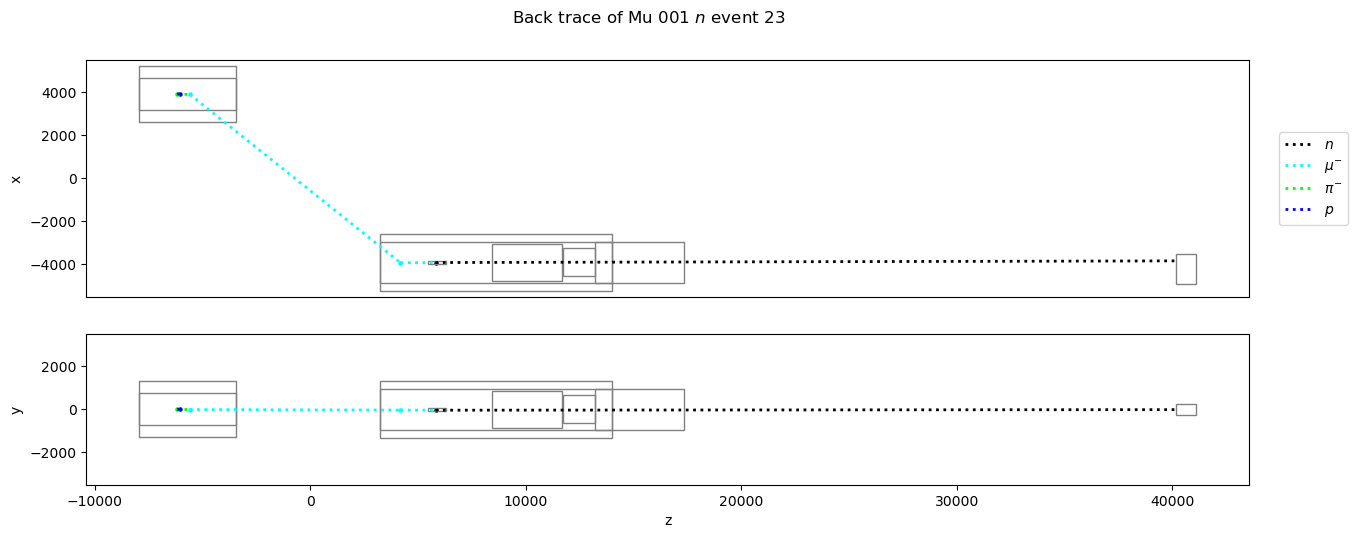

------------------------------------------------------------------------------


level_0                      767
tag                           Mu
fileno                         1
index                         63
time                 2814.787998
virtualdetectorId            101
creationCode                  97
pdgId                       2112
x                   -3925.078497
y                       4.559493
z                        40185.4
startx              -3883.654746
starty                 44.597039
startz               40214.87696
starttime            2804.287109
E                      198.57968
weight                  1.005488
Name: 720, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,4268,Mu,1,63,2784.652588,2804.287109,97,2112,-3886.800264,21.878378,40217.995859,3.578296e+02
1,4269,Mu,1,63,248.770660,2784.652588,97,2112,-4019.829358,175.193884,17250.538070,9.169317e+03
2,4270,Mu,1,63,242.853348,248.770660,115,2112,-3804.921437,-66.661049,17179.265036,1.682650e+04
3,4271,Mu,1,63,73.315727,159.747787,56,13,-3850.161886,-105.554921,4179.000000,1.998492e+04
4,4272,Mu,1,63,-27.173676,73.439011,14,13,3969.754305,-58.065176,-4602.373586,2.090576e+04
5,4273,Mu,1,63,-53.987915,-27.173676,101,-211,3917.035511,1.706807,-6105.127949,1.802250e+04
6,4274,Mu,1,63,-54.153072,-53.987915,56,2212,3928.917020,1.777191,-6057.345012,8.000000e+06


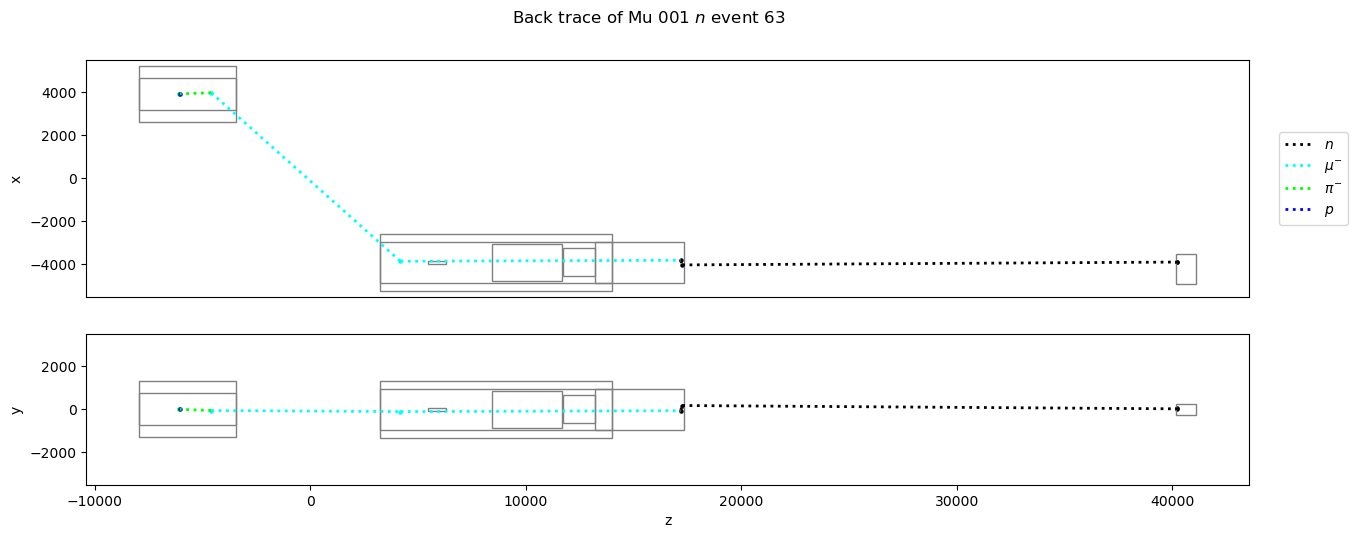

------------------------------------------------------------------------------


level_0                       807
tag                            Mu
fileno                          1
index                         103
time                 14561.083493
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3908.625373
y                       45.934243
z                        40185.38
startx               -3866.394632
starty               -1557.549393
startz               15184.179432
starttime             2120.491211
E                       24.373425
weight                   1.005488
Name: 760, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,4484,Mu,1,103,1910.092041,2120.491211,97,2112,-4650.575087,-1941.450574,14227.563429,1.612700e+03
1,4485,Mu,1,103,1872.903809,1910.092041,115,2112,-3663.610529,-292.354661,15315.793855,1.994775e+04
2,4486,Mu,1,103,97.125450,166.091171,56,13,-3849.504624,-55.577535,4179.000000,2.075570e+04
3,4487,Mu,1,103,6.658634,97.246956,14,13,3986.282560,-29.319856,-4980.743203,2.139653e+04
4,4488,Mu,1,103,-0.821299,6.658634,101,-211,3909.703636,-0.480087,-6140.730896,4.717617e+04
5,4489,Mu,1,103,-1.108297,-0.821299,56,2212,3930.719734,-0.614491,-6057.794479,8.000000e+06


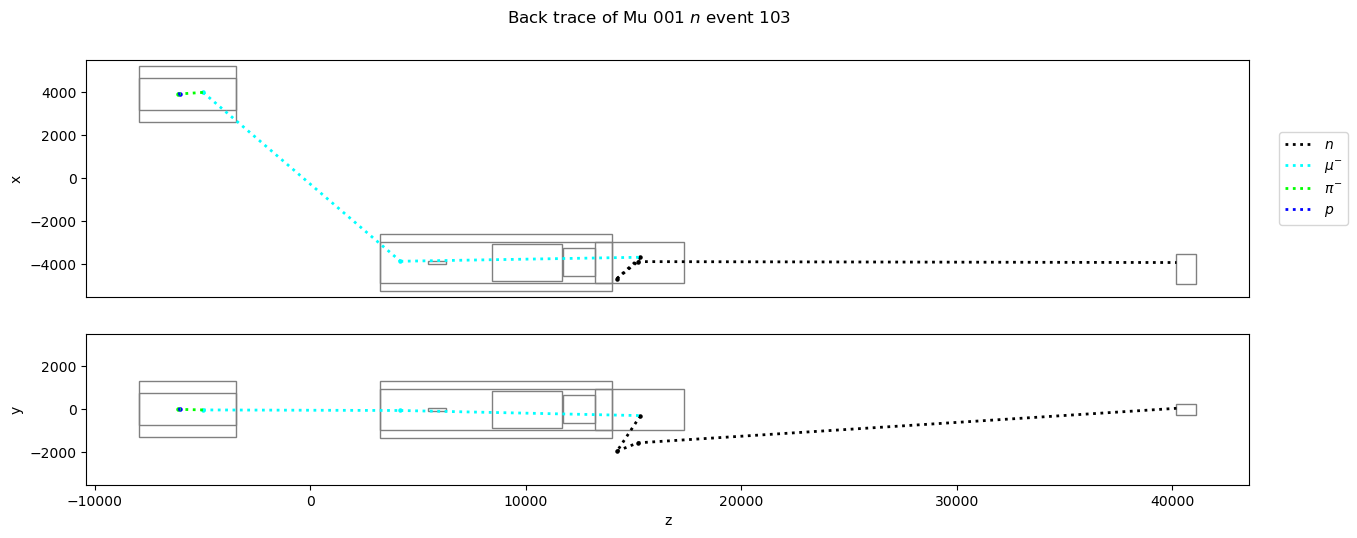

------------------------------------------------------------------------------


level_0                       847
tag                            Mu
fileno                          1
index                         143
time                 22314.953959
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3929.708133
y                       51.694931
z                         40185.4
startx               -3566.825149
starty                1019.225805
startz                5657.423454
starttime             1213.819458
E                       14.424614
weight                   1.005488
Name: 800, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,4692,Mu,1,143,1213.560913,1213.819458,97,2112,-3570.560662,1014.531087,5660.508401,3.580305e+03
1,4693,Mu,1,143,1186.717896,1213.560913,115,2112,-3859.529347,-0.045556,5759.881437,8.252161e+03
2,4694,Mu,1,143,209.001984,229.225510,56,13,-3905.170007,-48.289340,4179.000000,5.389905e+03
3,4695,Mu,1,143,56.831718,209.218735,14,13,3886.980663,-11.458706,-2904.963559,6.532341e+03
4,4696,Mu,1,143,21.626305,56.831718,101,-211,3917.627622,-0.120753,-6100.626086,4.366318e+04
5,4697,Mu,1,143,21.476278,21.626305,56,2212,3928.415255,0.041943,-6057.219908,8.000000e+06


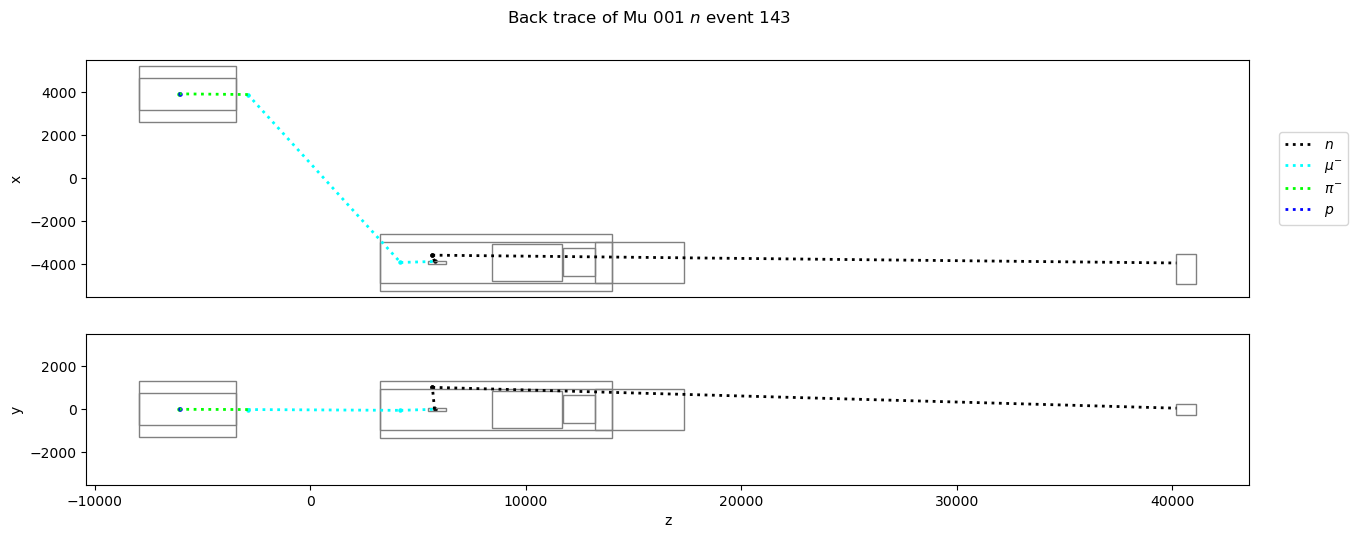

------------------------------------------------------------------------------


level_0                         887
tag                              Mu
fileno                            1
index                           183
time                 7614736.396928
virtualdetectorId               101
creationCode                     97
pdgId                          2112
x                      -3881.250985
y                        -52.705816
z                          40185.38
startx                 -3659.152578
starty                    -40.00671
startz                 17361.440521
starttime                744.160156
E                           0.00007
weight                     1.005488
Name: 840, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,4906,Mu,1,183,734.587769,744.160156,115,2112,-3880.814659,23.298184,17415.724819,3.348066e+03
1,4907,Mu,1,183,126.456917,213.709839,56,13,-3884.218737,-76.091536,4179.000000,2.073365e+04
2,4908,Mu,1,183,20.599867,126.578476,14,13,3851.911161,-5.637038,-5794.097557,2.147661e+04
3,4909,Mu,1,183,16.808023,20.599867,99,-211,3917.013048,0.216738,-6117.503297,2.062221e+04
4,4910,Mu,1,183,16.735704,16.808023,101,211,3918.821291,0.157590,-6096.014280,1.227023e+06
5,4911,Mu,1,183,16.601656,16.735704,56,2212,3928.447308,0.117350,-6057.227899,8.000000e+06


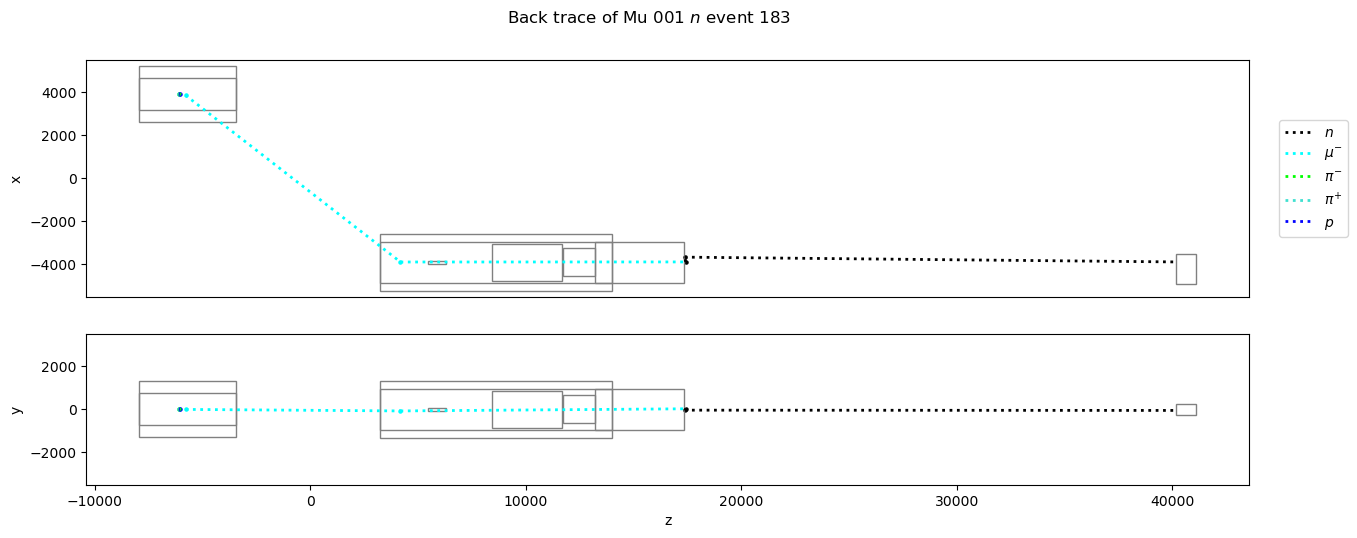

------------------------------------------------------------------------------


level_0                       927
tag                            Mu
fileno                          1
index                         223
time                 32168.967904
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3959.252735
y                       -6.692591
z                        40185.38
startx               -3191.812355
starty                    86.8277
startz                9996.907539
starttime              922.545654
E                        0.348014
weight                   1.005488
Name: 880, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,5122,Mu,1,223,798.410767,922.545654,115,2112,-3888.953458,-46.316983,5626.534180,6.763657e+03
1,5123,Mu,1,223,304.473328,331.889740,56,13,-3890.334674,-28.498923,4179.000000,3.943439e+03
2,5124,Mu,1,223,30.873682,304.724274,14,13,3975.875473,-59.727830,-4126.103497,5.648130e+03
3,5125,Mu,1,223,3.532285,30.873682,101,-211,3922.060947,-0.877874,-6091.431534,1.999218e+04
4,5126,Mu,1,223,3.415781,3.532285,56,2212,3930.375458,-0.942274,-6057.708641,8.000000e+06


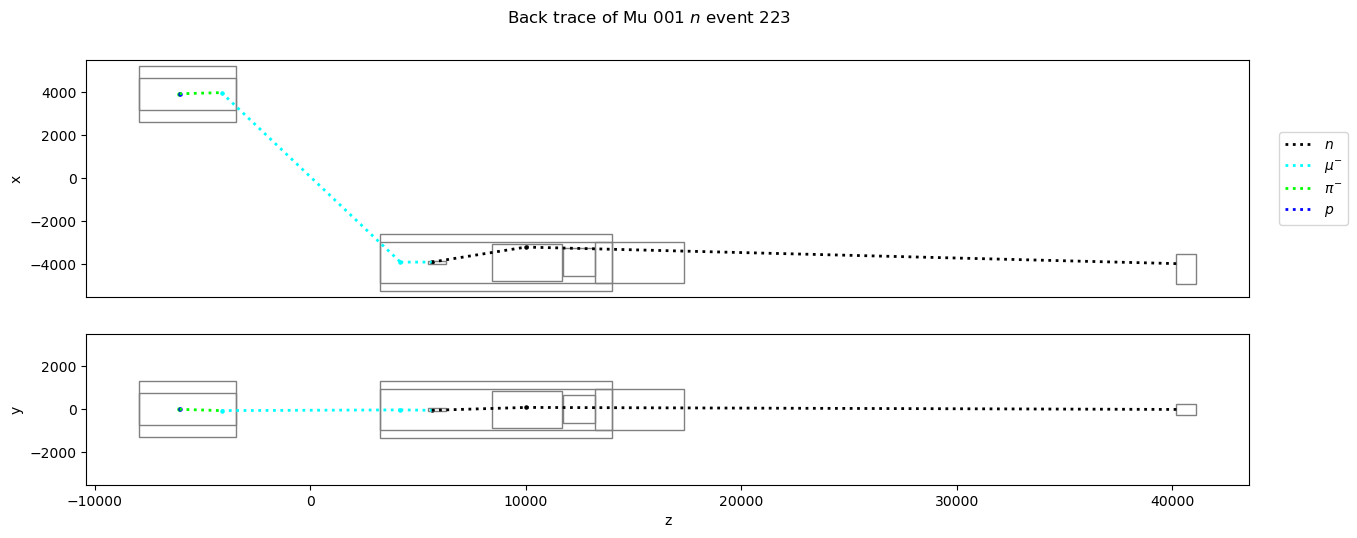

------------------------------------------------------------------------------


level_0                       967
tag                            Mu
fileno                          1
index                         263
time                  3867.730046
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3825.702818
y                       56.241872
z                         40185.4
startx               -3830.138641
starty                   30.50087
startz               40266.811437
starttime             3844.931641
E                      265.156526
weight                   1.005488
Name: 920, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,5342,Mu,1,263,3835.711182,3844.931641,97,2112,-3792.391465,-20.543392,40232.320511,4.070226e+02
1,5343,Mu,1,263,232.989105,3835.711182,115,2112,-3873.903826,21.042913,6004.284679,2.936127e+03
2,5344,Mu,1,263,139.849350,161.554123,56,13,-3936.120959,8.531331,4179.000000,7.768072e+03
3,5345,Mu,1,263,7.452344,140.032761,14,13,3877.389833,-1.997251,-3349.919977,8.823787e+03
4,5346,Mu,1,263,-13.413998,7.452344,101,-211,3920.026554,-0.099130,-6096.393689,4.189887e+04
5,5347,Mu,1,263,-13.548305,-13.413998,56,2212,3929.901270,-0.229560,-6057.590413,8.000000e+06


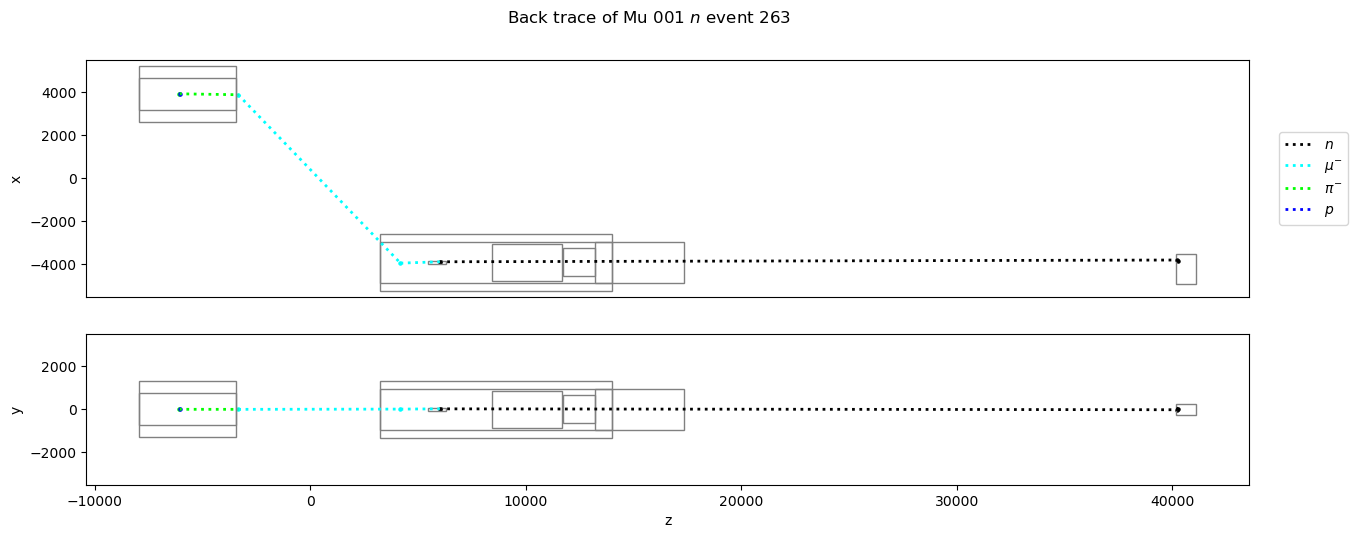

------------------------------------------------------------------------------


level_0                     1007
tag                           Mu
fileno                         1
index                        303
time                 4425.170246
virtualdetectorId            101
creationCode                 115
pdgId                       2112
x                   -3939.109664
y                      29.866507
z                        40185.4
startx              -3901.359146
starty                -65.124822
startz               6270.963582
starttime             657.627747
E                     707.385707
weight                  1.005488
Name: 960, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,5559,Mu,1,303,165.516663,192.683731,56,13,-3928.499775,-47.979512,4179.000000,6.507173e+03
1,5560,Mu,1,303,44.240135,165.715424,14,13,3643.923225,-12.655922,-1719.297477,7.083297e+03
2,5561,Mu,1,303,-7.387287,44.240135,101,-211,3931.062727,-0.453960,-6058.165850,1.193191e+04
3,5562,Mu,1,303,-7.388218,-7.387287,56,2212,3931.129893,-0.454009,-6057.896743,8.000000e+06


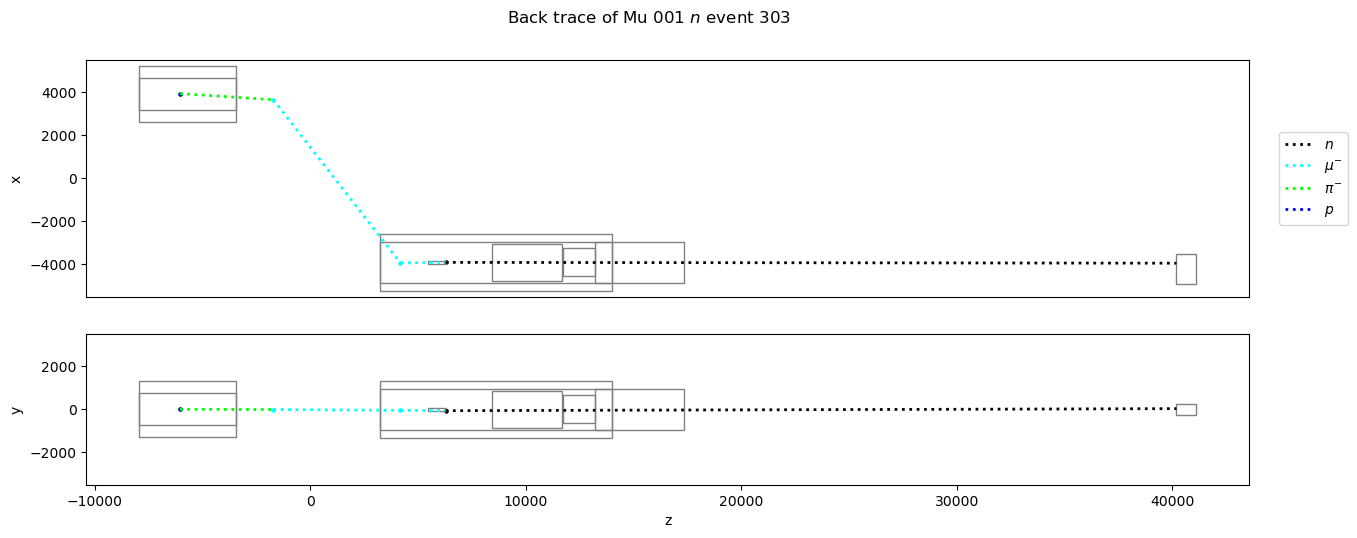

------------------------------------------------------------------------------


level_0                       1047
tag                             Mu
fileno                           1
index                          343
time                 121739.377255
virtualdetectorId              101
creationCode                   115
pdgId                         2112
x                     -3912.846997
y                         -6.59786
z                         40185.38
startx                -3961.986572
starty                  -23.038753
startz                 5759.851121
starttime              1691.400879
E                         0.010055
weight                    1.005488
Name: 1000, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,5776,Mu,1,343,199.872589,220.412430,56,13,-3908.142240,56.320258,4179.000000,6.766269e+03
1,5777,Mu,1,343,-11.149699,200.067841,14,13,3822.624090,52.073014,-6198.380825,3.097608e+04
2,5778,Mu,1,343,-12.825096,-11.149699,101,-211,3917.078152,0.407242,-6110.140083,2.919602e+04
3,5779,Mu,1,343,-13.006537,-12.825096,56,2212,3930.275598,0.220016,-6057.683743,8.000000e+06


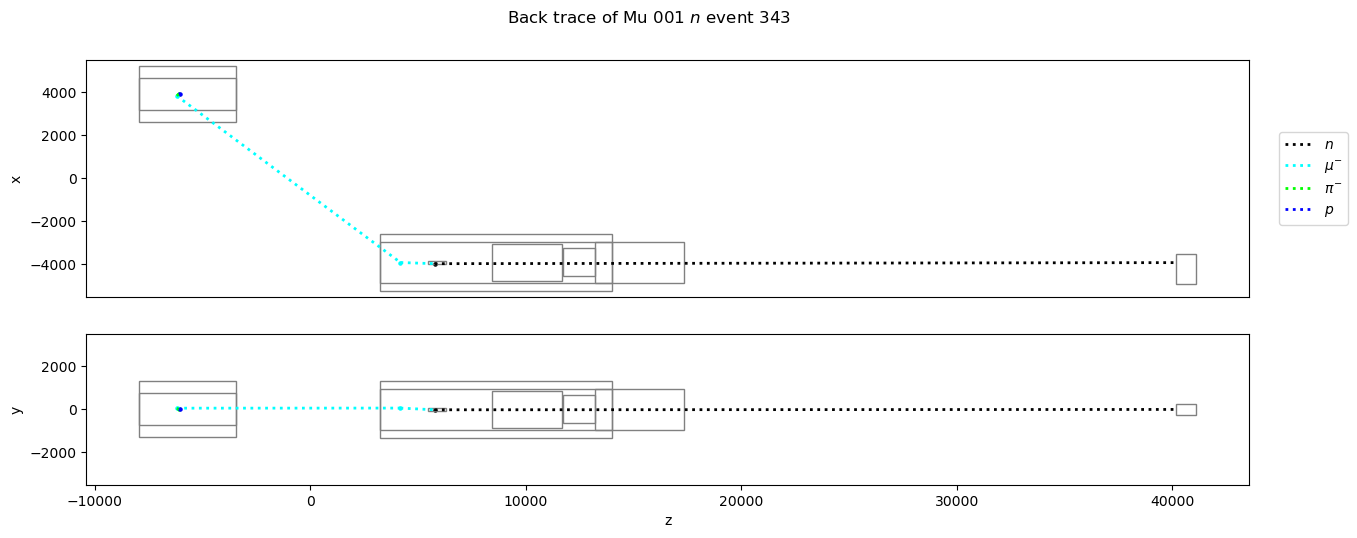

------------------------------------------------------------------------------


level_0                         1087
tag                               Mu
fileno                             1
index                            383
time                 17641670.505008
virtualdetectorId                101
creationCode                      97
pdgId                           2112
x                       -3912.199985
y                         -32.997698
z                           40185.38
startx                  -4845.169386
starty                   -906.174578
startz                   5325.322231
starttime                2105.583252
E                           0.000033
weight                      1.005488
Name: 1040, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,5986,Mu,1,383,1759.384399,2105.583252,97,2112,-3923.150191,-16.459336,5470.993265,3.642447e+03
1,5987,Mu,1,383,1742.597656,1759.384399,115,2112,-3877.746880,15.636504,6070.987831,6.808242e+03
2,5988,Mu,1,383,243.127991,273.053741,56,13,-3793.800647,1.713798,4179.000000,7.258943e+03
3,5989,Mu,1,383,25.410501,243.317108,14,13,3907.855266,-3.275039,-4142.944502,8.434105e+03
4,5990,Mu,1,383,-0.689781,25.410501,101,-211,3914.376840,0.414693,-6118.754676,2.493780e+04
5,5991,Mu,1,383,-0.901453,-0.689781,56,2212,3929.873384,0.468906,-6057.583460,8.000000e+06


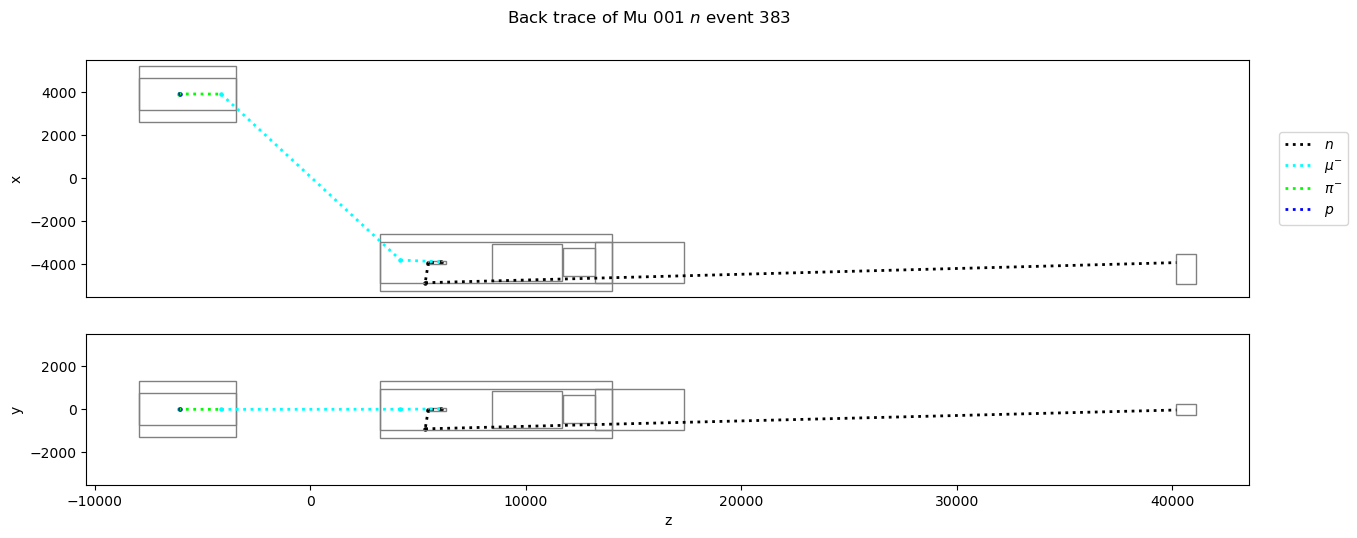

------------------------------------------------------------------------------


level_0                      1127
tag                            Mu
fileno                          1
index                         423
time                 64198.650914
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3878.452202
y                       69.809521
z                        40185.38
startx               -4633.128684
starty                 323.922951
startz                4075.851553
starttime              874.608276
E                        1.922659
weight                   1.005488
Name: 1080, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,6201,Mu,1,423,873.712036,874.608276,97,2112,-4637.432870,330.872046,4089.813819,1.707828e+03
1,6202,Mu,1,423,786.909180,873.712036,115,2112,-3976.611725,1.614211,5515.483701,4.901617e+03
2,6203,Mu,1,423,343.969757,369.484192,56,13,-3996.897780,7.890329,4179.000000,3.102386e+03
3,6204,Mu,1,423,114.148659,344.251068,14,13,3756.818820,-40.538912,-2225.532020,4.833880e+03
4,6205,Mu,1,423,52.673328,114.148659,101,-211,3896.887674,-0.165315,-6194.560436,4.525483e+04
5,6206,Mu,1,423,52.200699,52.673328,56,2212,3931.349147,-0.170236,-6057.951409,8.000000e+06


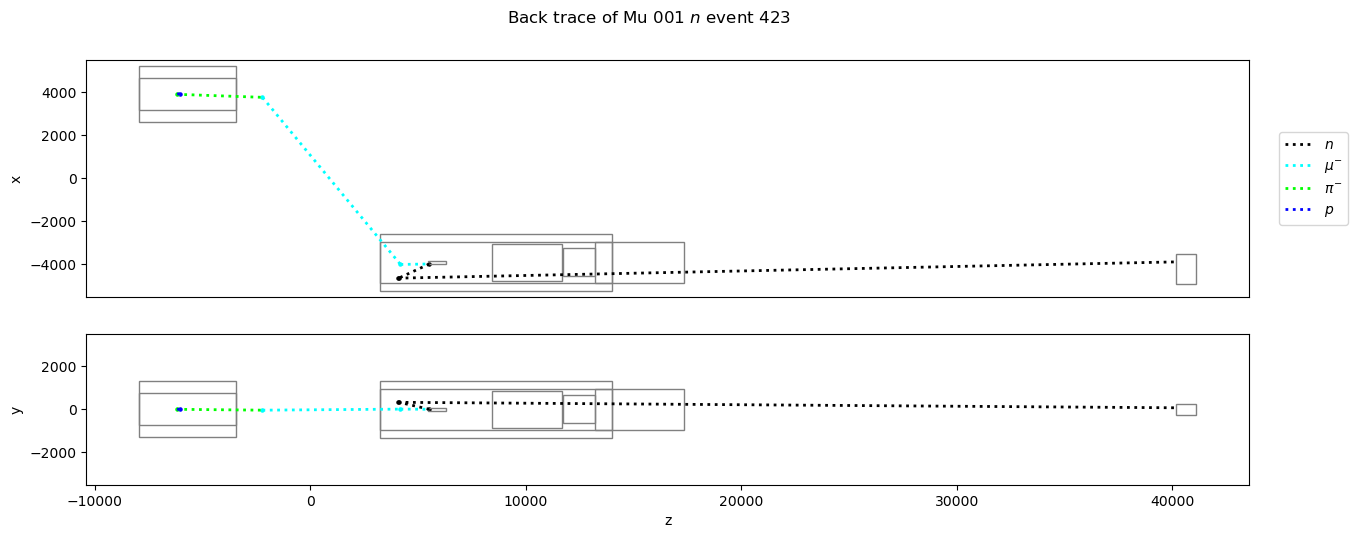

------------------------------------------------------------------------------


level_0                      1167
tag                            Mu
fileno                          1
index                         463
time                 68947.381731
virtualdetectorId             101
creationCode                  115
pdgId                        2112
x                    -3919.487484
y                       18.478965
z                         40185.4
startx               -3852.166057
starty                 -34.750144
startz               17290.813144
starttime              2270.64209
E                        0.024642
weight                   1.005488
Name: 1120, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,6414,Mu,1,463,150.906647,289.466309,56,13,-3857.457753,36.302745,4179.000000,1.260585e+04
1,6415,Mu,1,463,58.844494,151.055145,14,13,3844.778550,57.754573,-2387.375832,1.315199e+04
2,6416,Mu,1,463,17.103949,58.844494,101,-211,3906.731829,0.591527,-6152.474774,4.249947e+04
3,6417,Mu,1,463,16.776310,17.103949,56,2212,3930.408093,1.069345,-6057.716778,8.000000e+06


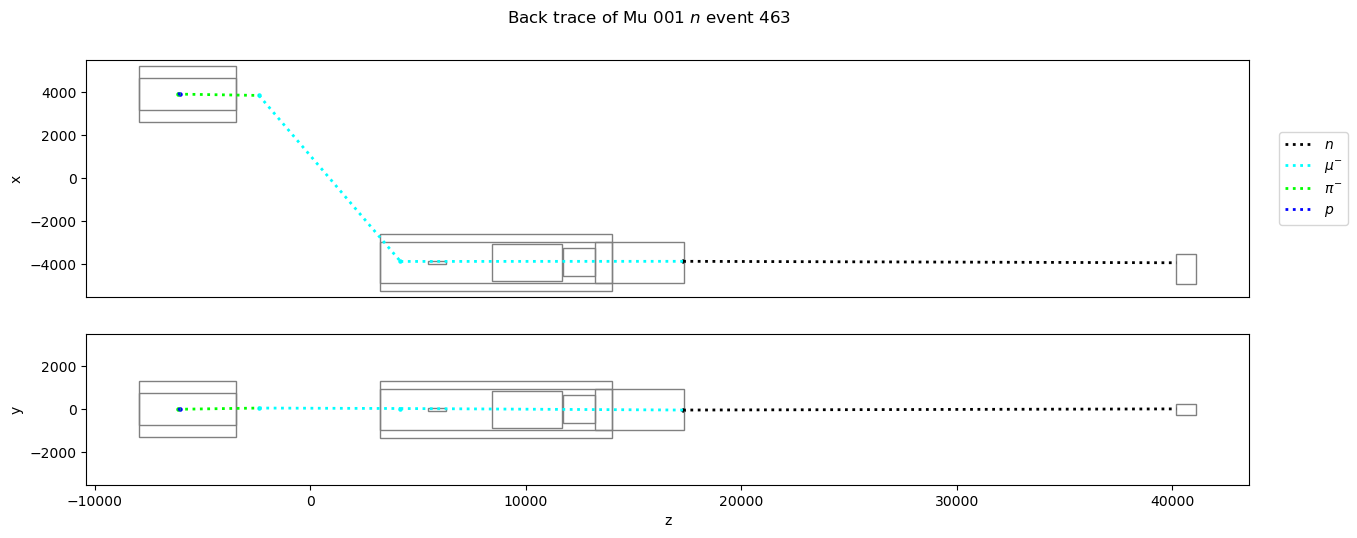

------------------------------------------------------------------------------


level_0                      1207
tag                            Mu
fileno                          1
index                         503
time                  1067.269996
virtualdetectorId             101
creationCode                  115
pdgId                        2112
x                    -3893.238513
y                       41.294493
z                        40185.38
startx               -3871.156788
starty                   22.58573
startz                5737.699122
starttime              691.631042
E                    47304.563425
weight                   1.005488
Name: 1160, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,6646,Mu,1,503,230.049881,253.868546,56,13,-3824.708103,15.796264,4179.000000,5.545966e+03
1,6647,Mu,1,503,7.810110,230.263809,14,13,3921.047522,18.885471,-5407.912779,7.177805e+03
2,6648,Mu,1,503,-7.419214,7.810110,101,-211,3922.540794,-0.665645,-6088.711086,3.604818e+04
3,6649,Mu,1,503,-7.526473,-7.419214,56,2212,3930.227083,-0.659185,-6057.671647,8.000000e+06


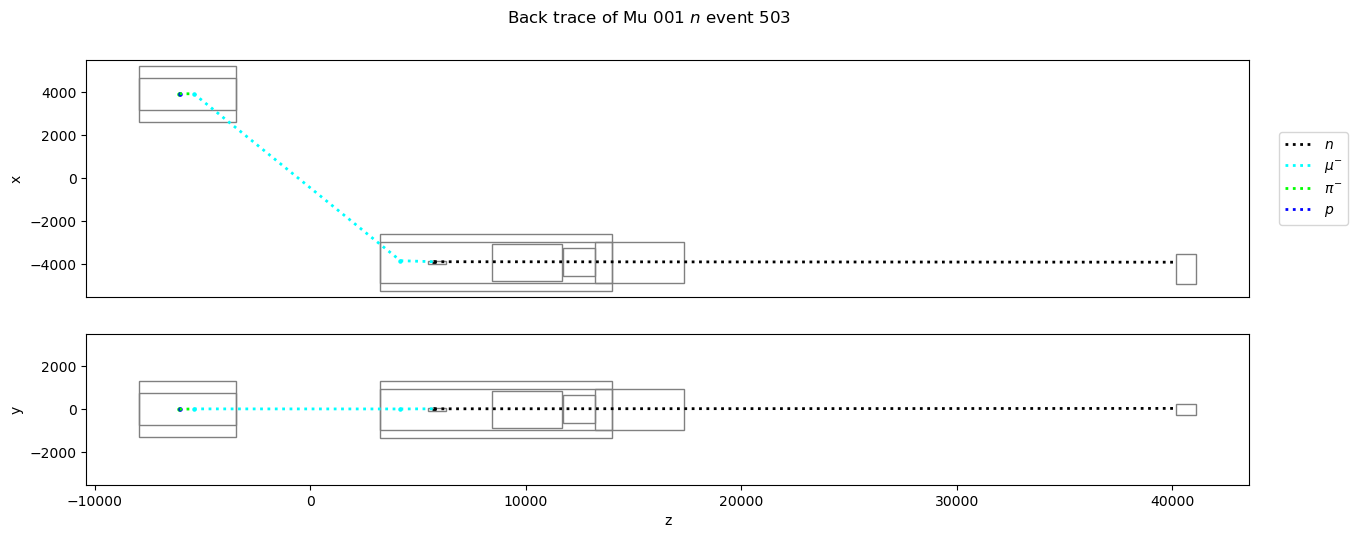

------------------------------------------------------------------------------


level_0                       1247
tag                             Mu
fileno                           1
index                          543
time                 135842.480896
virtualdetectorId              101
creationCode                    97
pdgId                         2112
x                     -3861.003311
y                         5.194401
z                         40185.38
startx                -3185.912169
starty                 3841.963777
startz                15640.698061
starttime              2461.795654
E                         0.233015
weight                    1.005488
Name: 1200, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,6854,Mu,1,543,2407.577637,2461.795654,115,2112,-3640.949268,-224.003780,15448.313918,3.493323e+04
1,6855,Mu,1,543,173.173355,262.768433,56,13,-3941.340311,-24.257505,4179.000000,1.679144e+04
2,6856,Mu,1,543,134.243500,173.305359,14,13,-2547.295672,31.350008,448.771830,1.679144e+04
3,6857,Mu,1,543,-25.951508,134.243500,14,-211,3874.700043,21.883503,-6304.559526,9.533443e+03
4,6858,Mu,1,543,-26.528154,-25.951508,101,3122,3885.256481,2.101570,-6243.452627,8.862782e+04
5,6859,Mu,1,543,-27.169439,-26.528154,56,2212,3930.409857,0.572778,-6057.717218,8.000000e+06


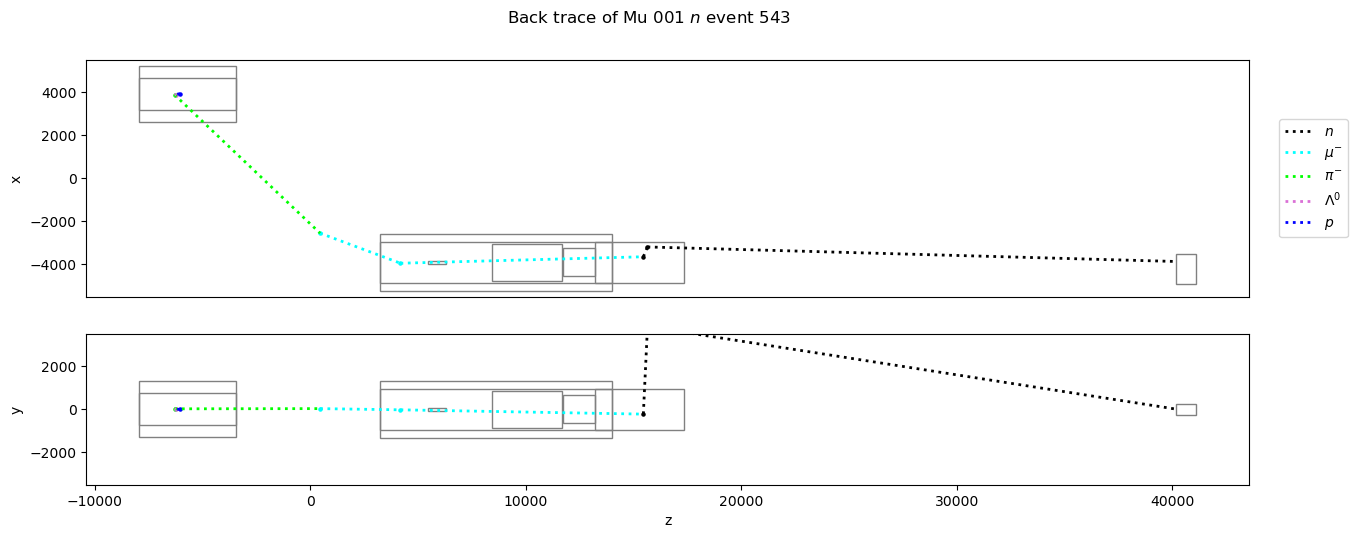

------------------------------------------------------------------------------


level_0                        1287
tag                              Mu
fileno                            1
index                           583
time                 1009506.862737
virtualdetectorId               101
creationCode                    115
pdgId                          2112
x                      -3864.324413
y                         -0.221631
z                          40185.38
startx                 -4000.804052
starty                   -66.596395
startz                 17158.374117
starttime               1617.214355
E                          0.000361
weight                     1.005488
Name: 1240, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,7073,Mu,1,583,153.933792,292.862976,56,13,-3917.541329,-6.953760,4179.000000,1.145352e+04
1,7074,Mu,1,583,45.380554,154.088470,14,13,3887.908356,-23.254640,-4415.819934,1.254498e+04
2,7075,Mu,1,583,16.906570,45.380554,101,-211,3886.741236,-1.643516,-6241.666735,2.904050e+04
3,7076,Mu,1,583,16.272335,16.906570,56,2212,3932.141697,-0.809802,-6058.149014,8.000000e+06


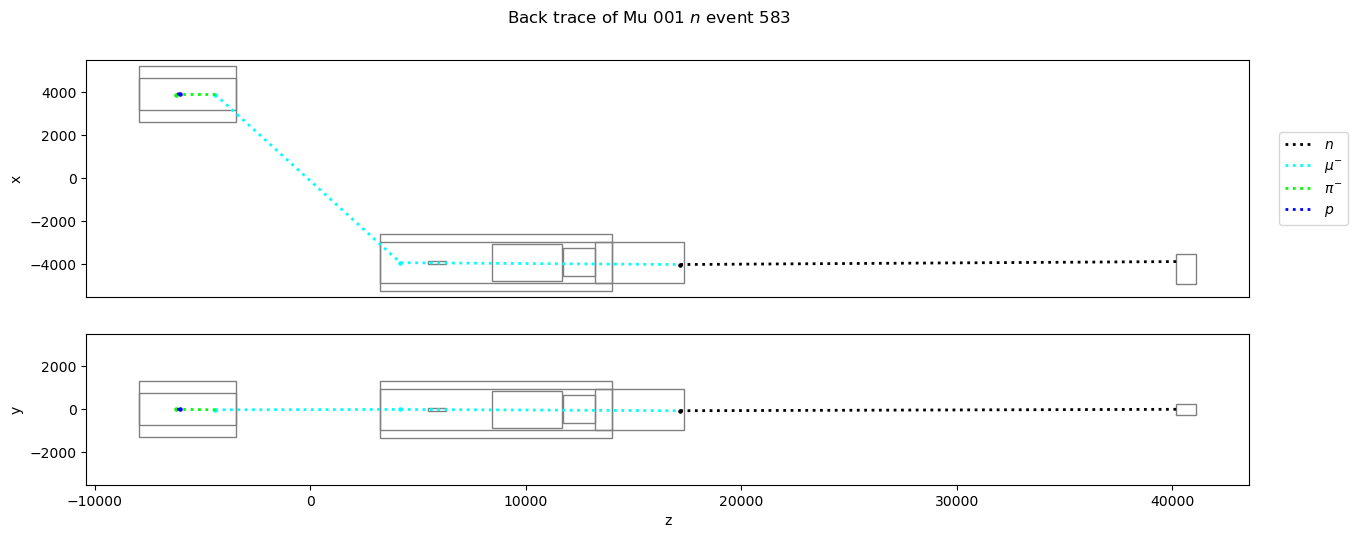

------------------------------------------------------------------------------


level_0                        1327
tag                              Mu
fileno                            1
index                           623
time                 4411598.476873
virtualdetectorId               101
creationCode                     97
pdgId                          2112
x                      -3879.164164
y                         18.948601
z                          40185.38
startx                 -2882.017139
starty                  -653.384208
startz                  2847.855516
starttime               1301.379028
E                          0.000065
weight                     1.005488
Name: 1280, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,7316,Mu,1,623,1039.372070,1301.379028,97,2112,-2986.096682,250.251578,4181.222586,1.654444e+03
1,7317,Mu,1,623,987.962646,1039.372070,115,2112,-3930.306189,61.624181,5915.440309,8.915503e+03
2,7318,Mu,1,623,115.204994,135.225113,56,13,-3934.678250,31.781989,4179.000000,6.478444e+03
3,7319,Mu,1,623,-34.933243,115.404152,14,13,3883.686834,30.838796,-5915.394016,8.173000e+03
4,7320,Mu,1,623,-38.801044,-34.933243,101,-211,3929.156020,1.338905,-6058.249097,4.642390e+04
5,7321,Mu,1,623,-38.803795,-38.801044,56,2212,3929.354140,1.339253,-6057.453998,8.000000e+06


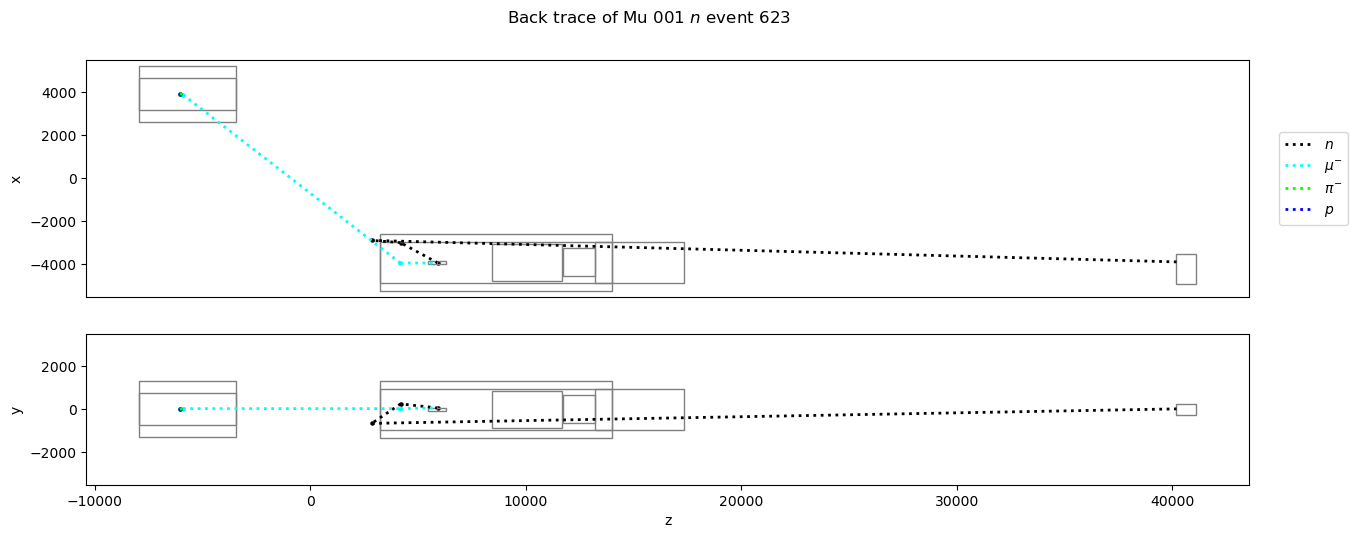

------------------------------------------------------------------------------


level_0                      1367
tag                            Mu
fileno                          1
index                         663
time                  4032.187182
virtualdetectorId             101
creationCode                  115
pdgId                        2112
x                    -3813.007566
y                        32.63025
z                        40185.38
startx                -4222.90883
starty                  37.486108
startz               16910.687099
starttime              924.101929
E                      359.595636
weight                   1.005488
Name: 1320, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,7535,Mu,1,663,118.158607,239.269348,56,13,-3868.150944,-57.521720,4179.000000,1.111130e+04
1,7536,Mu,1,663,19.230688,118.315308,14,13,3668.711490,13.951864,-1726.836621,1.170941e+04
2,7537,Mu,1,663,-9.171598,19.230688,14,-211,3927.320276,-30.724939,-6138.142085,2.452457e+04
3,7538,Mu,1,663,-9.527680,-9.171598,94,3122,3907.687976,0.128447,-6145.350884,7.493652e+04
4,7539,Mu,1,663,-9.532650,-9.527680,101,130,3907.440116,0.648317,-6145.278332,4.270306e+04
5,7540,Mu,1,663,-9.836290,-9.532650,56,2212,3929.834397,0.419390,-6057.573739,8.000000e+06


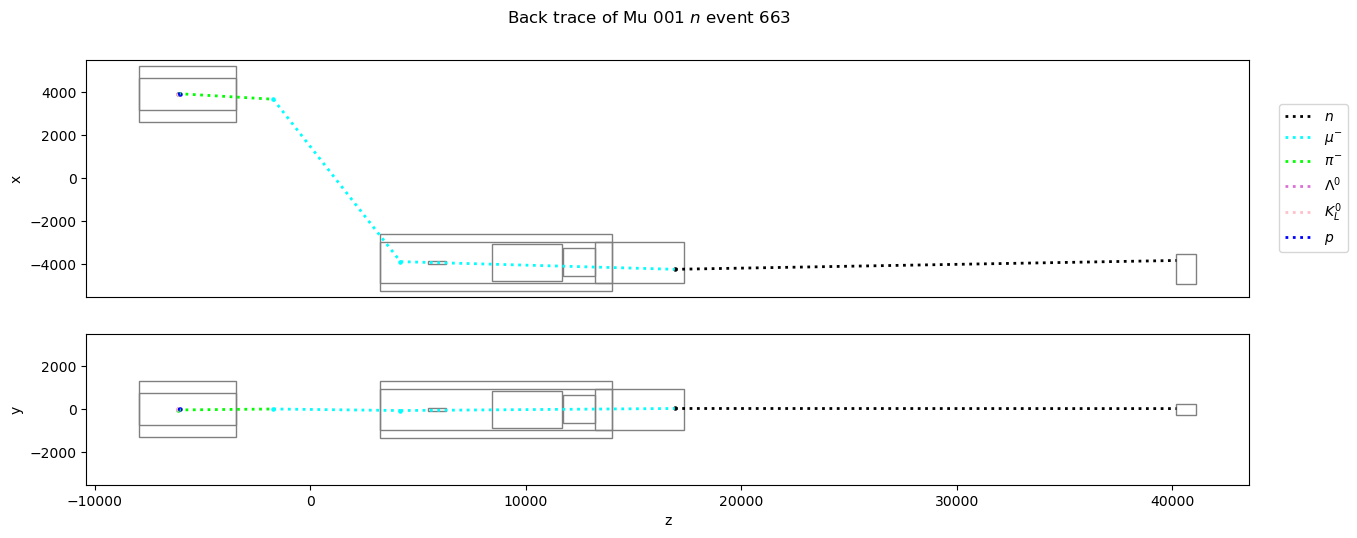

------------------------------------------------------------------------------


level_0                        1407
tag                              Mu
fileno                            2
index                            33
time                 19499248.06806
virtualdetectorId               101
creationCode                    115
pdgId                          2112
x                      -3807.315675
y                         17.284078
z                           40185.4
startx                 -3869.415351
starty                   -47.257621
startz                  5626.601611
starttime                2446.13916
E                          0.000023
weight                     1.005488
Name: 1360, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,7746,Mu,2,33,213.773727,235.411072,56,13,-3863.198339,-45.200769,4179.000000,3.364806e+03
1,7747,Mu,2,33,-4.110709,214.044342,14,13,3925.019485,-24.648378,-5761.563222,5.125206e+03
2,7748,Mu,2,33,-11.794447,-4.110709,101,-211,3923.836476,-0.852467,-6081.933209,2.650370e+04
3,7749,Mu,2,33,-11.878595,-11.794447,56,2212,3929.969822,-0.827720,-6057.607505,8.000000e+06


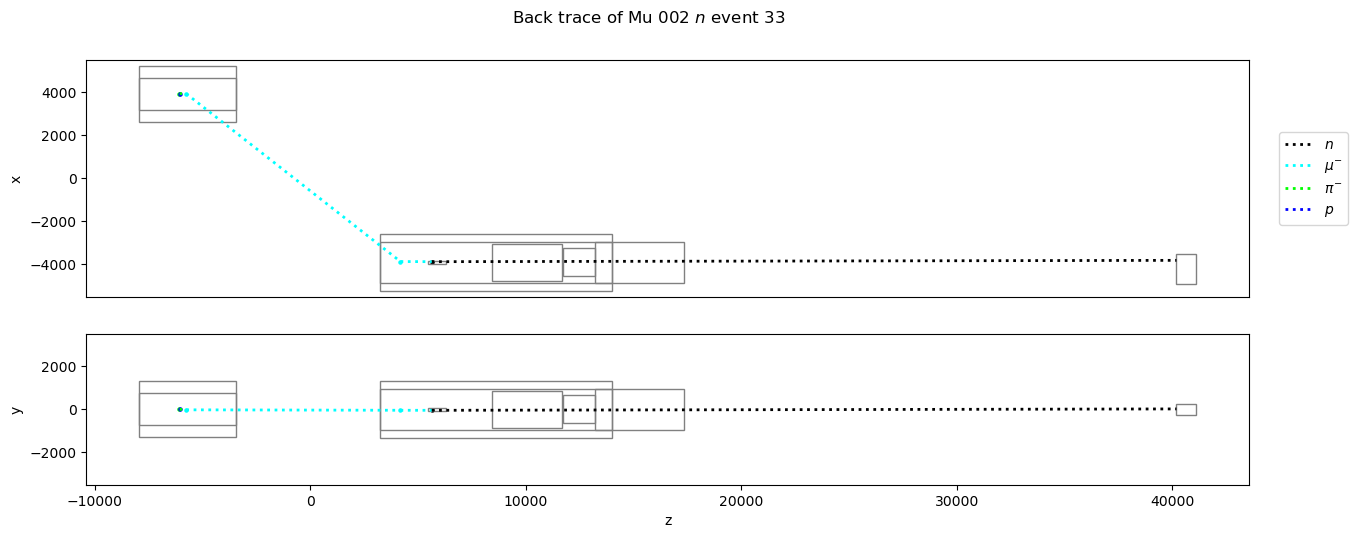

------------------------------------------------------------------------------


level_0                      1447
tag                            Mu
fileno                          2
index                          73
time                  3994.940939
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3991.937332
y                      -44.053993
z                         40185.4
startx                -4003.47268
starty                 -44.230753
startz               40216.791031
starttime             3988.687988
E                      360.938701
weight                   1.005488
Name: 1400, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,7951,Mu,2,73,3982.158691,3988.687988,97,2112,-3987.109764,-85.302872,40240.924852,5.030822e+02
1,7952,Mu,2,73,815.678528,3982.158691,115,2112,-3928.733802,9.687009,5937.698252,1.490202e+03
2,7953,Mu,2,73,208.972961,233.227005,56,13,-3961.877912,-9.168520,4179.000000,5.792993e+03
3,7954,Mu,2,73,-5.539231,209.182617,14,13,3805.050746,27.426532,-6266.248028,2.468585e+04
4,7955,Mu,2,73,-11.868454,-5.539231,101,-211,3920.903904,0.607472,-6096.247403,3.350923e+04
5,7956,Mu,2,73,-12.001571,-11.868454,56,2212,3930.533945,0.695587,-6057.748156,8.000000e+06


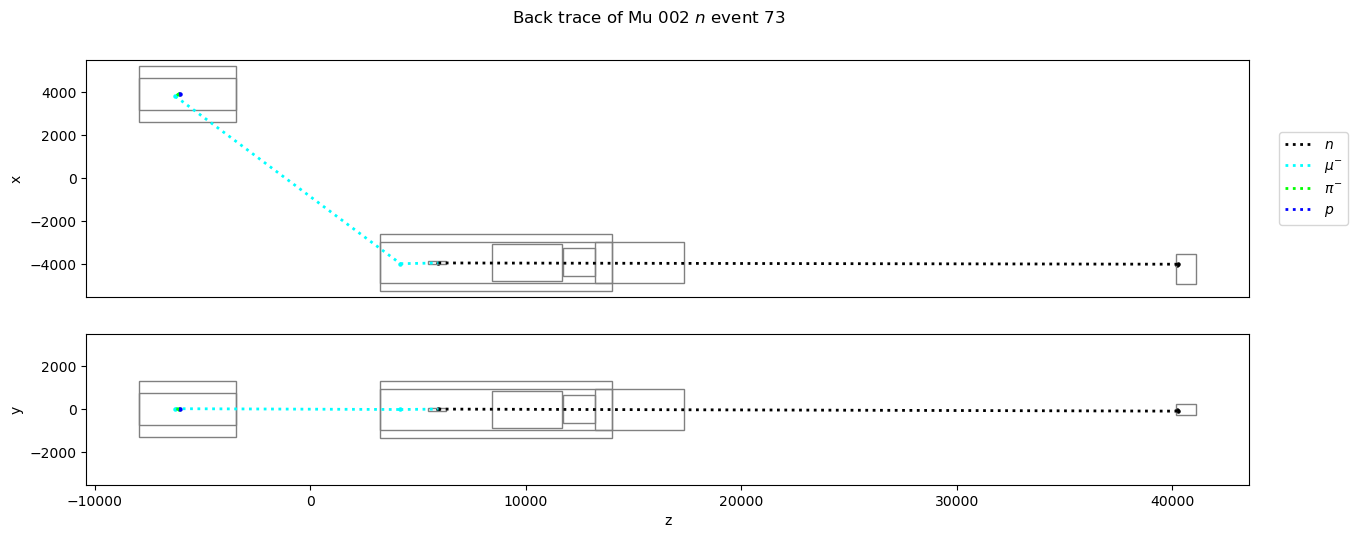

------------------------------------------------------------------------------


level_0                        1487
tag                              Mu
fileno                            2
index                           113
time                 2406366.216932
virtualdetectorId               101
creationCode                     97
pdgId                          2112
x                      -3863.824355
y                         -3.166721
z                          40185.38
startx                 -4330.167706
starty                   277.105445
startz                   2767.33801
starttime                913.720459
E                            0.0012
weight                     1.005488
Name: 1440, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,8162,Mu,2,113,699.246521,913.720459,97,2112,-4498.975188,-753.901388,6188.985282,1.619145e+03
1,8163,Mu,2,113,671.274170,699.246521,115,2112,-3935.713568,-58.961911,5671.002907,7.221176e+03
2,8164,Mu,2,113,171.519257,190.146042,56,13,-3937.780062,-25.609915,4179.000000,5.245161e+03
3,8165,Mu,2,113,-14.613805,171.738785,14,13,3902.411751,-33.185394,-6135.228535,6.594429e+03
4,8166,Mu,2,113,-16.572657,-14.613805,101,-211,3895.975329,-1.353792,-6185.992852,1.214774e+04
5,8167,Mu,2,113,-17.018135,-16.572657,56,2212,3928.781505,-1.653164,-6057.311224,8.000000e+06


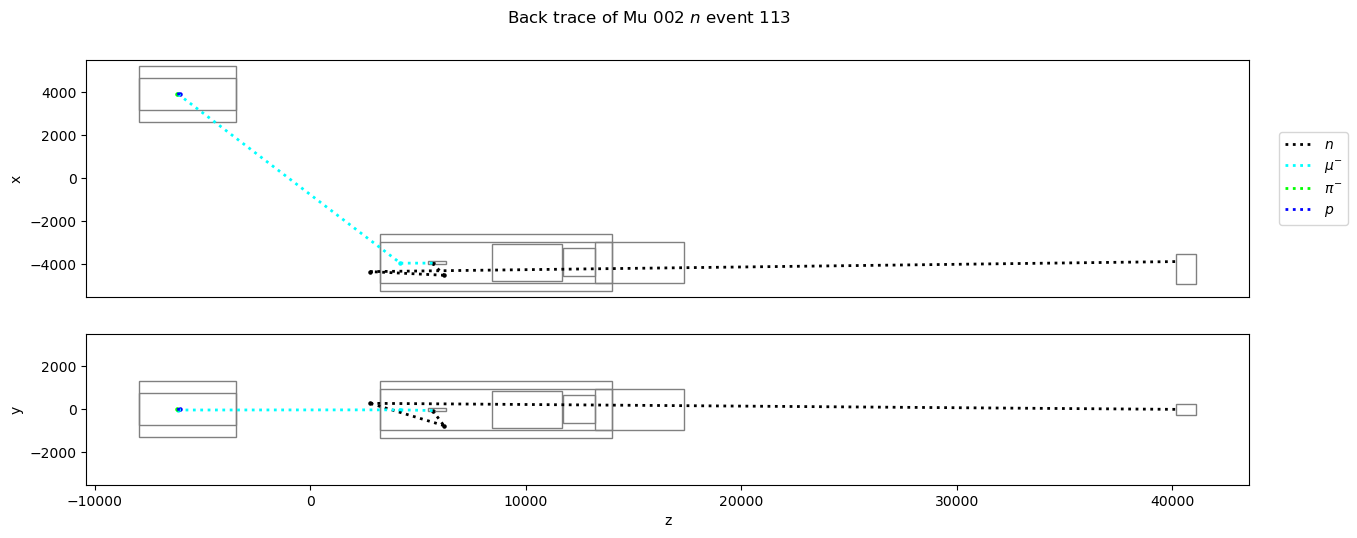

------------------------------------------------------------------------------


level_0                     1527
tag                           Mu
fileno                         2
index                        153
time                 3416.106757
virtualdetectorId            101
creationCode                 115
pdgId                       2112
x                   -3992.299111
y                      14.507574
z                       40185.38
startx              -3943.665724
starty                 59.418402
startz               5782.134566
starttime            1579.686157
E                    1839.864917
weight                  1.005488
Name: 1480, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,8379,Mu,2,153,363.236572,398.026733,56,13,-3929.287050,59.906725,4179.000000,2.089052e+03
1,8380,Mu,2,153,51.092762,363.577026,14,13,3865.833507,30.181673,-6259.218347,2.445464e+04
2,8381,Mu,2,153,40.937290,51.092762,101,-211,3912.469498,-1.978861,-6130.762439,4.138890e+04
3,8382,Mu,2,153,40.684986,40.937290,56,2212,3930.610434,-2.267246,-6057.767227,8.000000e+06


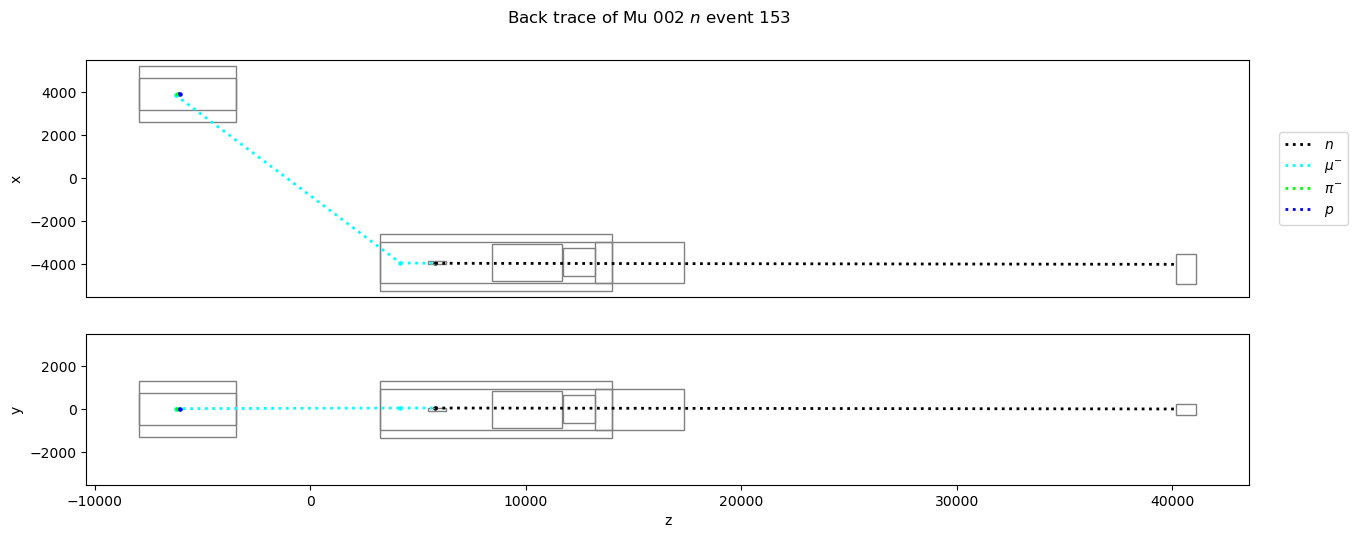

------------------------------------------------------------------------------


level_0                        1567
tag                              Mu
fileno                            2
index                           193
time                 3302395.490768
virtualdetectorId               101
creationCode                    115
pdgId                          2112
x                      -3863.441589
y                          62.46468
z                          40185.38
startx                 -3917.423933
starty                    48.031491
startz                  5648.825981
starttime               3320.542236
E                          0.000026
weight                     1.005488
Name: 1520, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,8604,Mu,2,193,214.225159,235.501831,56,13,-3854.029443,26.193399,4179.000000,4.123969e+03
1,8605,Mu,2,193,5.875719,214.470871,14,13,3918.737628,-4.403154,-5583.401281,6.736224e+03
2,8606,Mu,2,193,-7.186237,5.875719,101,-211,3917.272976,-1.024628,-6109.954373,3.234760e+04
3,8607,Mu,2,193,-7.366913,-7.186237,56,2212,3930.370530,-0.989947,-6057.707412,8.000000e+06


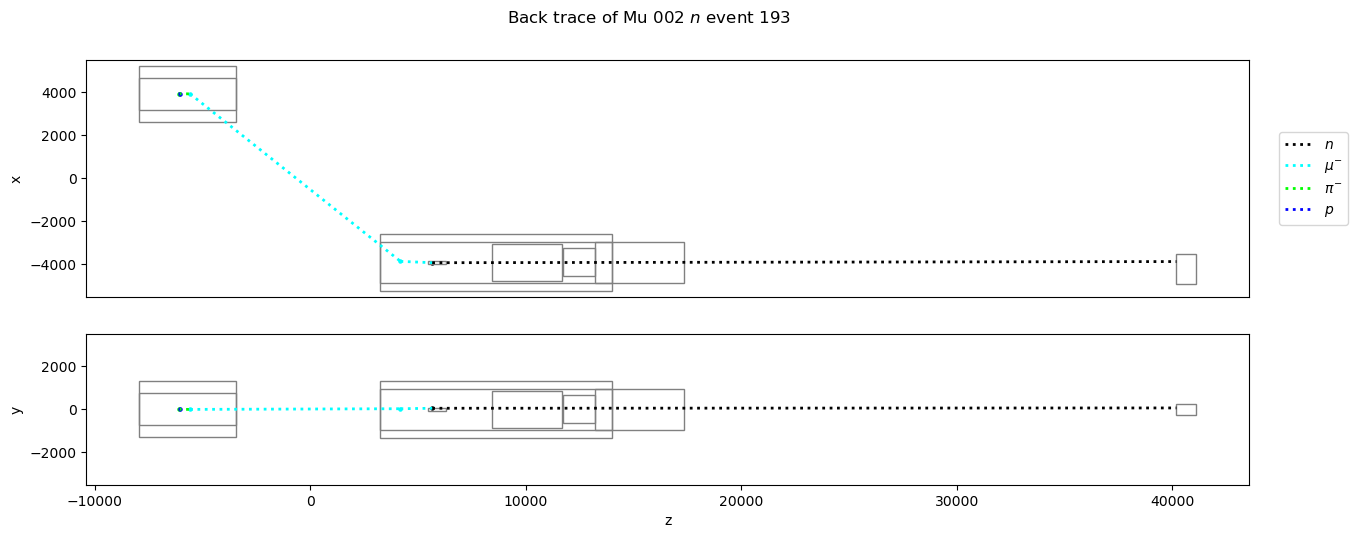

------------------------------------------------------------------------------


level_0                     1607
tag                           Mu
fileno                         2
index                        233
time                 2432.576883
virtualdetectorId            101
creationCode                 115
pdgId                       2112
x                   -3856.682064
y                      -9.381953
z                       40185.38
startx              -3943.912042
starty                 54.675394
startz               6137.659267
starttime              486.51651
E                     2235.81311
weight                  1.005488
Name: 1560, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,8810,Mu,2,233,207.319748,226.871658,56,13,-3941.486906,53.265299,4179.000000,8.214937e+03
1,8811,Mu,2,233,96.994507,207.498642,14,13,3876.523366,39.415604,-3109.630926,9.088942e+03
2,8812,Mu,2,233,50.490528,96.994507,14,-211,3893.788819,0.546480,-6158.815221,3.488640e+04
3,8813,Mu,2,233,50.358765,50.490528,101,3112,3907.363106,-0.216499,-6148.704483,1.369724e+05
4,8814,Mu,2,233,50.043919,50.358765,56,2212,3929.851079,-0.207440,-6057.577899,8.000000e+06


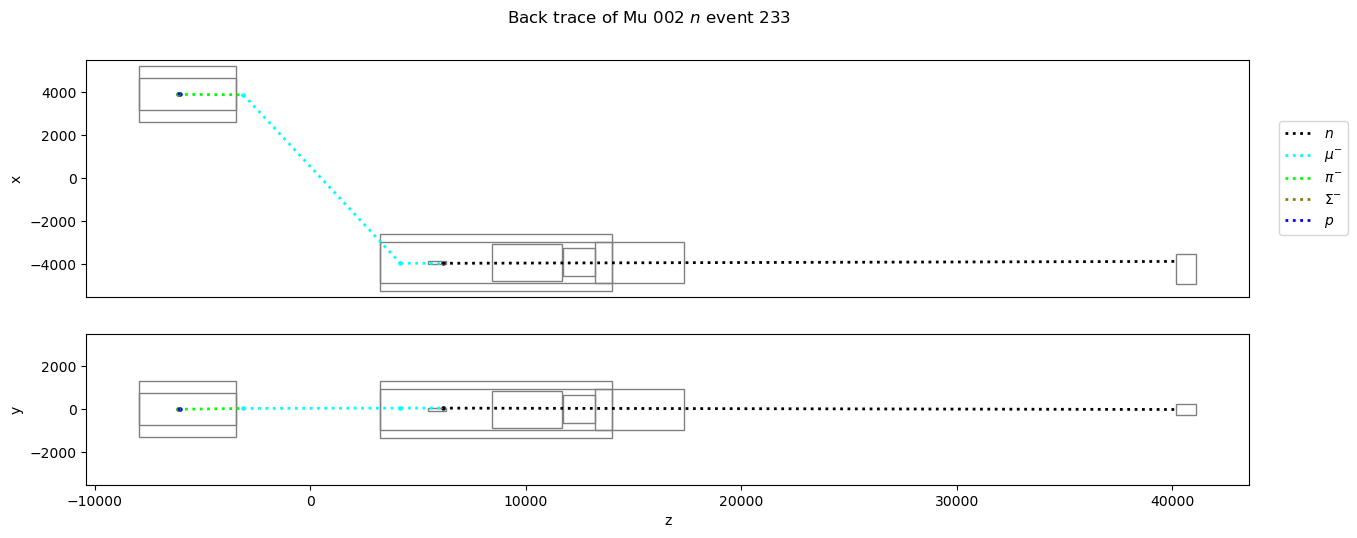

------------------------------------------------------------------------------


level_0                      1647
tag                            Mu
fileno                          2
index                         273
time                   6791.09242
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3969.660023
y                      -71.604512
z                        40185.38
startx               -4264.499458
starty                -252.324458
startz               16815.194378
starttime             1764.802734
E                      118.822558
weight                   1.005488
Name: 1600, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,9033,Mu,2,273,1759.256104,1764.802734,115,2112,-4142.850962,-212.820145,16921.127598,6.093483e+03
1,9034,Mu,2,273,125.334816,217.865219,56,13,-3902.903045,23.524779,4179.000000,1.680871e+04
2,9035,Mu,2,273,26.937550,125.466751,14,13,3845.079646,-31.886321,-3569.296602,1.731705e+04
3,9036,Mu,2,273,10.896235,26.937550,101,-211,3881.988858,2.378099,-6246.686124,4.299716e+04
4,9037,Mu,2,273,10.241792,10.896235,56,2212,3929.808925,1.674318,-6057.567389,8.000000e+06


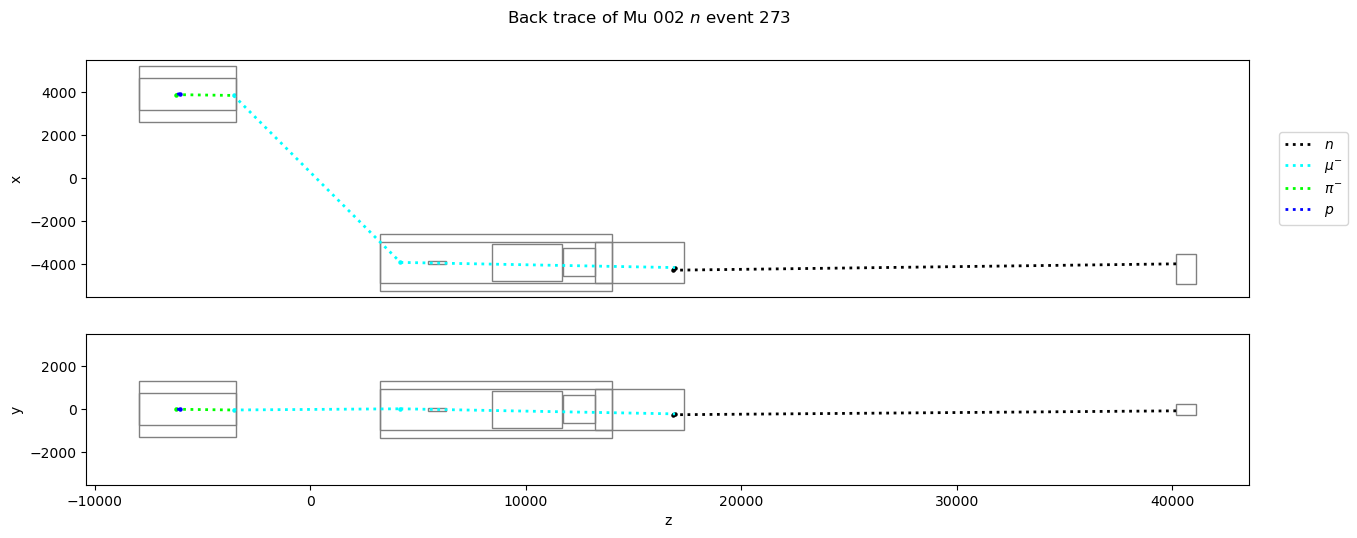

------------------------------------------------------------------------------


level_0                      1687
tag                            Mu
fileno                          2
index                         313
time                  2978.058867
virtualdetectorId             101
creationCode                  115
pdgId                        2112
x                    -3922.430213
y                      -20.027051
z                        40185.38
startx               -4241.686524
starty                 -79.975908
startz               15416.780801
starttime              773.992126
E                      425.155635
weight                   1.005488
Name: 1640, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,9245,Mu,2,313,153.665375,251.327728,56,13,-3865.364353,-97.887090,4179.000000,1.644269e+04
1,9246,Mu,2,313,7.429923,153.798477,14,13,3858.129247,-67.099044,-5394.550070,1.767115e+04
2,9247,Mu,2,313,-1.680539,7.429923,101,-211,3903.778430,0.490850,-6159.915651,3.564593e+04
3,9248,Mu,2,313,-2.034799,-1.680539,56,2212,3929.570516,0.054250,-6057.507947,8.000000e+06


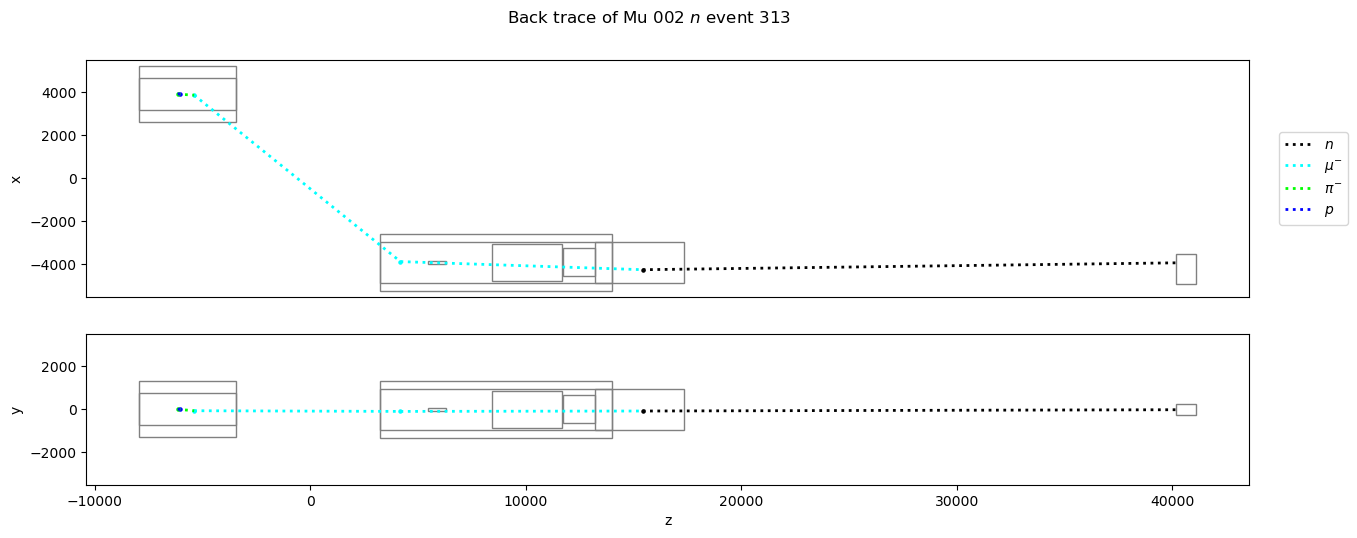

------------------------------------------------------------------------------


level_0                      1727
tag                            Mu
fileno                          2
index                         353
time                 17369.184929
virtualdetectorId             101
creationCode                  115
pdgId                        2112
x                    -3941.798576
y                       62.223627
z                        40185.38
startx                -3856.72501
starty                    9.07232
startz                5915.463277
starttime              241.950958
E                       11.102334
weight                   1.005488
Name: 1680, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,9461,Mu,2,353,187.333374,207.526718,56,13,-3868.633513,-48.094579,4179.000000,7.469926e+03
1,9462,Mu,2,353,16.132765,187.520065,14,13,3929.738335,27.793547,-4892.960492,9.103555e+03
2,9463,Mu,2,353,-12.656995,16.132765,14,-211,3838.916640,-80.234477,-6239.176862,4.103387e+04
3,9464,Mu,2,353,-13.831586,-12.656995,101,3122,3894.790288,-2.086056,-6193.254519,5.479465e+04
4,9465,Mu,2,353,-14.301746,-13.831586,56,2212,3929.738462,0.143569,-6057.549820,8.000000e+06


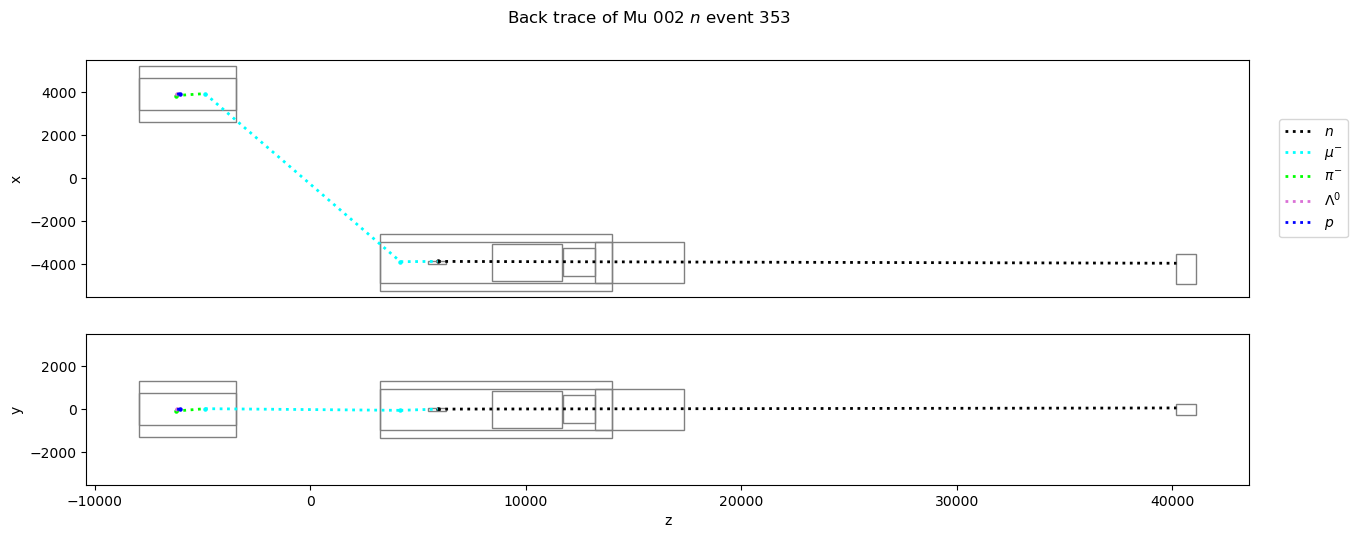

------------------------------------------------------------------------------


level_0                     1767
tag                           Mu
fileno                         2
index                        393
time                 2876.692389
virtualdetectorId            101
creationCode                  97
pdgId                       2112
x                   -3925.736442
y                     -86.641072
z                       40185.38
startx              -4246.130712
starty              -1608.790449
startz               15329.46484
starttime             706.045105
E                      770.07513
weight                  1.005488
Name: 1720, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,9675,Mu,2,393,524.209045,706.045105,115,2112,-3603.391021,-177.099693,15180.334017,2.268714e+03
1,9676,Mu,2,393,138.818588,206.006409,56,13,-3819.309381,-36.900639,4179.000000,2.172615e+04
2,9677,Mu,2,393,53.244453,138.938019,14,13,4008.280088,-10.803886,-4430.001378,2.238580e+04
3,9678,Mu,2,393,44.496479,53.244453,101,-211,3913.046868,-0.209890,-6127.564603,7.124756e+04
4,9679,Mu,2,393,44.255047,44.496479,56,2212,3930.148460,-0.274991,-6057.652044,8.000000e+06


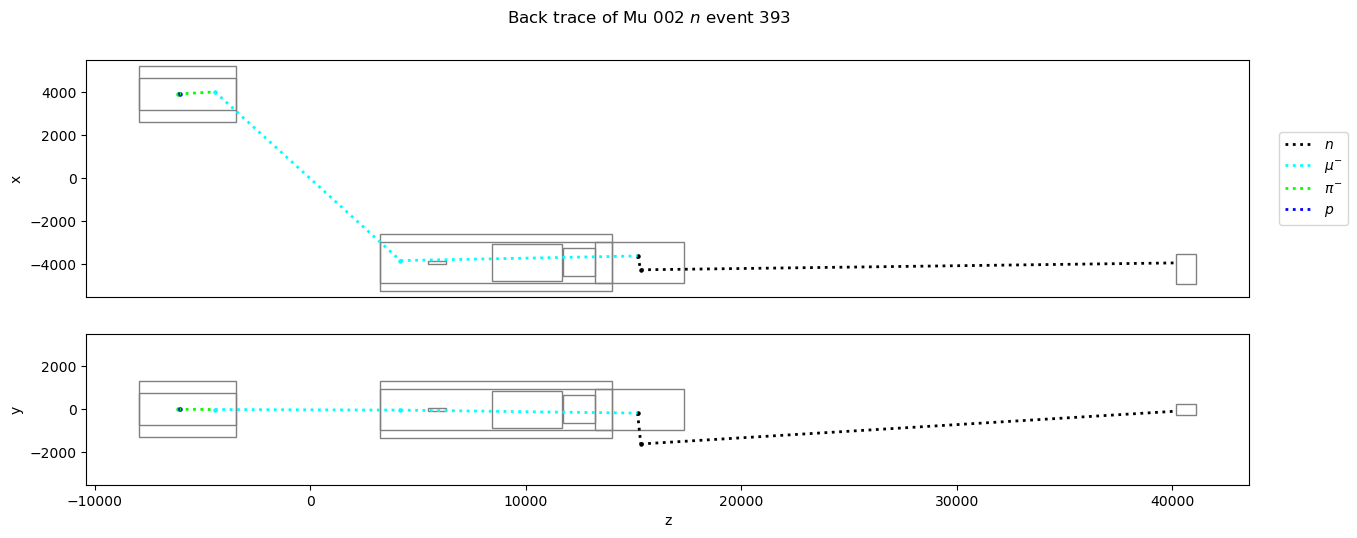

------------------------------------------------------------------------------


level_0                      1807
tag                            Mu
fileno                          2
index                         433
time                 65378.561708
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3921.978413
y                       -93.19162
z                        40185.38
startx               -4982.237512
starty               -1936.327711
startz                6007.541351
starttime             3047.189209
E                        1.581627
weight                   1.005488
Name: 1760, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,9876,Mu,2,433,3016.933838,3047.189209,97,2112,-4926.338171,-2269.718295,6270.009779,1.047649e+03
1,9877,Mu,2,433,2968.655762,3016.933838,115,2112,-3975.242763,18.785287,5782.078846,1.466318e+04
2,9878,Mu,2,433,241.703552,265.499603,56,13,-3960.016551,-11.235840,4179.000000,4.313791e+03
3,9879,Mu,2,433,24.637909,241.944107,14,13,3874.569176,10.092795,-6126.466833,6.586963e+03
4,9880,Mu,2,433,22.068264,24.637909,101,-211,3875.896413,3.250171,-6269.645427,3.161493e+04
5,9881,Mu,2,433,21.333958,22.068264,56,2212,3929.854916,-0.614371,-6057.578855,8.000000e+06


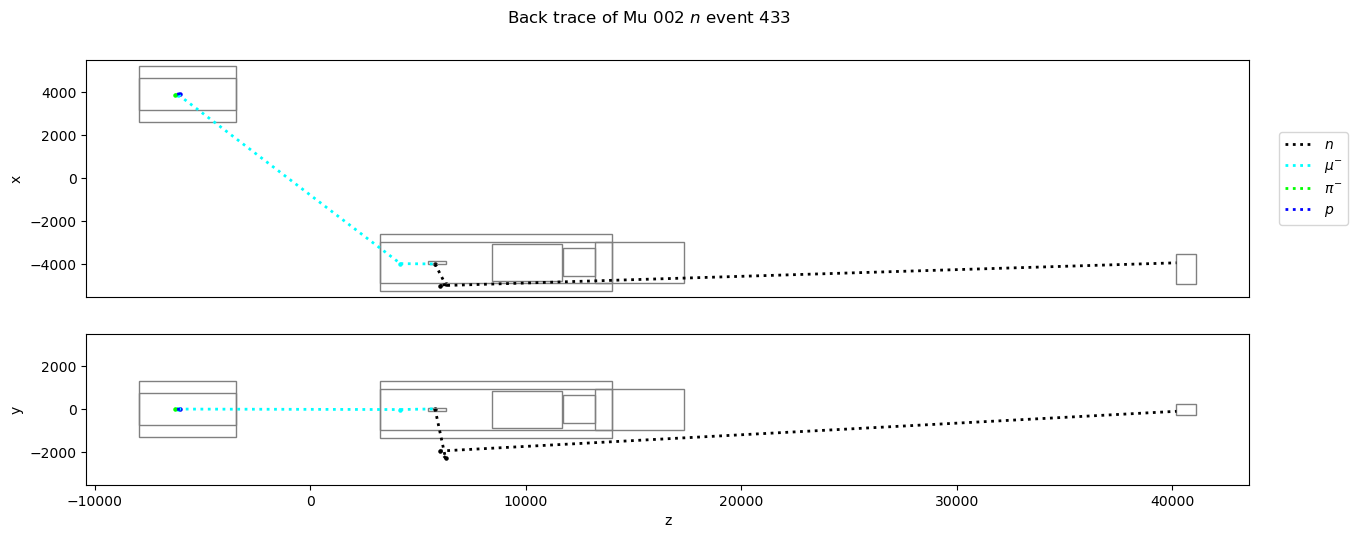

------------------------------------------------------------------------------


level_0                     1847
tag                           Mu
fileno                         2
index                        473
time                  7815.44982
virtualdetectorId            101
creationCode                  97
pdgId                       2112
x                   -3922.187631
y                     -74.791571
z                       40185.38
startx              -4818.139927
starty               -579.809973
startz               6749.766889
starttime            1402.095703
E                     171.409514
weight                  1.005488
Name: 1800, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,10090,Mu,2,473,1318.009766,1402.095703,115,2112,-3867.062009,2.759000,6071.003023,1.612463e+03
1,10091,Mu,2,473,106.290863,126.205215,56,13,-3888.328074,-19.165965,4179.000000,8.810245e+03
2,10092,Mu,2,473,-38.782253,106.464272,14,13,3886.061833,15.539185,-5659.850051,1.008164e+04
3,10093,Mu,2,473,-53.625538,-38.782253,101,-211,3907.604584,-0.450271,-6147.414888,2.546531e+04
4,10094,Mu,2,473,-53.936012,-53.625538,56,2212,3929.020910,-0.315579,-6057.370914,8.000000e+06


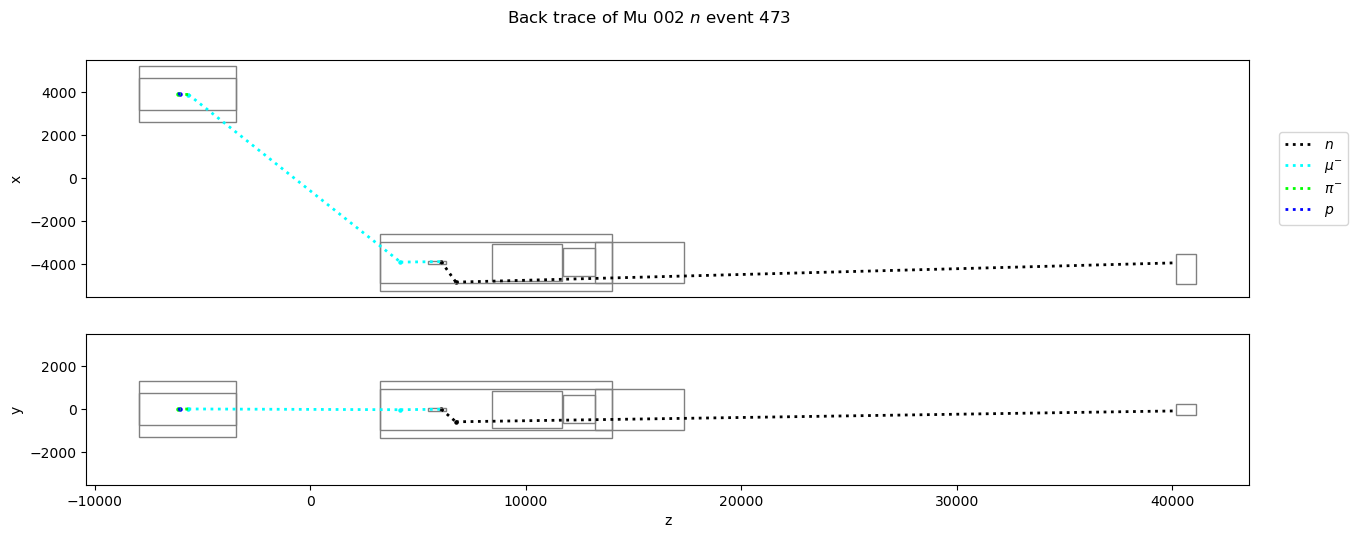

------------------------------------------------------------------------------


level_0                     1887
tag                           Mu
fileno                         2
index                        513
time                 6281.942226
virtualdetectorId            101
creationCode                  97
pdgId                       2112
x                   -3823.791664
y                      34.864796
z                        40185.4
startx              -3814.489797
starty              -1072.950919
startz                4550.52198
starttime             505.926392
E                     277.032541
weight                  1.005488
Name: 1840, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,10298,Mu,2,513,425.263947,505.926392,97,2112,-4947.549131,-361.979278,4559.293955,1.623015e+03
1,10299,Mu,2,513,355.480408,425.263947,115,2112,-3878.163378,-42.380785,5959.849090,7.228616e+03
2,10300,Mu,2,513,317.453217,345.861694,56,13,-3871.949236,-20.150945,4179.000000,5.057482e+03
3,10301,Mu,2,513,49.007454,317.676483,14,13,3905.463663,-57.390283,-5721.752002,7.062699e+03
4,10302,Mu,2,513,35.472584,49.007454,14,-211,3908.279222,-30.901022,-6133.603356,2.260505e+04
5,10303,Mu,2,513,35.184902,35.472584,101,3122,3922.286653,0.483039,-6091.579510,3.201423e+05
6,10304,Mu,2,513,35.068100,35.184902,56,2212,3930.742803,0.331369,-6057.800231,8.000000e+06


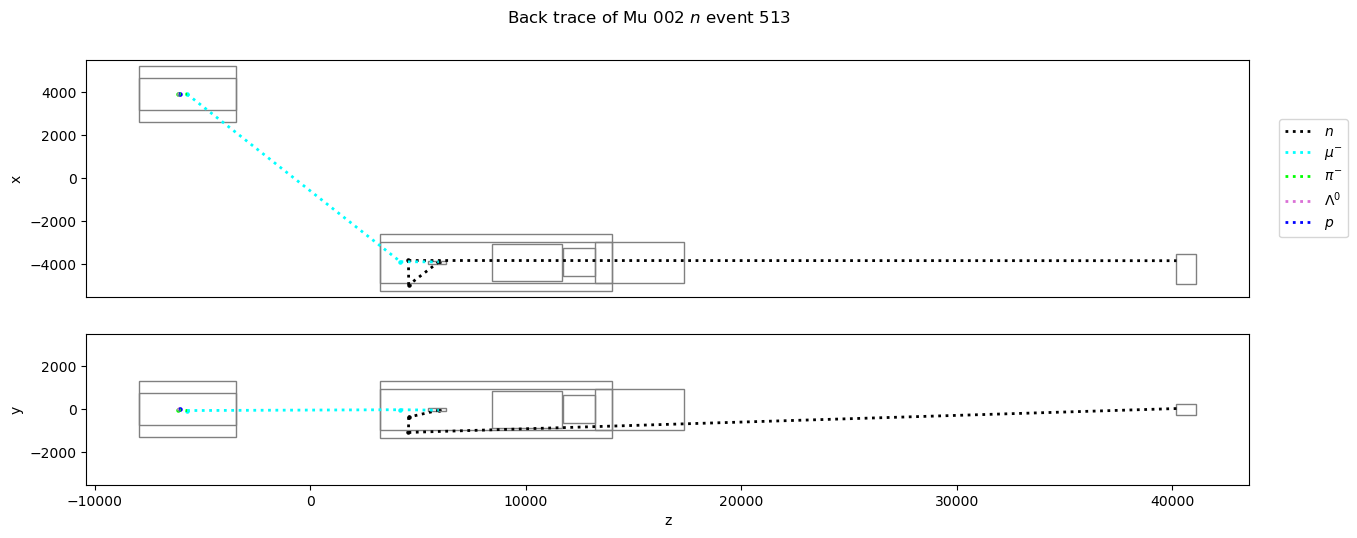

------------------------------------------------------------------------------


level_0                     1927
tag                           Mu
fileno                         2
index                        553
time                 2321.259498
virtualdetectorId            101
creationCode                  97
pdgId                       2112
x                   -3973.497262
y                      -43.15297
z                       40185.38
startx              -4464.005208
starty                789.665418
startz               5370.307209
starttime             275.799042
E                      1310.8255
weight                  1.005488
Name: 1880, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,10515,Mu,2,553,245.317719,275.799042,115,2112,-3868.232119,38.250365,5826.523834,6.425839e+03
1,10516,Mu,2,553,178.796692,198.320847,56,13,-3848.857328,-3.486568,4179.000000,6.544238e+03
2,10517,Mu,2,553,19.928560,178.994934,14,13,3948.179162,28.223788,-4638.284471,8.075915e+03
3,10518,Mu,2,553,8.679141,19.928560,101,-211,3905.088868,-1.261517,-6151.050615,2.649728e+04
4,10519,Mu,2,553,8.503990,8.679141,101,2212,3919.822616,0.817856,-6101.012424,7.814954e+06
5,10520,Mu,2,553,8.354487,8.503990,56,2212,3930.534362,0.910598,-6057.748260,8.000000e+06


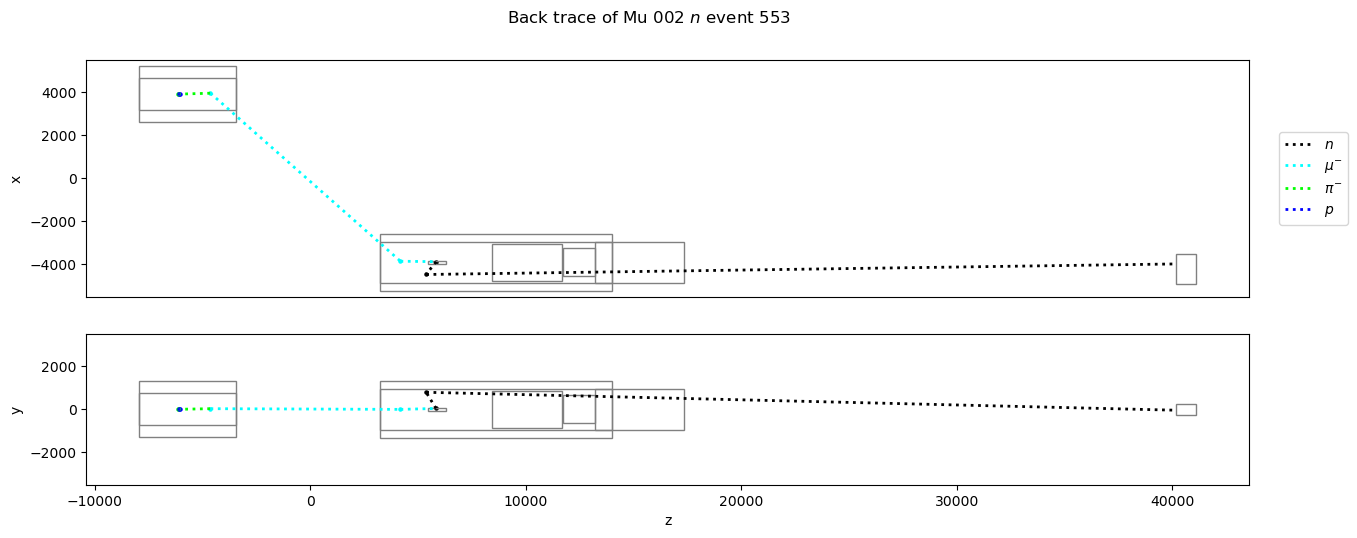

------------------------------------------------------------------------------


level_0                      1967
tag                            Mu
fileno                          2
index                         593
time                 10855.656782
virtualdetectorId             101
creationCode                  115
pdgId                        2112
x                    -3923.860748
y                       34.153852
z                        40185.38
startx               -3857.365882
starty                  42.081271
startz                 5670.96298
starttime             1119.033813
E                       68.553547
weight                   1.005488
Name: 1920, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,10728,Mu,2,593,398.038361,426.786377,56,13,-3807.627501,62.020643,4179.000000,3.622482e+03
1,10729,Mu,2,593,76.629326,398.299622,14,13,3927.536427,4.638756,-5840.237615,6.409223e+03
2,10730,Mu,2,593,71.836693,76.629326,101,-211,3929.386888,2.256111,-6059.407244,3.065702e+04
3,10731,Mu,2,593,71.830360,71.836693,56,2212,3929.843323,2.258137,-6057.575965,8.000000e+06


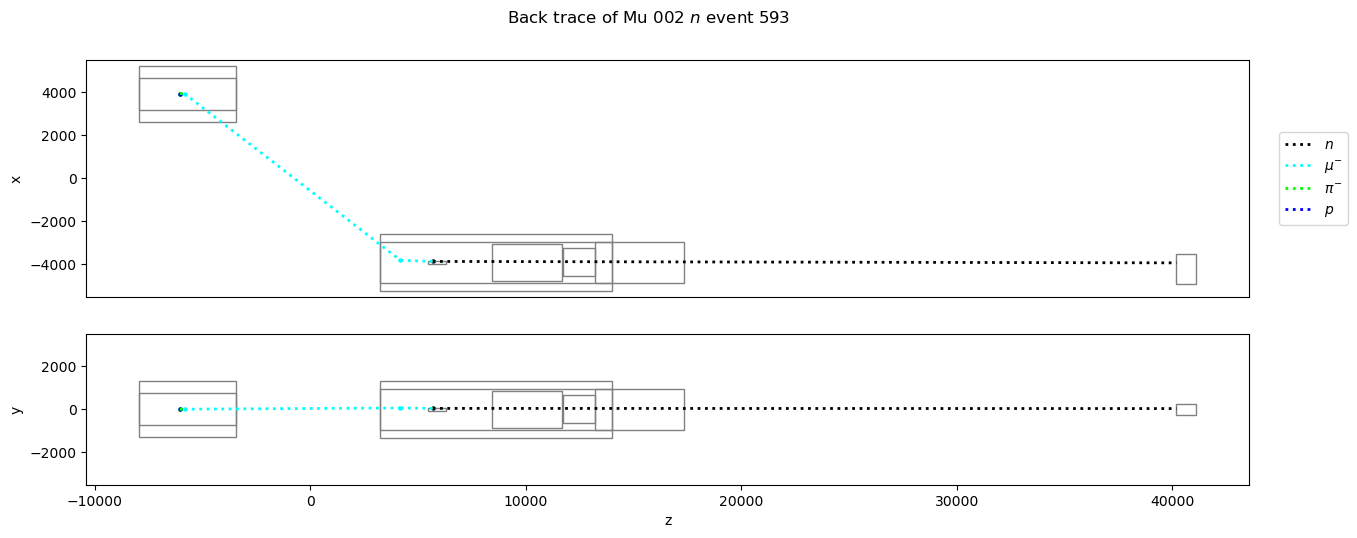

------------------------------------------------------------------------------


level_0                        2007
tag                              Mu
fileno                            2
index                           633
time                 8466271.218017
virtualdetectorId               101
creationCode                    115
pdgId                          2112
x                      -3873.192035
y                         31.322157
z                          40185.38
startx                 -4018.454678
starty                  -329.631858
startz                 16129.408743
starttime               4216.333008
E                          0.000074
weight                     1.005488
Name: 1960, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,10929,Mu,2,633,139.623917,233.345215,56,13,-3851.470224,28.311947,4179.000000,1.597750e+04
1,10930,Mu,2,633,35.530014,139.758575,14,13,3913.418863,5.512132,-4803.548572,1.692669e+04
2,10931,Mu,2,633,15.738195,35.530014,101,-211,3897.496082,-0.009988,-6194.954476,4.197190e+04
3,10932,Mu,2,633,15.264733,15.738195,56,2212,3931.214807,-1.781231,-6057.917914,8.000000e+06


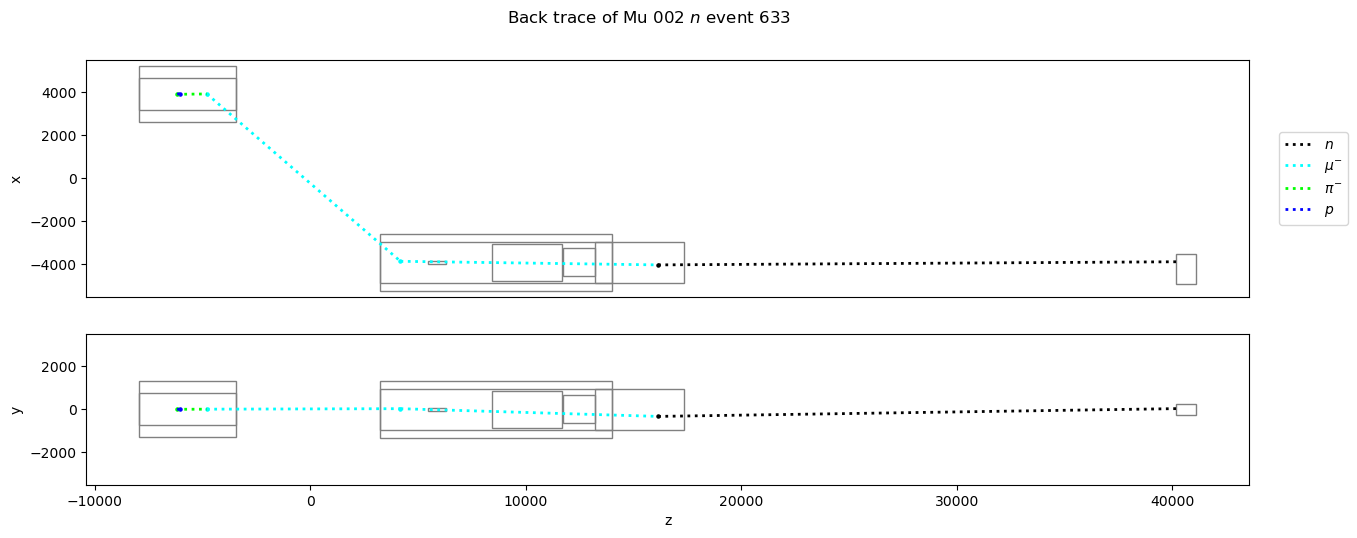

------------------------------------------------------------------------------


level_0                         2047
tag                               Mu
fileno                             3
index                             30
time                 54743928.432745
virtualdetectorId                101
creationCode                      97
pdgId                           2112
x                       -3894.016627
y                          98.909388
z                           40185.38
startx                  -4749.587079
starty                  -2264.308143
startz                   5621.839792
starttime                2211.216553
E                           0.000086
weight                      1.005488
Name: 2000, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,11140,Mu,3,30,2173.744629,2211.216553,115,2112,-3930.051592,48.278178,5826.573342,3.596642e+04
1,11141,Mu,3,30,246.986649,267.363373,56,13,-3874.535609,-1.103604,4179.000000,6.868855e+03
2,11142,Mu,3,30,69.679123,247.180557,14,13,3902.425632,47.313255,-4998.334938,8.709209e+03
3,11143,Mu,3,30,58.854202,69.679123,101,-211,3901.173403,1.738866,-6168.478188,5.882947e+04
4,11144,Mu,3,30,58.469944,58.854202,56,2212,3929.351231,0.787717,-6057.453272,8.000000e+06


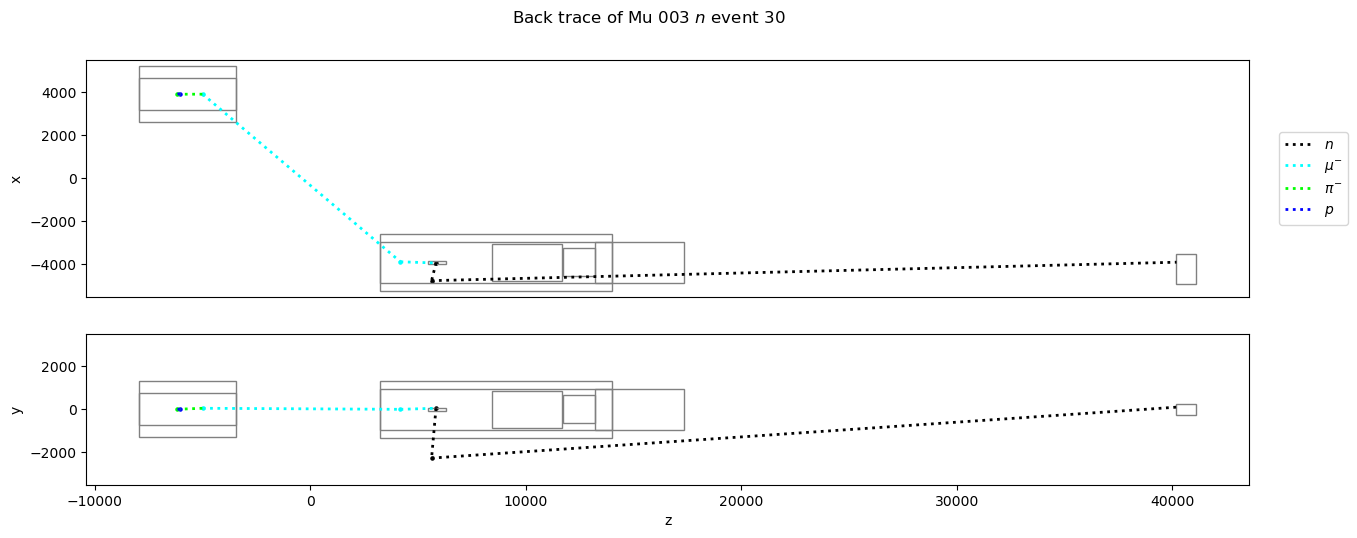

------------------------------------------------------------------------------


level_0                        2087
tag                              Mu
fileno                            3
index                            70
time                 4917154.606071
virtualdetectorId               101
creationCode                     97
pdgId                          2112
x                      -3854.330649
y                          2.905108
z                          40185.38
startx                 -5043.145622
starty                  -640.341434
startz                 11470.649562
starttime                1828.29541
E                          0.000091
weight                     1.005488
Name: 2040, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,11345,Mu,3,70,1814.168579,1828.295410,97,2112,-4569.679634,-220.069144,11669.002511,1.174467e+04
1,11346,Mu,3,70,1717.589478,1814.168579,115,2112,-3948.120781,40.077597,5693.222848,2.094604e+04
2,11347,Mu,3,70,319.627136,347.500031,56,13,-3991.867865,46.228321,4179.000000,3.401377e+03
3,11348,Mu,3,70,77.989319,319.896362,14,13,3858.232742,77.960129,-4159.308743,6.031878e+03
4,11349,Mu,3,70,52.140324,77.989319,101,-211,3907.572202,0.379793,-6146.498776,3.759111e+04
5,11350,Mu,3,70,51.832817,52.140324,56,2212,3929.416874,-0.028090,-6057.469639,8.000000e+06


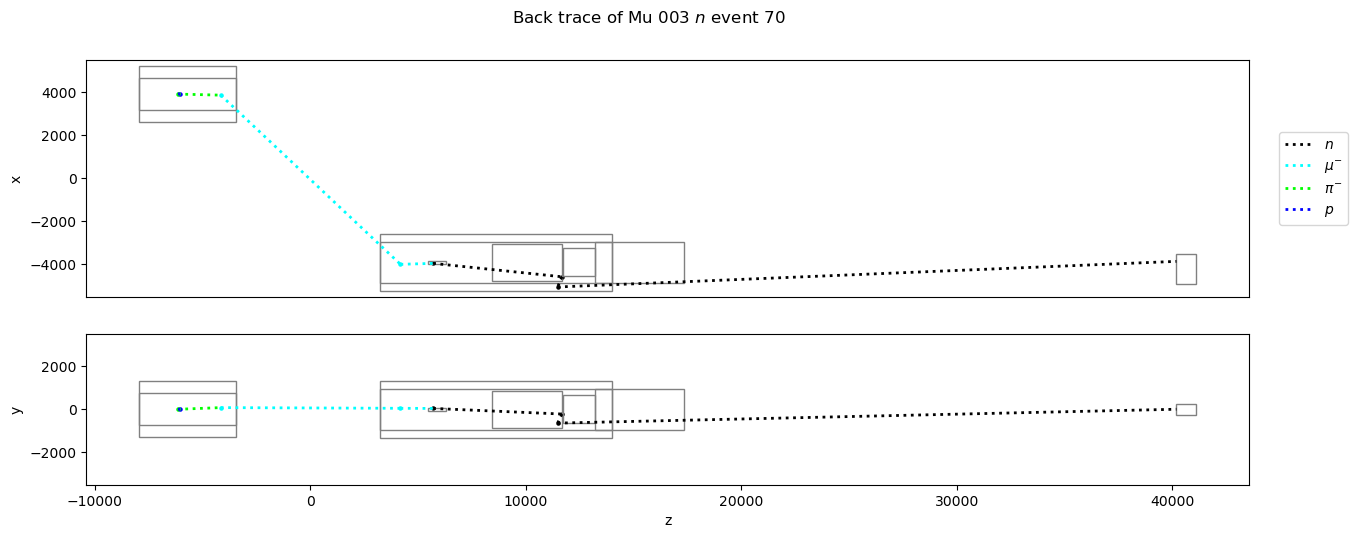

------------------------------------------------------------------------------


level_0                      2127
tag                            Mu
fileno                          3
index                         110
time                 22322.304477
virtualdetectorId             101
creationCode                  115
pdgId                        2112
x                    -3838.984558
y                       12.982973
z                        40185.38
startx               -3916.398992
starty                 -30.292729
startz                5626.573233
starttime              464.682465
E                        0.684039
weight                   1.005488
Name: 2080, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,11585,Mu,3,110,201.579163,220.260330,56,13,-3903.191429,-25.787422,4179.000000,4.773889e+03
1,11586,Mu,3,110,3.708434,201.808548,14,13,3879.220729,-29.644200,-6124.920478,6.206045e+03
2,11587,Mu,3,110,1.027104,3.708434,101,-211,3884.709605,-2.112228,-6247.175509,2.207541e+04
3,11588,Mu,3,110,0.373276,1.027104,56,2212,3930.884557,-1.073701,-6057.835574,8.000000e+06


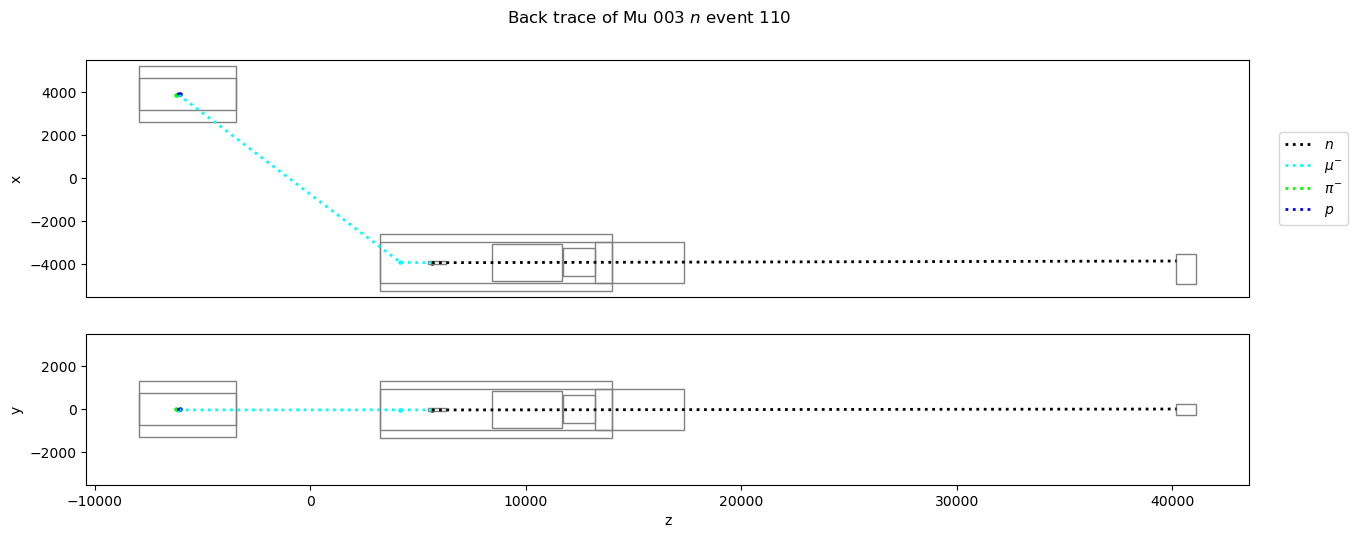

------------------------------------------------------------------------------


level_0                      2167
tag                            Mu
fileno                          3
index                         150
time                 79852.802387
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3954.842428
y                      -56.851543
z                        40185.38
startx               -3936.039738
starty                   0.000938
startz               17415.897883
starttime              965.394409
E                        0.000021
weight                   1.005488
Name: 2120, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,11819,Mu,3,150,965.336670,965.394409,115,2112,-3936.305144,-0.475732,17415.981106,4.776659e+02
1,11820,Mu,3,150,172.514755,259.241638,56,13,-3835.666433,-17.592395,4179.000000,2.101986e+04
2,11821,Mu,3,150,75.535629,172.635681,14,13,3909.273157,2.511330,-4573.358475,2.162367e+04
3,11822,Mu,3,150,61.621433,75.535629,101,-211,3896.465630,1.087129,-6193.943489,8.233136e+04
4,11823,Mu,3,150,61.150459,61.621433,56,2212,3930.553309,0.203449,-6057.752984,8.000000e+06


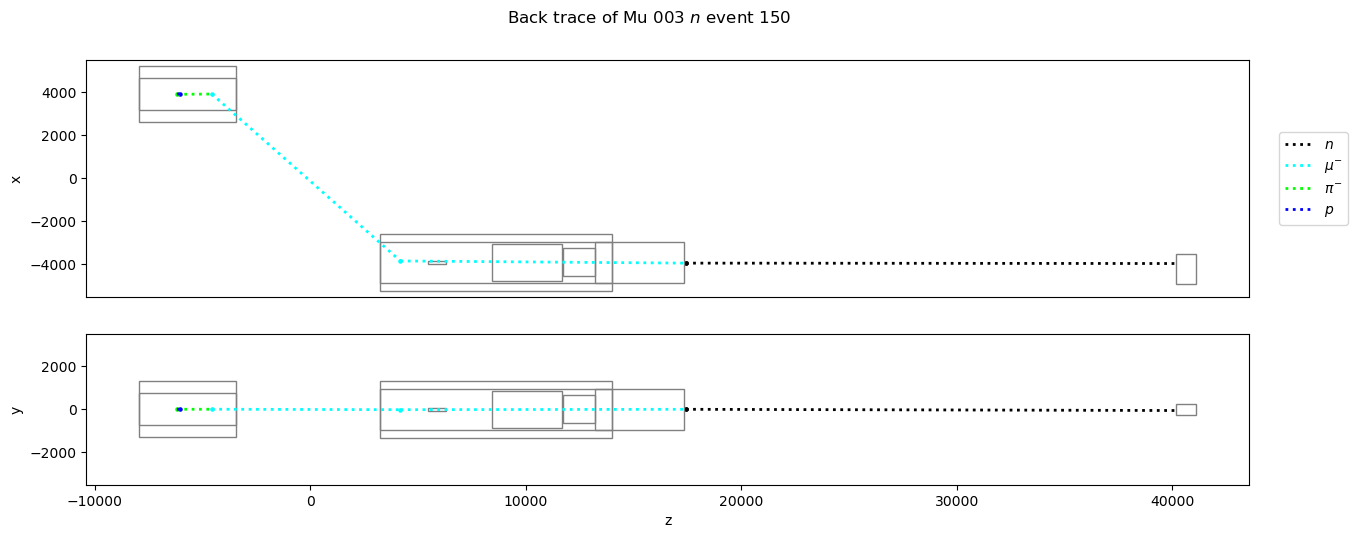

------------------------------------------------------------------------------


level_0                        2207
tag                              Mu
fileno                            3
index                           190
time                 2318734.531981
virtualdetectorId               101
creationCode                    115
pdgId                          2112
x                      -3828.103492
y                          4.918162
z                          40185.38
startx                 -3888.083829
starty                  -346.590972
startz                  15568.15551
starttime                 987.58313
E                          0.000037
weight                     1.005488
Name: 2160, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,12045,Mu,3,190,135.441711,213.388931,56,13,-3880.582360,-65.736113,4179.000000,1.573982e+04
1,12046,Mu,3,190,36.460060,135.577179,14,13,3907.130852,-64.667006,-4994.943890,1.640790e+04
2,12047,Mu,3,190,24.347225,36.460060,101,-211,3895.206133,-0.985719,-6188.930664,2.115628e+04
3,12048,Mu,3,190,24.241371,24.347225,101,2212,3905.016146,-0.335976,-6158.955460,7.728852e+06
4,12049,Mu,3,190,23.891251,24.241371,56,2212,3930.406959,-0.427255,-6057.716495,8.000000e+06


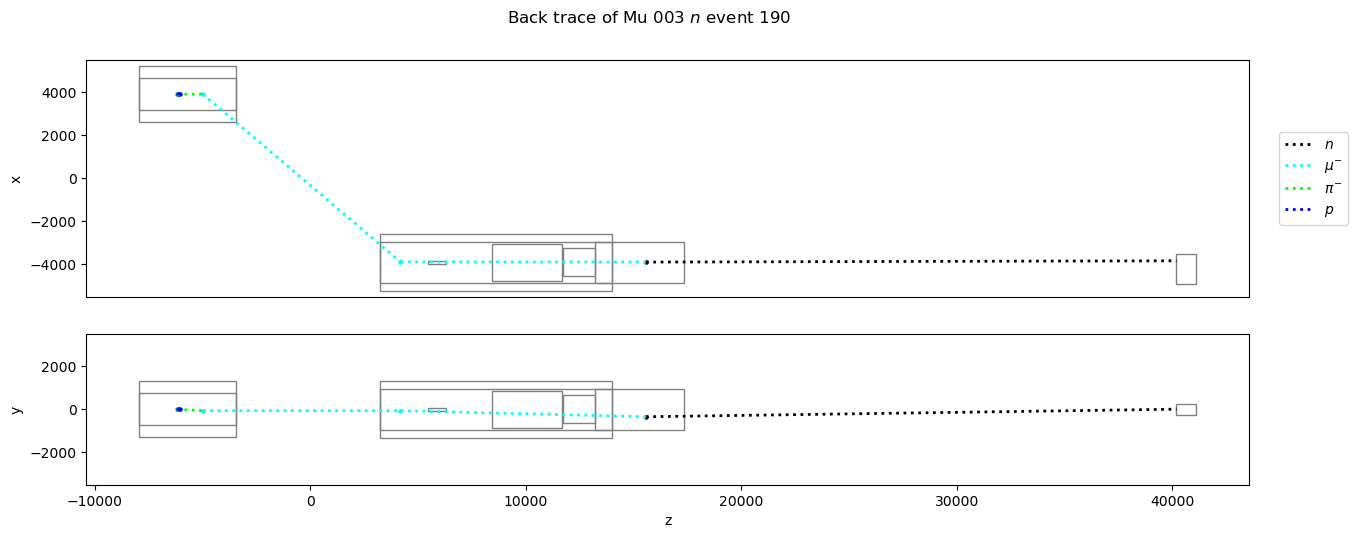

------------------------------------------------------------------------------


level_0                      2247
tag                            Mu
fileno                          3
index                         230
time                 233763.15029
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3868.350489
y                      -48.061085
z                         40185.4
startx               -3819.543439
starty                 154.403111
startz               17340.099831
starttime             2372.651611
E                        0.051022
weight                   1.005488
Name: 2200, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,12251,Mu,3,230,2372.273193,2372.651611,97,2112,-3816.887276,151.034976,17355.868588,1.001972e+04
1,12252,Mu,3,230,2368.130859,2372.273193,115,2112,-3795.544852,169.314147,17163.181884,2.003142e+04
2,12253,Mu,3,230,115.897369,221.590500,56,13,-3893.487117,23.448949,4179.000000,1.388585e+04
3,12254,Mu,3,230,2.322141,116.039986,14,13,3933.076344,2.753660,-6160.034565,1.485769e+04
4,12255,Mu,3,230,1.894750,2.322141,101,-211,3888.670344,1.695774,-6228.535181,9.515675e+04
5,12256,Mu,3,230,1.304817,1.894750,56,2212,3930.516939,0.611510,-6057.743916,8.000000e+06


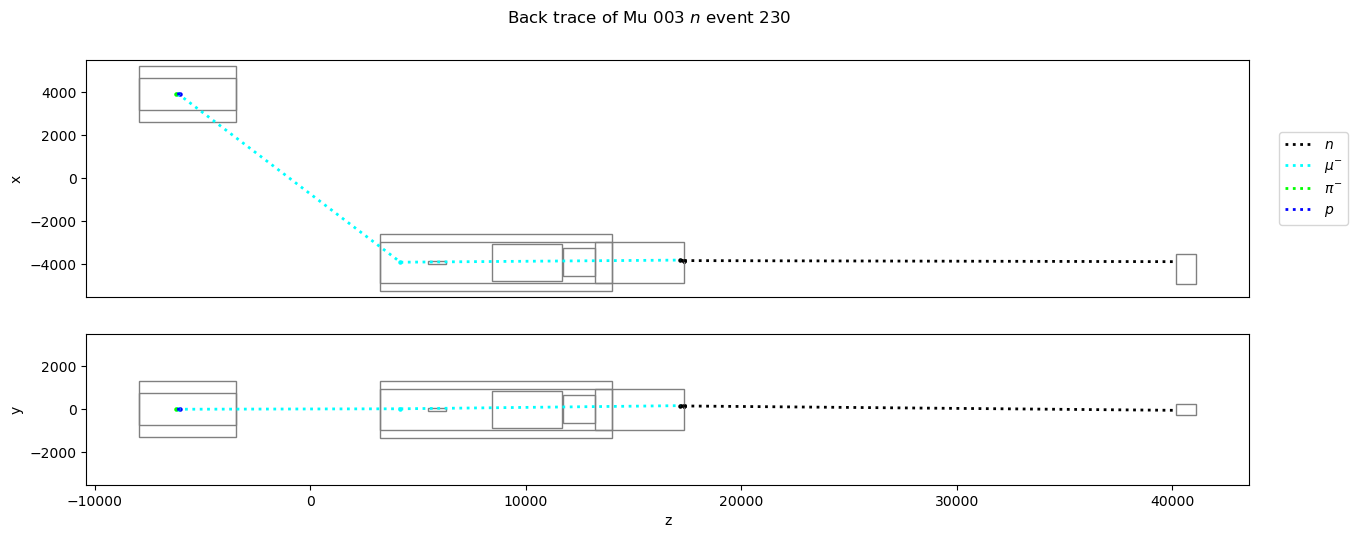

------------------------------------------------------------------------------


level_0                      2287
tag                            Mu
fileno                          3
index                         270
time                 12344.767006
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3828.793236
y                      -40.884664
z                        40185.38
startx               -3762.244928
starty                1042.441784
startz                6719.292021
starttime             4018.320068
E                       81.890959
weight                   1.005488
Name: 2240, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,12473,Mu,3,270,4017.407959,4018.320068,97,2112,-3799.394071,1016.925409,6681.188128,2.268011e+04
1,12474,Mu,3,270,3995.606689,4017.407959,115,2112,-3919.094535,-28.030974,5715.477922,2.552340e+04
2,12475,Mu,3,270,144.163696,160.979797,56,13,-3865.772620,28.114968,4179.000000,6.637017e+03
3,12476,Mu,3,270,-1.654635,144.360672,14,13,3922.725793,3.871176,-5794.314876,8.150513e+03
4,12477,Mu,3,270,-9.145692,-1.654635,101,-211,3903.468243,0.345467,-6161.216093,4.003953e+04
5,12478,Mu,3,270,-9.504440,-9.145692,56,2212,3929.190905,0.013946,-6057.413299,8.000000e+06


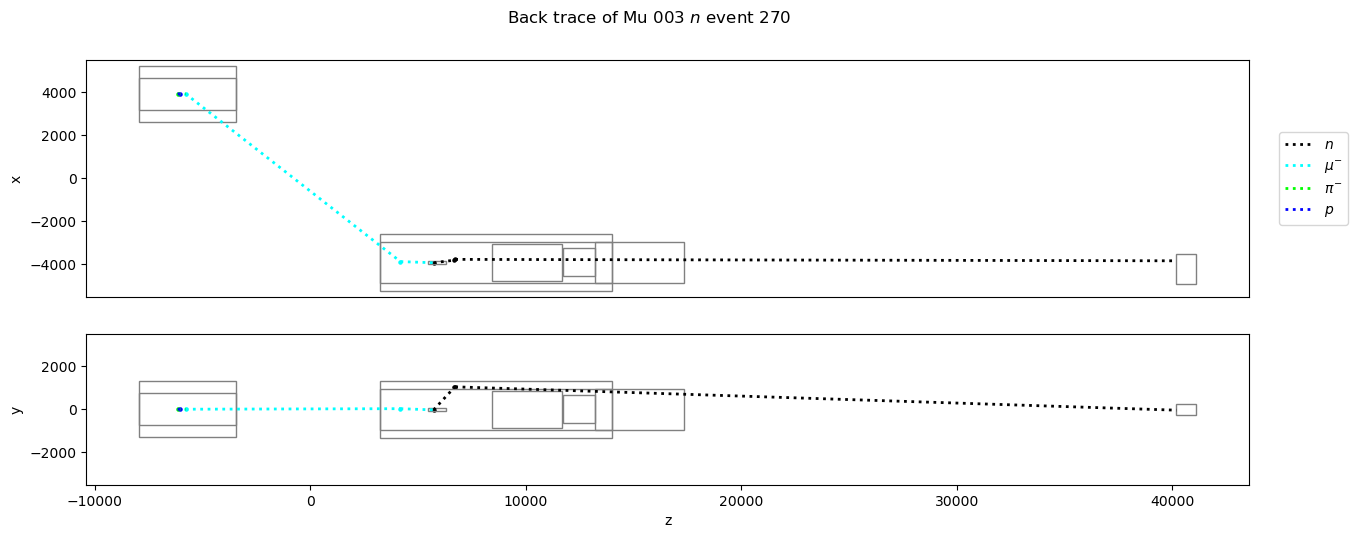

------------------------------------------------------------------------------


level_0                       2327
tag                             Mu
fileno                           3
index                          310
time                 9435422.35926
virtualdetectorId              101
creationCode                    97
pdgId                         2112
x                      -3884.59272
y                       -57.655329
z                         40185.38
startx                -3885.012577
starty                  624.525934
startz                 5554.326082
starttime               867.759338
E                         0.000045
weight                    1.005488
Name: 2280, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,12707,Mu,3,310,835.982300,867.759338,115,2112,-3957.577552,14.554443,5782.073818,2.229634e+03
1,12708,Mu,3,310,148.982574,168.553314,56,13,-3930.133622,59.888810,4179.000000,6.053520e+03
2,12709,Mu,3,310,-13.635638,149.188019,14,13,3908.013505,31.777434,-4827.394374,7.556177e+03
3,12710,Mu,3,310,-23.211267,-13.635638,14,-211,3910.586781,21.102389,-6139.712529,1.745420e+04
4,12711,Mu,3,310,-23.430967,-23.211267,101,3122,3911.380661,2.767848,-6132.246017,5.418232e+04
5,12712,Mu,3,310,-23.688993,-23.430967,56,2212,3930.161844,2.142792,-6057.655381,8.000000e+06


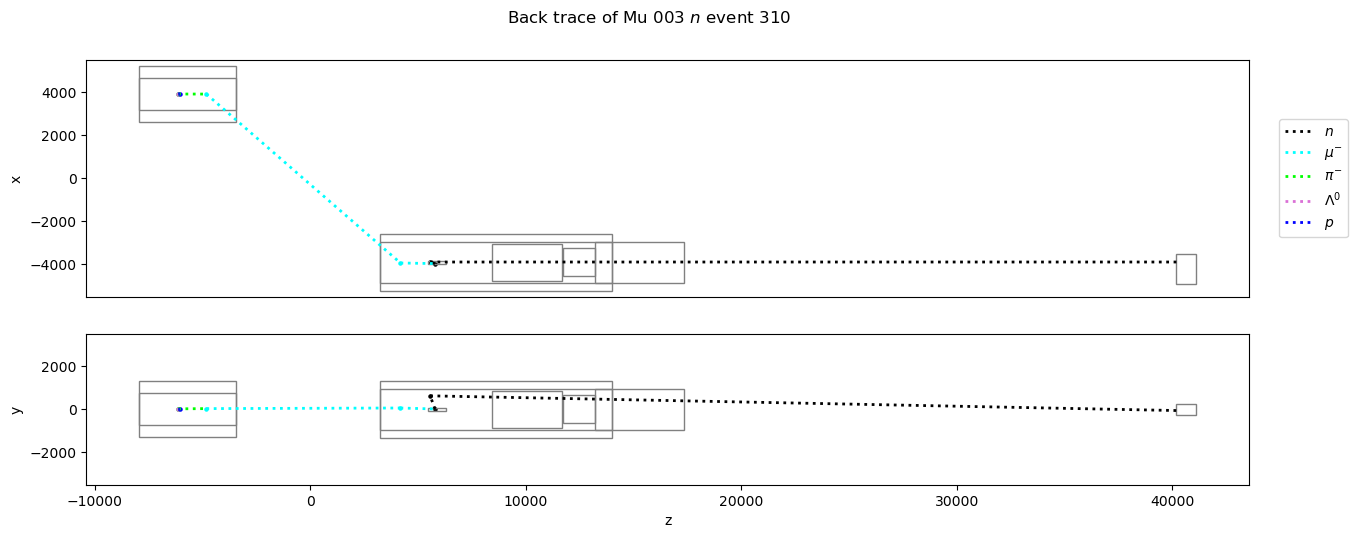

------------------------------------------------------------------------------


level_0                        2367
tag                              Mu
fileno                            3
index                           350
time                 1906727.516632
virtualdetectorId               101
creationCode                     97
pdgId                          2112
x                      -3848.919881
y                         66.712185
z                          40185.38
startx                 -5076.226817
starty                   589.178966
startz                  6945.574012
starttime                526.296387
E                          0.001586
weight                     1.005488
Name: 2320, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,12916,Mu,3,350,472.551239,526.296387,97,2112,-5171.316108,306.319546,6979.724048,1.739755e+03
1,12917,Mu,3,350,405.796997,472.551239,115,2112,-3845.557302,15.615695,6270.996221,5.057802e+03
2,12918,Mu,3,350,172.291412,197.215546,56,13,-3858.120234,29.946089,4179.000000,6.512406e+03
3,12919,Mu,3,350,-0.321324,172.490097,14,13,3941.383846,-2.928007,-6058.772234,8.087923e+03
4,12920,Mu,3,350,-0.888691,-0.321324,101,-211,3924.440767,-0.015182,-6084.523380,2.776562e+04
5,12921,Mu,3,350,-0.980779,-0.888691,56,2212,3931.067162,0.037575,-6057.881102,8.000000e+06


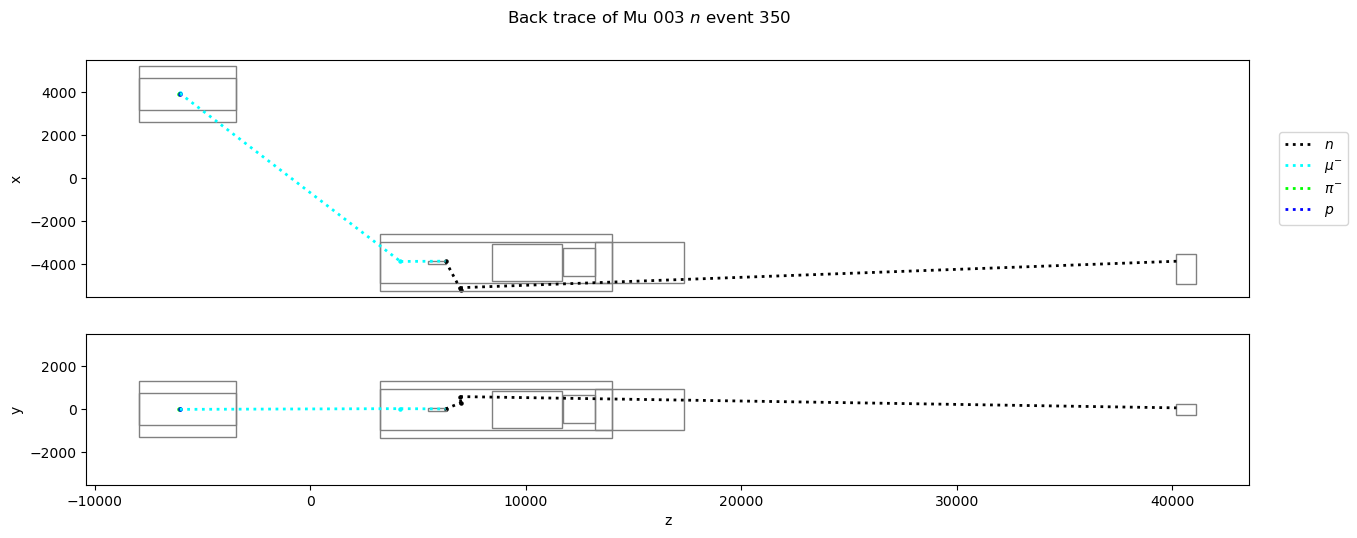

------------------------------------------------------------------------------


level_0                      2407
tag                            Mu
fileno                          3
index                         390
time                  2757.927295
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3869.775463
y                       66.209876
z                        40185.38
startx               -3650.596004
starty                -104.989029
startz               17352.076027
starttime              886.548401
E                      853.681931
weight                   1.005488
Name: 2360, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,13125,Mu,3,390,884.172363,886.548401,97,2112,-3636.521528,-118.908958,17359.004158,1.983135e+03
1,13126,Mu,3,390,835.266296,884.172363,115,2112,-4054.504612,-6.493829,18567.789113,3.628340e+03
2,13127,Mu,3,390,47.969196,136.452744,56,13,-3930.494588,-69.189574,4179.000000,2.730949e+04
3,13128,Mu,3,390,-24.395674,48.079082,14,13,3897.399415,-0.628637,-2976.724039,2.768747e+04
4,13129,Mu,3,390,-40.721447,-24.395674,101,-211,3902.570002,-1.250029,-6172.443119,6.470863e+04
5,13130,Mu,3,390,-41.117481,-40.721447,56,2212,3931.137927,-0.145177,-6057.898746,8.000000e+06


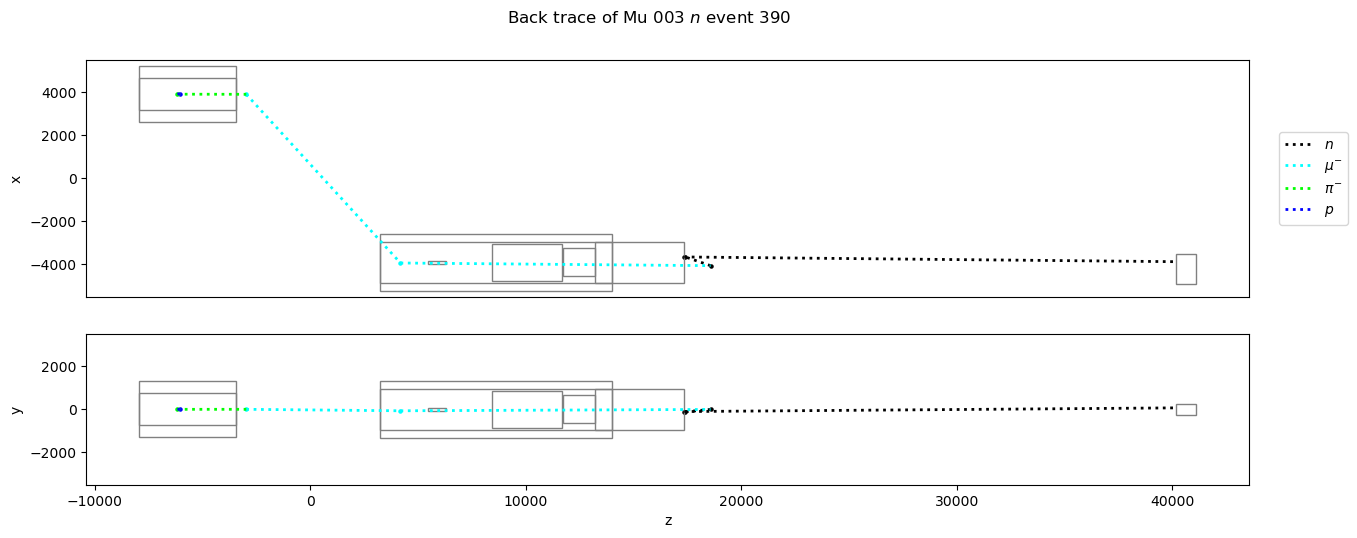

------------------------------------------------------------------------------


level_0                         2447
tag                               Mu
fileno                             3
index                            430
time                 10577150.779028
virtualdetectorId                101
creationCode                      97
pdgId                           2112
x                       -3849.450951
y                         -80.484416
z                           40185.38
startx                  -2835.637087
starty                   -176.810762
startz                   5678.943743
starttime                 334.871521
E                           0.000035
weight                      1.005488
Name: 2400, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,13336,Mu,3,430,326.405518,334.871521,97,2112,-2904.235066,-207.375024,5705.948412,2.018173e+03
1,13337,Mu,3,430,309.361267,326.405518,97,2112,-2987.180399,253.455364,5313.217652,6.969652e+03
2,13338,Mu,3,430,289.473145,309.361267,115,2112,-3937.591123,25.367956,5759.890566,1.564318e+04
3,13339,Mu,3,430,120.093880,141.275421,56,13,-3933.984425,-34.888538,4179.000000,5.944795e+03
4,13340,Mu,3,430,68.594910,120.301048,14,13,-2786.535243,52.946791,584.574722,5.944796e+03
5,13341,Mu,3,430,-17.241367,68.594910,100,-211,3897.571225,0.684347,-6186.972833,3.274503e+04
6,13342,Mu,3,430,-17.271727,-17.241367,101,-211,3899.427299,0.458589,-6179.148629,1.655769e+05
7,13343,Mu,3,430,-17.692131,-17.271727,56,2212,3929.224512,-0.197708,-6057.421678,8.000000e+06


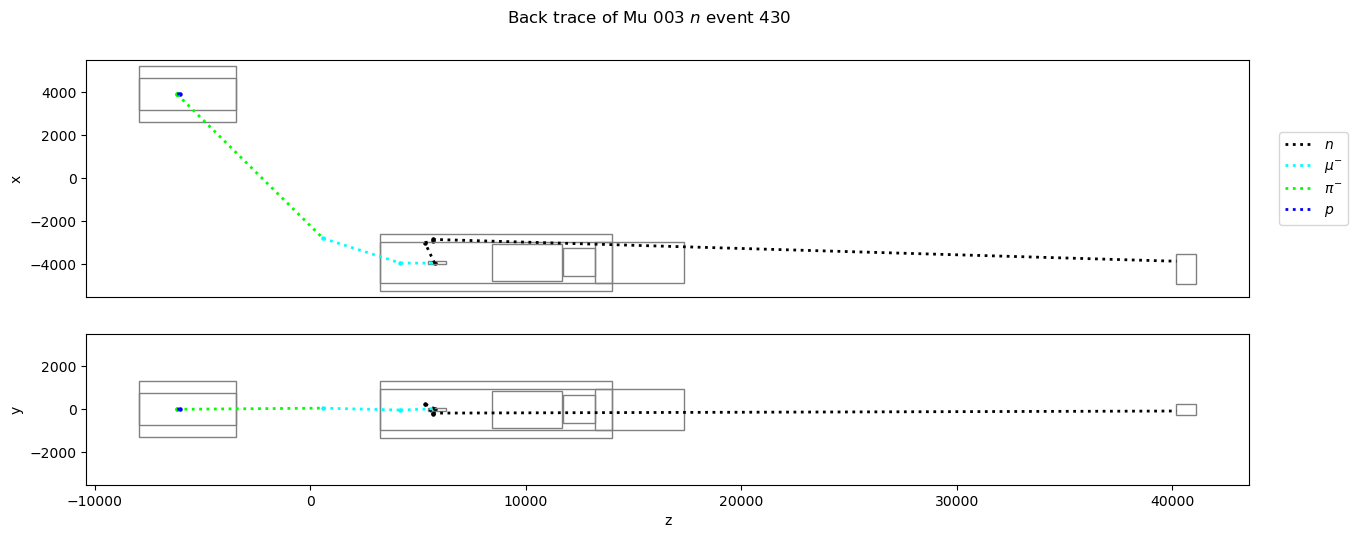

------------------------------------------------------------------------------


level_0                        2487
tag                              Mu
fileno                            3
index                           470
time                 4404928.128984
virtualdetectorId               101
creationCode                    115
pdgId                          2112
x                      -3943.501406
y                        -64.158119
z                          40185.38
startx                 -4249.823588
starty                    39.318467
startz                 15798.560778
starttime               2291.303467
E                          0.000203
weight                     1.005488
Name: 2440, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,13567,Mu,3,470,77.869461,157.199585,56,13,-3920.521744,-45.954836,4179.000000,1.824687e+04
1,13568,Mu,3,470,-19.271885,77.997185,14,13,3887.386108,7.497492,-5044.401205,1.900350e+04
2,13569,Mu,3,470,-29.085199,-19.271885,101,-211,3890.759473,0.753904,-6205.891088,2.250509e+04
3,13570,Mu,3,470,-29.599710,-29.085199,56,2212,3928.949377,-0.078522,-6057.353079,8.000000e+06


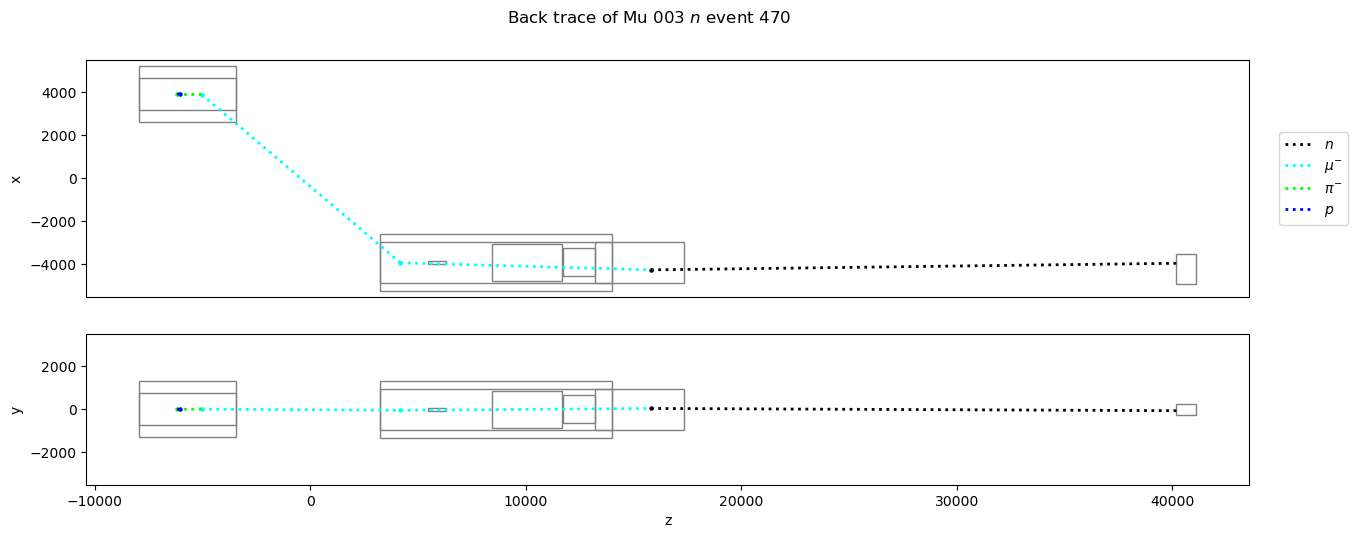

------------------------------------------------------------------------------


level_0                      2527
tag                            Mu
fileno                          3
index                         510
time                  3361.401188
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3878.595632
y                       56.842105
z                        40185.38
startx                 2954.87473
starty                -723.697079
startz               41012.354965
starttime             1389.777222
E                      567.995567
weight                   1.005488
Name: 2480, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,13780,Mu,3,510,890.471558,1389.777222,97,2112,-6236.699956,3244.169972,27294.552983,6.145958e+03
1,13781,Mu,3,510,653.263306,890.471558,115,2112,-3668.007565,-121.769322,17166.613246,1.168055e+04
2,13782,Mu,3,510,129.029221,226.176071,56,13,-3860.133638,-13.461703,4179.000000,1.500345e+04
3,13783,Mu,3,510,37.678917,129.167358,14,13,3938.566157,-2.245150,-3687.001837,1.565892e+04
4,13784,Mu,3,510,25.676971,37.678917,101,-211,3928.664376,1.206447,-6066.577623,6.972995e+04
5,13785,Mu,3,510,25.646717,25.676971,56,2212,3930.861396,1.209779,-6057.829799,8.000000e+06


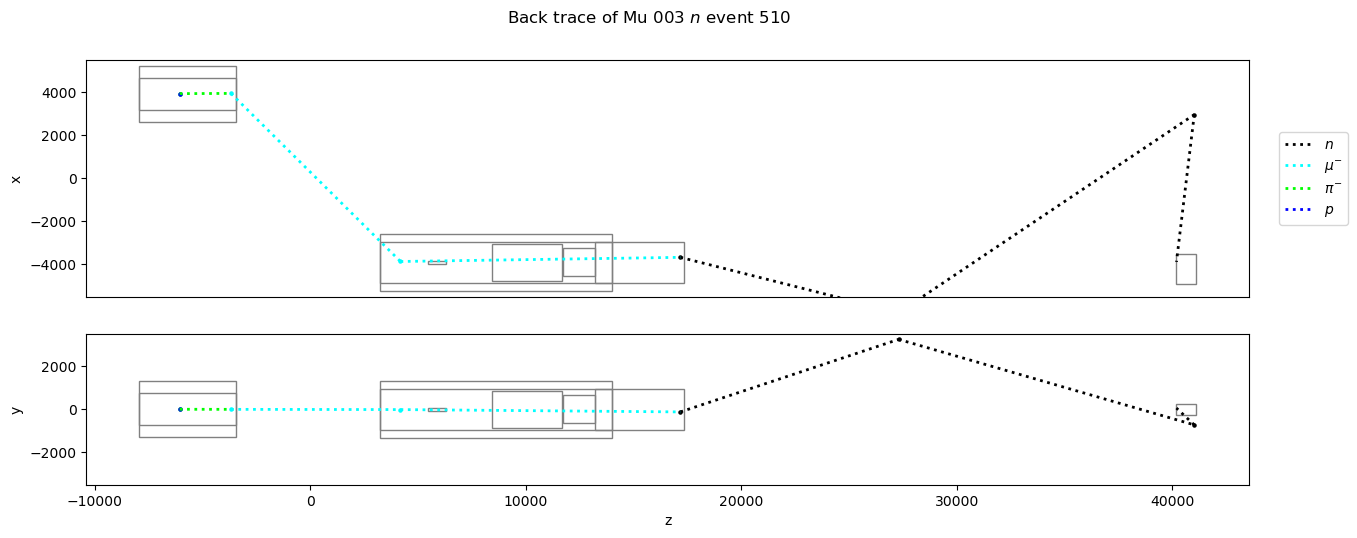

------------------------------------------------------------------------------


level_0                        2567
tag                              Mu
fileno                            3
index                           550
time                 1971863.200668
virtualdetectorId               101
creationCode                    115
pdgId                          2112
x                       -3986.54322
y                        -35.111737
z                           40185.4
startx                 -3858.064024
starty                    47.562367
startz                  5870.992137
starttime               2644.408447
E                          0.000061
weight                     1.005488
Name: 2520, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,14009,Mu,3,550,214.942764,236.260910,56,13,-3877.544455,72.190380,4179.000000,5.546271e+03
1,14010,Mu,3,550,38.008995,215.156693,14,13,3937.413418,14.192064,-5785.435483,7.540161e+03
2,14011,Mu,3,550,29.935303,38.008995,96,-211,3912.291120,-0.670492,-6135.210081,3.246531e+04
3,14012,Mu,3,550,29.933851,29.935303,101,3122,3912.476734,-0.578312,-6134.876343,1.474480e+06
4,14013,Mu,3,550,29.668159,29.933851,56,2212,3931.622635,-0.779160,-6058.019597,8.000000e+06


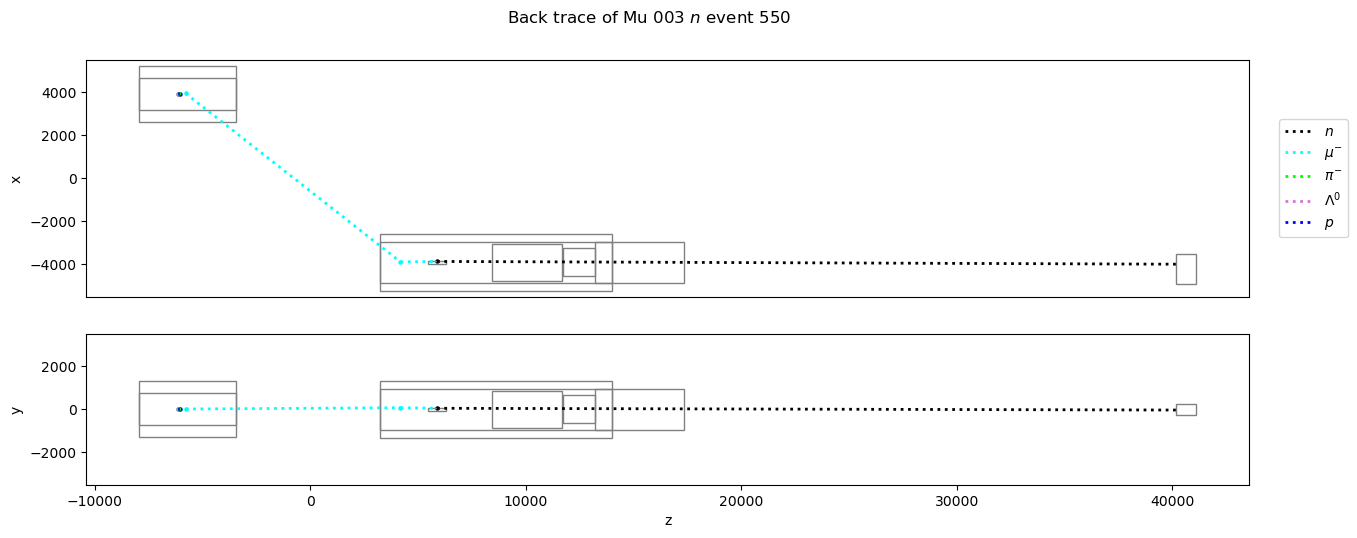

------------------------------------------------------------------------------


level_0                      2607
tag                            Mu
fileno                          3
index                         590
time                 257907.64703
virtualdetectorId             101
creationCode                  115
pdgId                        2112
x                    -3896.816466
y                       -96.41933
z                         40185.4
startx               -3920.616921
starty                 -55.095752
startz                5915.439445
starttime             1238.860474
E                        0.000252
weight                   1.005488
Name: 2560, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,14218,Mu,3,590,265.765289,290.455811,56,13,-3903.306635,-8.461976,4179.000000,6.701390e+03
1,14219,Mu,3,590,48.396091,265.961395,14,13,3870.054053,-34.115752,-5250.335058,8.323311e+03
2,14220,Mu,3,590,28.315474,48.396091,101,-211,3913.830032,1.146284,-6124.642744,4.603870e+04
3,14221,Mu,3,590,28.084196,28.315474,56,2212,3930.381107,1.181317,-6057.710050,8.000000e+06


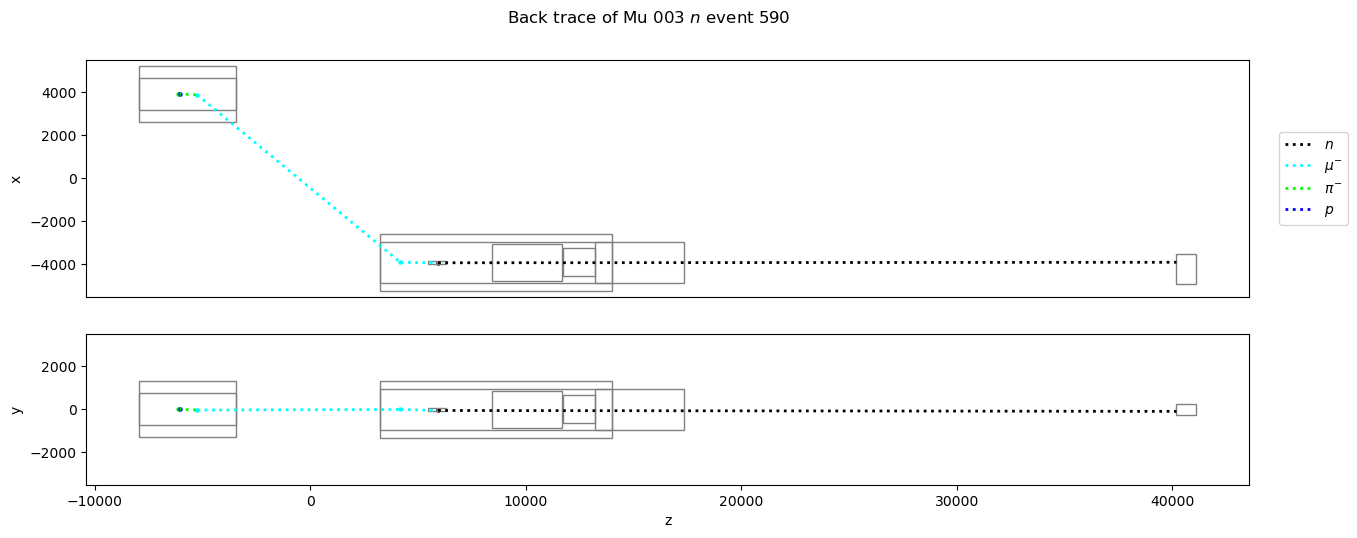

------------------------------------------------------------------------------


level_0                      2647
tag                            Mu
fileno                          3
index                         630
time                 17152.487218
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3885.318694
y                       58.870424
z                        40185.38
startx               -4376.896211
starty                -839.487083
startz                6404.501455
starttime             1955.624268
E                       24.262783
weight                   1.005488
Name: 2600, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,14431,Mu,3,630,1920.010498,1955.624268,115,2112,-3909.050835,-47.028154,6048.745683,4.037572e+03
1,14432,Mu,3,630,153.124878,174.176849,56,13,-3895.312485,6.157649,4179.000000,7.195763e+03
2,14433,Mu,3,630,11.764208,153.314743,14,13,3907.711573,-33.645542,-4707.172242,8.651036e+03
3,14434,Mu,3,630,-17.068419,11.764208,101,-211,3902.017892,-0.243954,-6179.206723,2.264536e+04
4,14435,Mu,3,630,-17.486902,-17.068419,56,2212,3931.654306,-0.329114,-6058.027494,8.000000e+06


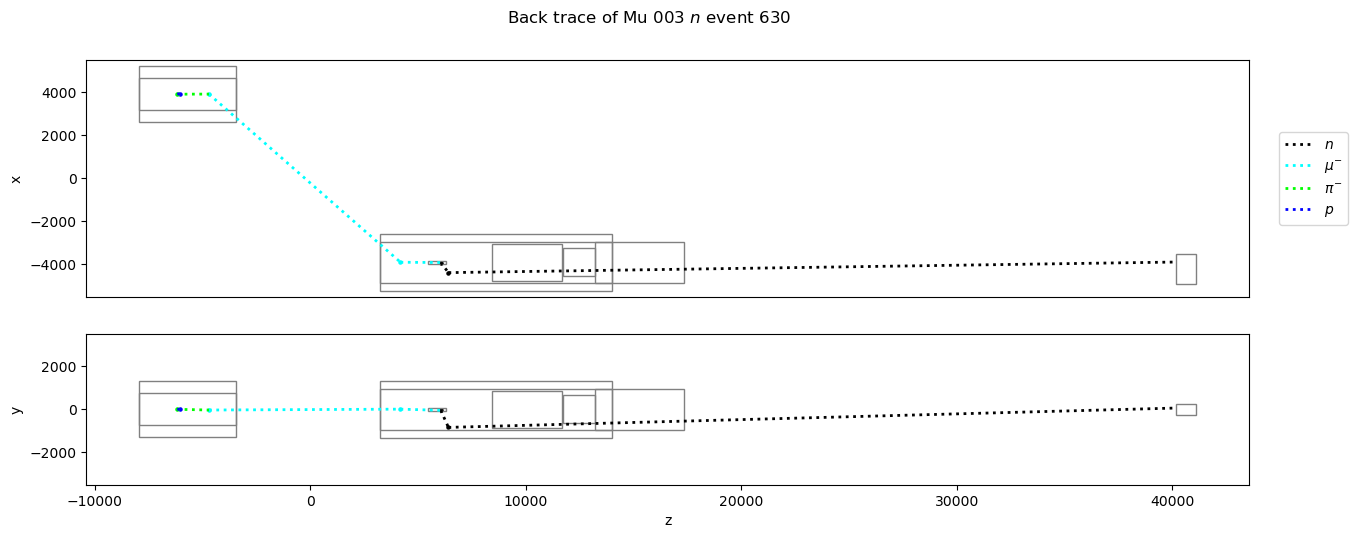

In [6]:
for ii in range(0, len(dfn_Mu), 40):
    print('------------------------------------------------------------------------------')
    dfn_ = dfn_Mu.iloc[ii]
    tag, fileno, index = dfn_['tag'], dfn_['fileno'], dfn_['index']
    dfg_ = df_genealogy.query("tag==@tag and fileno==@fileno and index==@index").reset_index()
    display(dfn_)
    display(dfg_)
    fig, ax_top, ax_side = plot_utils.draw_neutron_event_backtrace(df_neutron, df_genealogy, tag, fileno, index)
    plt.show()

source count
$\mu^{-}$ :  2603
$\gamma$ :  37


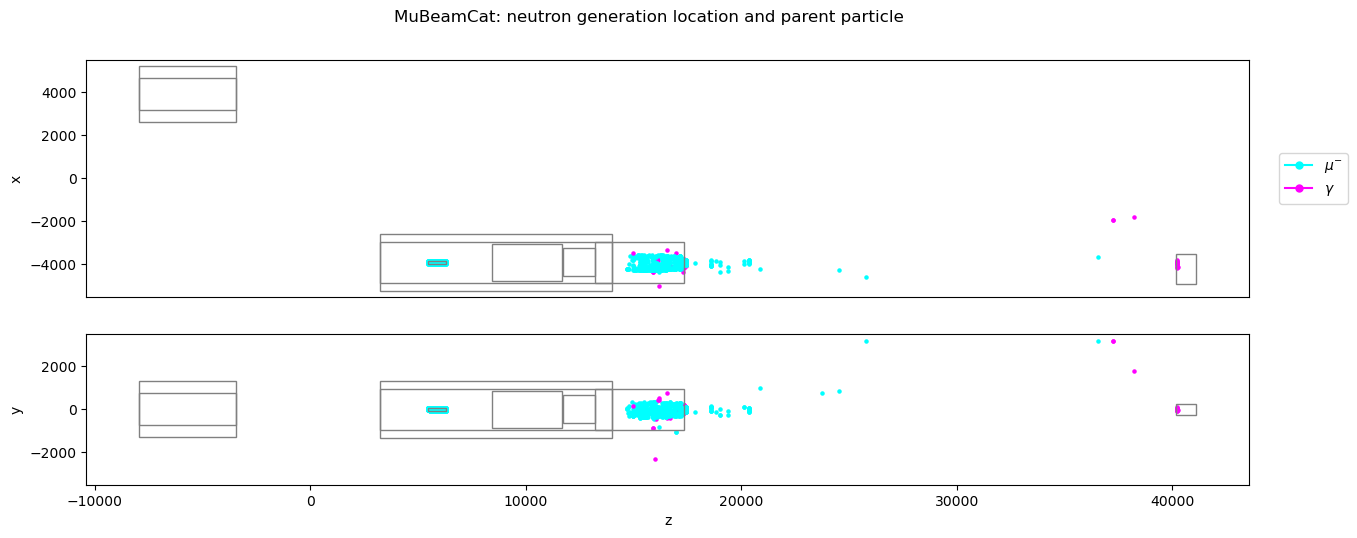

In [7]:
dfs_Mu, fig, ax_top, ax_side = plot_utils.draw_neutron_source_all(dfn_Mu, dfg_Mu, "MuBeamCat: neutron generation location and parent particle")

In [8]:
print ("Total of %i neutrons from MuBeamCat"%len(dfs_Mu))
print ("    %5i with photons as parent"%len(dfs_Mu.query("parentId==22").reset_index(drop=True)))
print ("    %5i with muons   as parent"%len(dfs_Mu.query("parentId==13").reset_index(drop=True)))

Total of 2640 neutrons from MuBeamCat
       37 with photons as parent
     2603 with muons   as parent


Text(0.5, 1.0, 'Neutron creation time and location (muon parent)')

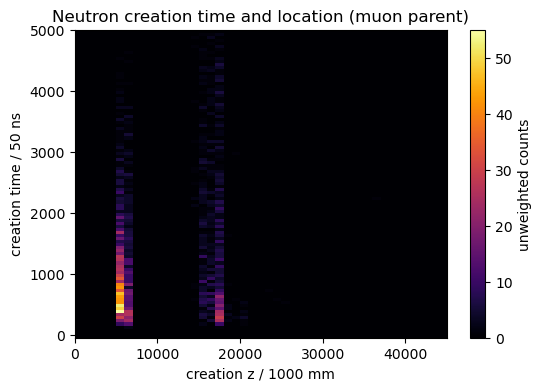

In [9]:
xbins = np.linspace(0., 45000., 46)
ybins = np.linspace(-50., 5000., 102)
fig,ax1 = plt.subplots(figsize=(6, 4))
dfs_Mu13 = dfs_Mu.query("parentId==13").reset_index(drop=True)
H1, xe1, ye1 = np.histogram2d(
    dfs_Mu13['z'], dfs_Mu13['starttime'],
    bins=[xbins, ybins]
)
mesh1 = ax1.pcolormesh(xbins, ybins, H1.T, cmap="inferno")
fig.colorbar(mesh1, ax=ax1, label="unweighted counts", location="right", pad=0.05, orientation='vertical')
ax1.set_xlabel('creation z / 1000 mm')
ax1.set_ylabel('creation time / 50 ns')
ax1.set_title('Neutron creation time and location (muon parent)')

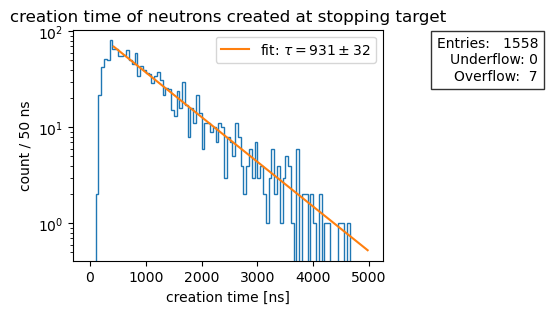

In [10]:
from scipy.optimize import curve_fit

def expo(x, A, tau):
    return A * np.exp(-x / tau)

fig, ax = plt.subplots(figsize=(4,3))
mydf = dfs_Mu13.query("z<10000").reset_index(drop=True)
counts, bin_edges, _ = ax.hist(mydf['starttime'], ybins, histtype='step')

bin_centers = bin_edges[1:]-0.5*(bin_edges[1]-bin_edges[0])
p0=(500., 700.)
popt, pcov = curve_fit(expo, bin_centers[9:], counts[9:], p0=p0)
A, tau = popt
Aerr, tauerr = np.sqrt(np.diag(pcov))
xfit = np.linspace(bin_centers[9], bin_centers.max(), 300)
ax.plot(xfit, expo(xfit, *popt), '-', label=fr'fit: $\tau={tau:.0f}\pm{tauerr:.0f}$')

ax.set_title('creation time of neutrons created at stopping target')
ax.set_xlabel('creation time [ns]')
ax.set_ylabel('count / 50 ns')
entries = len(mydf['starttime'])
mean = np.mean(mydf['starttime'])
std = np.std(mydf['starttime'])
underflow = (mydf['starttime'] < 0.).sum()
overflow  = (mydf['starttime'] > 5000.).sum()
textstr = (
    f"Entries:   {entries}\n"
    #f"Mean:      {mean:.3f}\n"
    #f"Std Dev:   {std:.3f}\n"
    f"Underflow: {underflow}\n"
    f"Overflow:  {overflow}"
)
ax.text(
    1.5, 0.97, textstr,
    transform=ax.transAxes,
    fontsize=10,
    va='top', ha='right',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)
ax.set_yscale('log')
ax.legend()

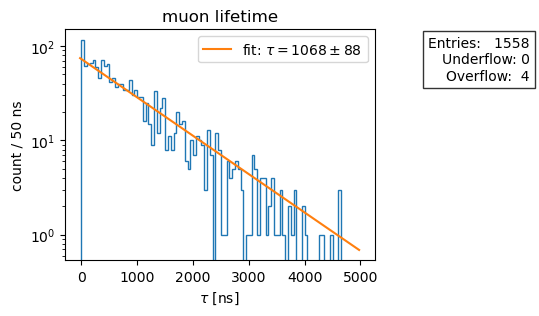

In [11]:
fig, ax = plt.subplots(figsize=(4,3))
mydf = dfs_Mu13.query("z<10000").reset_index(drop=True)
counts, bin_edges, _ = ax.hist(mydf['starttime']-mydf['parentendtime'], ybins, histtype='step')

bin_centers = bin_edges[1:]-0.5*(bin_edges[1]-bin_edges[0])
p0=(500., 700.)
popt, pcov = curve_fit(expo, bin_centers[:], counts[:], p0=p0)
A, tau = popt
Aerr, tauerr = np.sqrt(np.diag(pcov))
xfit = np.linspace(bin_centers[0], bin_centers.max(), 300)
ax.plot(xfit, expo(xfit, *popt), '-', label=fr'fit: $\tau={tau:.0f}\pm{tauerr:.0f}$')

ax.set_title('muon lifetime')
ax.set_xlabel(r'$\tau$ [ns]')
ax.set_ylabel('count / 50 ns')
entries = len(mydf['starttime'])
mean = np.mean(mydf['starttime']-mydf['parentendtime'])
std = np.std(mydf['starttime']-mydf['parentendtime'])
underflow = (mydf['starttime']-mydf['parentendtime'] < 0.).sum()
overflow  = (mydf['starttime']-mydf['parentendtime'] > 5000.).sum()
textstr = (
    f"Entries:   {entries}\n"
    #f"Mean:      {mean:.3f}\n"
    #f"Std Dev:   {std:.3f}\n"
    f"Underflow: {underflow}\n"
    f"Overflow:  {overflow}"
)
ax.text(
    1.5, 0.97, textstr,
    transform=ax.transAxes,
    fontsize=10,
    va='top', ha='right',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)
ax.set_yscale('log')
ax.legend()

In [12]:
print("Neutrons from muons at target")
creationCode_list = np.sort(mydf['creationCode'].unique())
print("creation code", creationCode_list)
for i, v in enumerate(creationCode_list):
    print("Code ",v, " count: ", len(mydf.query("creationCode==@v").reset_index(drop=True)))
    

Neutrons from muons at target
creation code [115]
Code  115  count:  1558


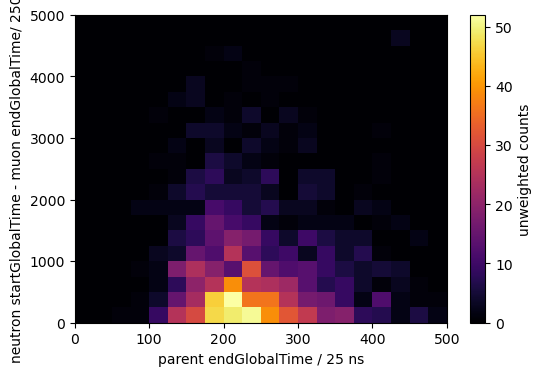

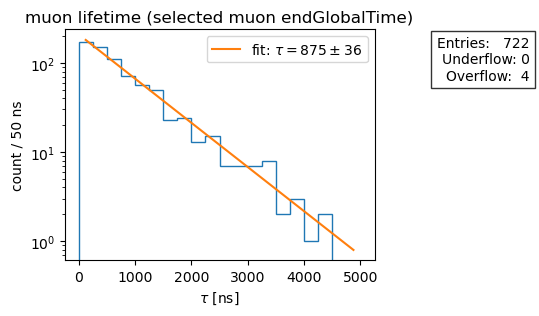

In [13]:
xbins = np.linspace(0., 500., 21)
ybins = np.linspace(0., 5000., 21)
fig,ax1 = plt.subplots(figsize=(6, 4))
H1, xe1, ye1 = np.histogram2d(
    mydf['parentendtime'], mydf['starttime']-mydf['parentendtime'],
    bins=[xbins, ybins]
)
mesh1 = ax1.pcolormesh(xbins, ybins, H1.T, cmap="inferno")
fig.colorbar(mesh1, ax=ax1, label="unweighted counts", location="right", pad=0.05, orientation='vertical')
ax1.set_xlabel('parent endGlobalTime / 25 ns')
ax1.set_ylabel('neutron startGlobalTime - muon endGlobalTime/ 250 ns')

###

fig, ax = plt.subplots(figsize=(4,3))
df_ = mydf.query("parentendtime<300 and parentendtime>200").reset_index(drop=True)
counts, bin_edges, _ = ax.hist(df_['starttime']-df_['parentendtime'], ybins, histtype='step')

bin_centers = bin_edges[1:]-0.5*(bin_edges[1]-bin_edges[0])
p0=(500., 700.)
popt, pcov = curve_fit(expo, bin_centers[:], counts[:], p0=p0)
A, tau = popt
Aerr, tauerr = np.sqrt(np.diag(pcov))
xfit = np.linspace(bin_centers[0], bin_centers.max(), 300)
ax.plot(xfit, expo(xfit, *popt), '-', label=fr'fit: $\tau={tau:.0f}\pm{tauerr:.0f}$')

ax.set_title('muon lifetime (selected muon endGlobalTime)')
ax.set_xlabel(r'$\tau$ [ns]')
ax.set_ylabel('count / 50 ns')
entries = len(df_['starttime'])
mean = np.mean(df_['starttime']-df_['parentendtime'])
std = np.std(df_['starttime']-df_['parentendtime'])
underflow = (df_['starttime']-df_['parentendtime'] < 0.).sum()
overflow  = (df_['starttime']-df_['parentendtime'] > 5000.).sum()
textstr = (
    f"Entries:   {entries}\n"
    #f"Mean:      {mean:.3f}\n"
    #f"Std Dev:   {std:.3f}\n"
    f"Underflow: {underflow}\n"
    f"Overflow:  {overflow}"
)
ax.text(
    1.5, 0.97, textstr,
    transform=ax.transAxes,
    fontsize=10,
    va='top', ha='right',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)
ax.set_yscale('log')
ax.legend()